# Preditor de degradação de rede com RTT normalizado (independente da rota)

**Disciplina / Turma:** 4º Semestre, CC  
**Equipe:** Grupo 7  
**Integrantes:** Isaac William Braz, Fernanda Akemi Martins Sanpei, Geziel de Andrade, Hendrick Ambriola, Davi Gabriel Borges dos Santos, Victor Gabriel Alves  
**Repositório GitHub:** _https://github.com/GzTop1/Redes-Projeto_  
**Modelo:** árvore de decisão (CART)

> Este notebook reúne as **5 tarefas** do projeto, na ordem em que dependem uma da outra.
> Cada seção diz de qual item do diário ela vem. Números do texto são gerados por código a partir das variáveis da execução.

| Tarefa | Entrega | Scrum Master |
|---|---|---|
| 1. Problema e coleta bruta (sem rótulo) | `config/`, `data/raw/`, relatório de qualidade, dicionário v0.1 | _Isaac William Braz_ |
| 2. Baseline e rotulagem | `baseline_por_fluxo.csv`, dataset rotulado, corte temporal, dicionário v0.2 | _Davi Gabriel Borges dos Santos_ |
| 3. Primeira árvore | árvore, regras, matriz 3×3, árvore de contraste | _Fernanda Akemi Martins Sanpei_ |
| 4. Ajuste da árvore | árvore ajustada, tabela T3 → T4, dicionário v0.3 | _Hendrick Ambriola_ |
| 5. Árvore final e teste único | este único, fluxo não visto, ficha da árvore, dicionário v0.4 | _Geziel de Andrade_ |

**Fontes das regras:** `Guia_Coleta_RIPE_Atlas.md`, `RFC_Preditor_Degradacao_Rede.md`, diários `Tarefa1` a `Tarefa5`, manual REST v2 do RIPE Atlas.

### Índice
- **Parte 0:** configuração
- **Tarefa 1:** seções 1.1 a 1.8
- **Tarefa 2:** seções 2.1 a 2.6
- **Tarefa 3:** seções 3.1 a 3.5
- **Tarefa 4:** seções 4.1 a 4.4
- **Tarefa 5:** seções 5.1 a 5.6
- **Fechamento:** contribuições individuais e checklist

> **Como executar este notebook:** use *Ambiente de execução → Reiniciar e executar tudo*, de cima para baixo, **uma vez**.
> A ordem das células segue o processo real: primeira passagem (14 destinos iniciais) → descoberta dos destinos que não respondem → troca → segunda passagem (destinos finais).
> Os JSON de `data/raw/` nunca são regravados (a coleta pula o que já existe) e o log de evidências não repete entradas idênticas.

## Parte 0 — Configuração e bibliotecas

**O que esta parte faz:** reúne todos os parâmetros do projeto em um só lugar e define uma função para registrar evidências.  
**Por quê:** a Tarefa 1 exige parâmetros fora do código espalhado (Tarefa 1, §2) e comprovação de cada passo.  
**Valores:** vêm do Guia §6 (tabela de parâmetros).

In [ ]:
import json, time
from datetime import datetime, timedelta, timezone
from pathlib import Path
from google.colab import drive

import numpy as np
import pandas as pd
import requests

drive.mount("/content/drive")
print("pandas", pd.__version__, "| requests", requests.__version__)

Mounted at /content/drive
pandas 2.2.3 | requests 2.32.4


In [ ]:

BASE_URL = "https://atlas.ripe.net/api/v2"

ROTAS = {
    "BR": ["BR", "AR", "CL", "US", "DE", "JP"],
    "DE": ["DE", "NL"],
}
ESCOPO = {
    ("BR","BR"): "curto",    ("DE","DE"): "curto",
    ("BR","AR"): "regional", ("BR","CL"): "regional", ("DE","NL"): "regional",
    ("BR","US"): "longo",    ("BR","DE"): "longo",    ("BR","JP"): "longo",
}
PAISES_DESTINO = sorted({d for ds in ROTAS.values() for d in ds})

INICIO_PERIODO_A = datetime(2026, 9, 6, 4, 32, tzinfo=timezone.utc)
DIAS_PERIODO_A   = 7
DIAS_PERIODO_B   = 7
BLOCO_DIAS       = 1
NUM_PROBES_POR_PAR = 4
INTERVALO_S      = 240
TIMEOUT_HTTP     = 120
TENTATIVAS       = 3
PISO_RTT_VALIDOS = 1500

PASTA_PROJETO = Path("/content/drive/MyDrive/ripe_atlas_fluxos")
PASTA_CONFIG  = PASTA_PROJETO / "config"
PASTA_RAW     = PASTA_PROJETO / "data" / "raw"
PASTA_INTERIM = PASTA_PROJETO / "data" / "interim"
for p in (PASTA_CONFIG, PASTA_RAW, PASTA_INTERIM):
    p.mkdir(parents=True, exist_ok=True)

print("Países de destino:", PAISES_DESTINO)

Países de destino: ['AR', 'BR', 'CL', 'DE', 'JP', 'NL', 'US']


In [ ]:

def registrar_evidencia(secao, descricao, autor=""):
    """Grava uma linha em config/evidencias.jsonl com data/hora UTC.
    Não repete uma entrada com a mesma seção e a mesma descrição (evita duplicar ao reexecutar)."""
    arq = PASTA_CONFIG / "evidencias.jsonl"
    if arq.exists():
        with arq.open(encoding="utf-8") as f:
            for l in f:
                e = json.loads(l)
                if e["secao"] == secao and e["descricao"] == descricao:
                    print("Evidência já registrada em", e["quando_utc"], "| não repetida:", secao)
                    return
    linha = {"quando_utc": datetime.now(timezone.utc).isoformat(timespec="seconds"),
             "secao": secao, "autor": autor, "descricao": descricao}
    with arq.open("a", encoding="utf-8") as f:
        f.write(json.dumps(linha, ensure_ascii=False) + "\n")
    print("Evidência registrada:", linha["quando_utc"], "|", secao)

def get_com_retentativa(url, params=None):
    """GET com timeout e releitura em erro transitório (429 e 5xx). Tarefa 1, §2."""
    for t in range(1, TENTATIVAS + 1):
        try:
            r = requests.get(url, params=params, timeout=TIMEOUT_HTTP)
            if r.status_code == 429 or r.status_code >= 500:
                raise requests.HTTPError(f"HTTP {r.status_code}")
            r.raise_for_status()
            return r
        except (requests.Timeout, requests.ConnectionError, requests.HTTPError) as e:
            print(f"  tentativa {t}/{TENTATIVAS} falhou: {e}")
            if t == TENTATIVAS:
                raise
            time.sleep(5 * t)

In [ ]:
registrar_evidencia("Parte 0", "Parâmetros e 8 rotas carregados; pasta criada no Drive", "Isaac William Braz")

Evidência registrada: 2026-10-07T18:06:39+00:00 | Parte 0


---
# TAREFA 1 — Problema e coleta bruta (sem rótulo)

> Entrega só o **dado cru**. Sem baseline, sem classe, sem árvore.
> RTT alto **não** é falha. País, IP e nome da rota **não** serão coluna da árvore.

## 1.1 Definição do problema

| Pergunta | Resposta do grupo |
|---|---|
| Qual evento a árvore vai classificar? | Degradação do fluxo em relação ao **próprio** normal: OK, RISCO ou FALHA. |
| O que é um fluxo? | `fluxo_id = probe_id \| dst_addr` |
| O que é cada linha do bruto? | Uma medição ICMP desse fluxo, com timestamp, ainda sem classe. |
| Qual horizonte? | Detector: estado atual. Preditor: estado 12 minutos à frente (3 intervalos de 240 s). |
| Quem usa o alerta? | Quem opera o enlace: investigar (FALHA), observar (RISCO) ou não agir (OK). |
| O que é proibido como definição de falha? | Limiar global de RTT, país, continente ou nome da rota. |


## 1.2 Descoberta das Anchors de destino

**O que faz:** consulta `/anchors/` para cada país de destino e lista os candidatos.  
**Por quê:** os destinos precisam vir da API, não de escolha "de cabeça".  
**Resultado esperado:** quantidade de Anchors por país e a lista com `id`, `fqdn`, `ip_v4` e `probe`.  
**Fonte:** `passo_a_passo_fluxo.ipynb`, Passo 2.

In [ ]:
# (country + is_disabled=false); paginação via campo "next" da resposta
def listar_anchors(pais):
    """Todas as Anchors ativas de um país, seguindo a paginação da API."""
    url, params, achadas = f"{BASE_URL}/anchors/", {"country": pais, "is_disabled": "false"}, []
    while url:
        r = get_com_retentativa(url, params)
        dados = r.json()
        achadas += dados["results"]
        url, params = dados.get("next"), None   # 'next' já traz os parâmetros
    return achadas

anchors_por_pais = {}
for pais in PAISES_DESTINO:
    anchors_por_pais[pais] = listar_anchors(pais)
    print(f"{pais}: {len(anchors_por_pais[pais])} anchors")
    time.sleep(0.5)

AR: 9 anchors
BR: 15 anchors
CL: 9 anchors
DE: 121 anchors
JP: 18 anchors
NL: 68 anchors
US: 156 anchors


In [ ]:

for a in anchors_por_pais["BR"]:
    print(a["id"], "|", a["city"], "|", a["fqdn"], "|", a["ip_v4"], "| probe:", a["probe"])

2334 | Belo Horizonte | br-bhz-as10417-client.anchors.atlas.ripe.net | 150.164.1.222 | probe: 6891
4093 | Camaçari | br-cci-as61618.anchors.atlas.ripe.net | 170.81.100.114 | probe: 7457
3679 | Feira de Santana | br-fec-as264479.anchors.atlas.ripe.net | 138.117.32.11 | probe: 7307
3497 | Fortaleza | br-for-as37468.anchors.atlas.ripe.net | 170.238.235.214 | probe: 7242
2849 | Ponta Grossa | br-pgz-as53046.anchors.atlas.ripe.net | 143.208.160.10 | probe: 7019
4331 | Primavera do Leste | br-pil-as52564.anchors.atlas.ripe.net | 177.85.156.51 | probe: 7568
1164 | Porto Alegre | br-poa-as19200.anchors.atlas.ripe.net | 200.132.1.32 | probe: 6349
4185 | Osasco | br-qoc-as14907.anchors.atlas.ripe.net | 195.200.68.66 | probe: 7508
2474 | São Paulo | br-sao-as12008.anchors.atlas.ripe.net | 156.154.122.254 | probe: 6977
1974 | São Paulo | br-sao-as199524.anchors.atlas.ripe.net | 5.188.238.222 | probe: 6659
1454 | Sao Paulo | br-sao-as22548.anchors.atlas.ripe.net | 200.160.6.19 | probe: 6410
1869 | 

In [ ]:
import json
with (PASTA_CONFIG / "anchors_candidatas.json").open("w", encoding="utf-8") as f:
    json.dump(anchors_por_pais, f, ensure_ascii=False, indent=2)

print("Salvo em:", PASTA_CONFIG / "anchors_candidatas.json")

Salvo em: /content/drive/MyDrive/ripe_atlas_fluxos/config/anchors_candidatas.json


In [ ]:
registrar_evidencia("1.2", "Listei candidatos a destino por país (AR 9, BR 15, CL 9, DE 121, JP 18, NL 69, US 157)", "Isaac William Braz")

Evidência registrada: 2026-10-07T18:06:46+00:00 | 1.2


## 1.3 Mapeamento das medições (`msm_id` do mesh)

**O que faz:** para cada Anchor de destino escolhida, acha a medição pública de ping IPv4 do *Anchoring Mesh* que a tem como alvo.  
**Filtro:** `type=ping`, `af=4`, `is_public=true`, status *Ongoing*, descrição "Anchoring Mesh".  
**Fonte:** Guia 1 (consulta que filtra) e `passo_a_passo_fluxo.ipynb`, Passo 3.

_(Código a escrever depois da Parte A, com a lista de destinos escolhidos: 1 a 3 IPs por país.)_

In [ ]:

IPS_POR_PAIS = 2

destinos = []
for pais in PAISES_DESTINO:
    cidades_usadas = set()
    for a in sorted(anchors_por_pais[pais], key=lambda x: x["id"]):
        if a["city"] in cidades_usadas or not a.get("ip_v4"):
            continue
        destinos.append({
            "pais": pais, "anchor_id": a["id"], "cidade": a["city"],
            "fqdn": a["fqdn"], "ip": a["ip_v4"], "probe_dest": a["probe"],
        })
        cidades_usadas.add(a["city"])
        if len(cidades_usadas) == IPS_POR_PAIS:
            break

df_destinos = pd.DataFrame(destinos)
print(len(df_destinos), "destinos escolhidos")
display(df_destinos)

df_destinos.to_csv(PASTA_CONFIG / "destinos_escolhidos.csv", index=False)
registrar_evidencia("1.3", f"Escolhidos {len(df_destinos)} destinos (até {IPS_POR_PAIS} por país, cidades distintas)", "Isaac William Braz")

14 destinos escolhidos


,pais,anchor_id,cidade,fqdn,ip,probe_dest
0,AR,1938,Tostado,ar-ttd-as263777.anchors.atlas.ripe.net,138.204.7.245,6633
1,AR,3066,Bahía Blanca,ar-bhi-as28109.anchors.atlas.ripe.net,190.124.192.162,7099
2,BR,1164,Porto Alegre,br-poa-as19200.anchors.atlas.ripe.net,200.132.1.32,6349
3,BR,1454,Sao Paulo,br-sao-as22548.anchors.atlas.ripe.net,200.160.6.19,6410
4,CL,1605,Santiago de Chile,cl-scl-as64112.anchors.atlas.ripe.net,170.247.95.81,6485
5,CL,1673,Santiago,cl-scl-as42473.anchors.atlas.ripe.net,37.252.251.26,6553
6,DE,1154,Frankfurt am Main,de-fra-as203329.anchors.atlas.ripe.net,185.138.143.34,6313
7,DE,1215,Nuremberg,de-rgm-as24940.anchors.atlas.ripe.net,88.198.179.162,6332
8,JP,1349,Tokyo,jp-tyo-as59105.anchors.atlas.ripe.net,103.202.216.76,6370
9,JP,4044,Tsuchiura,jp-tch-as63806.anchors.atlas.ripe.net,43.228.174.199,7433


Evidência registrada: 2026-10-07T18:06:47+00:00 | 1.3


In [ ]:
# A descrição "Anchoring Mesh" e o status Ongoing são filtrados aqui no código
# (a API devolve também medições antigas, paradas ou de outro tipo).
def achar_msm_mesh(fqdn):
    url = f"{BASE_URL}/measurements/"
    params = {"target": fqdn, "type": "ping", "af": 4, "is_public": "true"}
    todas = []
    while url:
        r = get_com_retentativa(url, params)
        dados = r.json()
        todas += dados["results"]
        url, params = dados.get("next"), None
    mesh = [m for m in todas
            if "Anchoring Mesh" in (m.get("description") or "")
            and (m.get("status") or {}).get("name") == "Ongoing"
            and not m.get("is_oneoff")]
    return len(todas), mesh

linhas = []
for d in df_destinos.to_dict("records"):
    total, mesh = achar_msm_mesh(d["fqdn"])
    ids = sorted(m["id"] for m in mesh)
    escolhida = mesh[0] if len(mesh) == 1 else None
    linhas.append({
        "pais": d["pais"], "cidade": d["cidade"], "fqdn": d["fqdn"],
        "total_medicoes": total, "candidatas_mesh": ids,
        "msm_id": escolhida["id"] if escolhida else None,
        "interval": escolhida.get("interval") if escolhida else None,
        "packets": escolhida.get("packets") if escolhida else None,
    })
    print(f'{d["pais"]} {d["cidade"]}: {total} medições, mesh Ongoing = {ids}')
    time.sleep(0.5)

df_msm = pd.DataFrame(linhas)
display(df_msm)

AR Tostado: 706 medições, mesh Ongoing = [23119200]
AR Bahía Blanca: 430 medições, mesh Ongoing = [41365644]
BR Porto Alegre: 493 medições, mesh Ongoing = [11688943]
BR Sao Paulo: 862 medições, mesh Ongoing = [17142952]
CL Santiago de Chile: 84 medições, mesh Ongoing = [19187535]
CL Santiago: 53 medições, mesh Ongoing = [21720193]
DE Frankfurt am Main: 104 medições, mesh Ongoing = [10103385]
DE Nuremberg: 44 medições, mesh Ongoing = [10696140]
JP Tokyo: 19 medições, mesh Ongoing = [88535125]
JP Tsuchiura: 2 medições, mesh Ongoing = [84216561]
NL Amsterdam: 6 medições, mesh Ongoing = [9333345]
NL Apeldoorn: 2 medições, mesh Ongoing = [11583528]
US Durham: 6 medições, mesh Ongoing = [15393461]
US Detroit: 5 medições, mesh Ongoing = [15750885]


,pais,cidade,fqdn,total_medicoes,candidatas_mesh,msm_id,interval,packets
0,AR,Tostado,ar-ttd-as263777.anchors.atlas.ripe.net,706,[23119200],23119200,240,3
1,AR,Bahía Blanca,ar-bhi-as28109.anchors.atlas.ripe.net,430,[41365644],41365644,240,3
2,BR,Porto Alegre,br-poa-as19200.anchors.atlas.ripe.net,493,[11688943],11688943,240,3
3,BR,Sao Paulo,br-sao-as22548.anchors.atlas.ripe.net,862,[17142952],17142952,240,3
4,CL,Santiago de Chile,cl-scl-as64112.anchors.atlas.ripe.net,84,[19187535],19187535,240,3
5,CL,Santiago,cl-scl-as42473.anchors.atlas.ripe.net,53,[21720193],21720193,240,3
6,DE,Frankfurt am Main,de-fra-as203329.anchors.atlas.ripe.net,104,[10103385],10103385,240,3
7,DE,Nuremberg,de-rgm-as24940.anchors.atlas.ripe.net,44,[10696140],10696140,240,3
8,JP,Tokyo,jp-tyo-as59105.anchors.atlas.ripe.net,19,[88535125],88535125,240,3
9,JP,Tsuchiura,jp-tch-as63806.anchors.atlas.ripe.net,2,[84216561],84216561,240,3


In [ ]:
# Junta a escolha de destinos (1.3 A) com o msm_id encontrado (1.3 B)
df_destinos_msm = df_destinos.merge(
    df_msm[["fqdn", "msm_id", "interval", "packets"]], on="fqdn", how="left"
)

# Segurança: nenhum destino pode ficar sem msm_id
assert df_destinos_msm["msm_id"].notna().all(), "Há destino sem msm_id"

df_destinos_msm.to_csv(PASTA_CONFIG / "destinos_com_msm.csv", index=False)
display(df_destinos_msm[["pais", "cidade", "ip", "msm_id", "probe_dest"]])

registrar_evidencia("1.3", f"Achados {len(df_destinos_msm)} msm_id do mesh (1 por destino, interval 240, packets 3); salvo destinos_com_msm.csv", "Isaac William Braz")

,pais,cidade,ip,msm_id,probe_dest
0,AR,Tostado,138.204.7.245,23119200,6633
1,AR,Bahía Blanca,190.124.192.162,41365644,7099
2,BR,Porto Alegre,200.132.1.32,11688943,6349
3,BR,Sao Paulo,200.160.6.19,17142952,6410
4,CL,Santiago de Chile,170.247.95.81,19187535,6485
5,CL,Santiago,37.252.251.26,21720193,6553
6,DE,Frankfurt am Main,185.138.143.34,10103385,6313
7,DE,Nuremberg,88.198.179.162,10696140,6332
8,JP,Tokyo,103.202.216.76,88535125,6370
9,JP,Tsuchiura,43.228.174.199,84216561,7433


Evidência registrada: 2026-10-07T18:07:29+00:00 | 1.3


## 1.4 Probes de origem e tabela de desenho

**O que faz:** escolhe até 4 Anchors de origem por país e monta a tabela de fluxos.  
**Regras (Guia 5):** até 4 probes por país de origem; cada probe × IP é um fluxo; o probe do próprio alvo fica de fora (auto-ping).  
**Colunas da tabela:** `rota`, `escopo`, `pais_origem`, `pais_destino`, `fqdn`, `ip`, `msm_id`, `probes`.  
**Atenção:** `escopo` e país são só auditoria e **ficam fora da árvore**.

In [ ]:
# Fonte: Guia §5 (até 4 probes por país de origem; o probe do próprio alvo fica de fora)
# e Guia §6 (NUM_PROBES_POR_PAR = 4). Cidades distintas, ordem crescente de id (regra do grupo).
linhas = []
for origem, paises_dest in ROTAS.items():
    candidatas = sorted(anchors_por_pais[origem], key=lambda x: x["id"])
    alvos = df_destinos_msm[df_destinos_msm["pais"].isin(paises_dest)]
    for d in alvos.to_dict("records"):
        cidades_usadas, escolhidas = set(), []
        for a in candidatas:
            if not a.get("probe") or a["probe"] == d["probe_dest"] or a["city"] in cidades_usadas:
                continue
            escolhidas.append(a)
            cidades_usadas.add(a["city"])
            if len(escolhidas) == NUM_PROBES_POR_PAR:
                break
        for a in escolhidas:
            linhas.append({
                "rota": f"{origem}->{d['pais']}", "escopo": ESCOPO[(origem, d["pais"])],
                "pais_origem": origem, "pais_destino": d["pais"],
                "cidade_destino": d["cidade"], "ip": d["ip"], "msm_id": d["msm_id"],
                "probe_id": a["probe"], "cidade_origem": a["city"], "probe_dest": d["probe_dest"],
                "fluxo_id": f"{a['probe']}|{d['ip']}",
            })

df_fluxos = pd.DataFrame(linhas)

# Segurança: sem auto-ping e sem fluxo repetido
assert (df_fluxos["probe_id"] != df_fluxos["probe_dest"]).all(), "Auto-ping encontrado"
assert df_fluxos["fluxo_id"].is_unique, "fluxo_id repetido"

print(len(df_fluxos), "fluxos |", df_fluxos["probe_id"].nunique(), "probes de origem")
display(df_fluxos.groupby(["rota", "escopo"]).agg(
    destinos=("ip", "nunique"), fluxos=("fluxo_id", "count")).reset_index())

64 fluxos | 11 probes de origem


,rota,escopo,destinos,fluxos
0,BR->AR,regional,2,8
1,BR->BR,curto,2,8
2,BR->CL,regional,2,8
3,BR->DE,longo,2,8
4,BR->JP,longo,2,8
5,BR->US,longo,2,8
6,DE->DE,curto,2,8
7,DE->NL,regional,2,8


In [ ]:
df_fluxos.to_csv(PASTA_CONFIG / "tabela_desenho.csv", index=False)
registrar_evidencia("1.4", f"Tabela de desenho: {len(df_fluxos)} fluxos, {df_fluxos['probe_id'].nunique()} probes de origem, 8 rotas", "Isaac William Braz")

Evidência registrada: 2026-10-07T18:07:29+00:00 | 1.4


In [ ]:
# Fonte: Guia §1 (GET /measurements/{msm_id}/results/ com probe_ids, start e stop)
# Checagem pequena antes da coleta completa: 1 hora de dados, esperado ~15 resultados por probe (3600 s / 240 s).
from collections import Counter

t0 = int(INICIO_PERIODO_A.timestamp())
t1 = t0 + 3600

contagem = []
for msm_id, g in df_fluxos.groupby("msm_id"):
    probes = sorted(g["probe_id"].unique())
    r = get_com_retentativa(
        f"{BASE_URL}/measurements/{msm_id}/results/",
        {"probe_ids": ",".join(map(str, probes)), "start": t0, "stop": t1, "format": "json"},
    )
    por_probe = Counter(x["prb_id"] for x in r.json())
    for p in probes:
        contagem.append({"msm_id": msm_id, "probe_id": p, "n_resultados_1h": por_probe.get(p, 0)})
    time.sleep(0.5)

df_check = pd.DataFrame(contagem)
print(len(df_check), "pares (msm, probe) verificados")
print("Sem nenhum dado:", (df_check["n_resultados_1h"] == 0).sum())
display(df_check.groupby("n_resultados_1h").size().rename("quantos_pares").reset_index())
display(df_check[df_check["n_resultados_1h"] == 0])

64 pares (msm, probe) verificados
Sem nenhum dado: 0


,n_resultados_1h,quantos_pares
0,15,64


,msm_id,probe_id,n_resultados_1h


## 1.5 Coleta dia a dia (Períodos A e B)

**Regras (Tarefa 1, 2):**
- Período A (7 dias) e Período B (7 dias) contíguos, **sem amostra nos dois**.
- Um dia por pedido (`BLOCO_DIAS = 1`), `GET` com `probe_ids`, `start`, `stop`.
- JSON bruto preservado em `data/raw/`; rodar de novo **não duplica** (se o arquivo do dia existe, pula).
- Timeout permanece no arquivo. RTT vazio é ausência, nunca 0.

In [ ]:
# Fonte: Tarefa 1 §2 (coleta idempotente, JSON bruto preservado, bloco de 1 dia) e Guia §6 (BLOCO_DIAS = 1).
# Uma requisição por (msm_id, país de origem): no máximo 4 probes por pedido (Guia §6: 5 ou mais deu timeout).
# stop = início + 1 dia - 1 s, para um bloco não repetir o último instante do bloco anterior.
import os

t_inicio = int(INICIO_PERIODO_A.timestamp())
SEG_DIA = 86400

grupos = (df_fluxos.groupby(["msm_id", "pais_origem"])["probe_id"]
          .apply(lambda s: sorted(int(p) for p in s.unique())).reset_index())

def baixar_bloco(msm_id, origem, probes, periodo, start, stop):
    destino = PASTA_RAW / f"P{periodo}_m{msm_id}_{origem}_{start}.json"
    if destino.exists():
        return "pulado"
    r = get_com_retentativa(
        f"{BASE_URL}/measurements/{msm_id}/results/",
        {"probe_ids": ",".join(map(str, probes)), "start": start, "stop": stop, "format": "json"},
    )
    tmp = destino.with_suffix(".tmp")
    tmp.write_text(r.text, encoding="utf-8")  # JSON exatamente como a API devolveu
    os.replace(tmp, destino)                  # só vira arquivo final se o download terminou
    return "baixado"

DIAS_A_BAIXAR = range(14)

resumo = {"baixado": 0, "pulado": 0}
t_ini = time.time()
for k in DIAS_A_BAIXAR:
    periodo = "A" if k < DIAS_PERIODO_A else "B"
    start = t_inicio + k * SEG_DIA
    stop = start + SEG_DIA - 1
    for g in grupos.to_dict("records"):
        status = baixar_bloco(g["msm_id"], g["pais_origem"], g["probe_id"], periodo, start, stop)
        resumo[status] += 1
        time.sleep(0.5)
    print(f"dia {k} (Período {periodo}) concluído | {resumo}")

print(f"Tempo: {time.time() - t_ini:.0f} s | arquivos em raw: {len(list(PASTA_RAW.glob('P*.json')))}")

dia 0 (Período A) concluído | {'baixado': 0, 'pulado': 16}
dia 1 (Período A) concluído | {'baixado': 0, 'pulado': 32}
dia 2 (Período A) concluído | {'baixado': 0, 'pulado': 48}
dia 3 (Período A) concluído | {'baixado': 0, 'pulado': 64}
dia 4 (Período A) concluído | {'baixado': 0, 'pulado': 80}
dia 5 (Período A) concluído | {'baixado': 0, 'pulado': 96}
dia 6 (Período A) concluído | {'baixado': 0, 'pulado': 112}
dia 7 (Período B) concluído | {'baixado': 0, 'pulado': 128}
dia 8 (Período B) concluído | {'baixado': 0, 'pulado': 144}
dia 9 (Período B) concluído | {'baixado': 0, 'pulado': 160}
dia 10 (Período B) concluído | {'baixado': 0, 'pulado': 176}
dia 11 (Período B) concluído | {'baixado': 0, 'pulado': 192}
dia 12 (Período B) concluído | {'baixado': 0, 'pulado': 208}
dia 13 (Período B) concluído | {'baixado': 0, 'pulado': 224}
Tempo: 112 s | arquivos em raw: 266


In [ ]:
registrar_evidencia("1.5", "Coleta dos 14 dias concluída: 224 arquivos em data/raw (A: dias 0-6, B: dias 7-13)", "Isaac William Braz")

Evidência já registrada em 2026-10-07T18:17:02+00:00 | não repetida: 1.5


In [ ]:
import json
arq = sorted(PASTA_RAW.glob("P*.json"))[0]
dados = json.loads(arq.read_text(encoding="utf-8"))
print(arq.name, "|", len(dados), "registros")
print(json.dumps(dados[0], indent=2, ensure_ascii=False)[:1200])

PA_m10103385_BR_1788669120.json | 1439 registros
{
  "fw": 5130,
  "mver": "2.6.4",
  "lts": 865,
  "dst_name": "185.138.143.34",
  "af": 4,
  "dst_addr": "185.138.143.34",
  "src_addr": "200.132.1.32",
  "proto": "ICMP",
  "ttl": 49,
  "size": 64,
  "result": [
    {
      "rtt": 235.724719
    },
    {
      "rtt": 236.043093
    },
    {
      "rtt": 236.00234
    }
  ],
  "dup": 0,
  "rcvd": 3,
  "sent": 3,
  "min": 235.724719,
  "max": 236.043093,
  "avg": 235.92338400000003,
  "msm_id": 10103385,
  "prb_id": 6349,
  "timestamp": 1788739225,
  "msm_name": "Ping",
  "from": "200.132.1.32",
  "type": "ping",
  "group_id": 10103384,
  "step": 240,
  "stored_timestamp": 1788739321
}


## 1.6 Relatório de qualidade (ainda sem classe)

**Itens (Tarefa 1, 3):** registros por `fluxo_id`; início e fim de cada fluxo; campos ausentes; duplicatas; quantidade de timeouts; RTT e perda descritos (mínimo, mediana, máximo) **sem** dizer OK, RISCO ou FALHA.

In [ ]:
# Fonte: Tarefa 1 §2 (campos da coleta) e Guia §8 (métricas da amostra).
# O JSON em data/raw NÃO é alterado: a tabela de trabalho vai para data/interim.
# Destinos descartados (100% timeout, ver relatório 1.6) ficam em raw, mas não entram na tabela.
import statistics

msm_validos = {int(m) for m in df_fluxos["msm_id"]}
arquivos_lidos, arquivos_ignorados = 0, 0

linhas = []
for arq in sorted(PASTA_RAW.glob("P*.json")):
    if int(arq.name.split("_")[1][1:]) not in msm_validos:
        arquivos_ignorados += 1
        continue
    arquivos_lidos += 1
    periodo = arq.name[1]                          # "A" ou "B", vem do nome do arquivo
    for x in json.loads(arq.read_text(encoding="utf-8")):
        rtts = [p["rtt"] for p in x.get("result", []) if "rtt" in p]
        linhas.append({
            "periodo": periodo, "arquivo": arq.name,
            "msm_id": x.get("msm_id"), "prb_id": x.get("prb_id"), "dst_addr": x.get("dst_addr"),
            "timestamp": x.get("timestamp"), "sent": x.get("sent"), "rcvd": x.get("rcvd"),
            "min": x.get("min"), "avg": x.get("avg"), "max": x.get("max"),
            # desvio-padrão amostral (ddof=1); só com 2 ou mais respostas, senão vazio (nunca 0)
            "jitter_ms": statistics.stdev(rtts) if len(rtts) >= 2 else None,
        })

df_bruto = pd.DataFrame(linhas)
for c in ["msm_id", "prb_id", "timestamp", "sent", "rcvd", "min", "avg", "max", "jitter_ms"]:
    df_bruto[c] = pd.to_numeric(df_bruto[c], errors="coerce")
n_bruto = len(df_bruto)

# Sem 'sent', a linha sai (Guia §8). Perda de 100% fica.
sem_sent = df_bruto["sent"].isna() | (df_bruto["sent"] == 0)
n_sem_sent = int(sem_sent.sum())
df_bruto = df_bruto[~sem_sent].copy()

# RTT sem resposta fica VAZIO, nunca 0 e nunca -1 (Tarefa 1 §2).
sem_rtt = (df_bruto["rcvd"].fillna(0) == 0) | (df_bruto["avg"].isna()) | (df_bruto["avg"] < 0)
df_bruto.loc[sem_rtt, ["min", "avg", "max"]] = np.nan

df_bruto["perda_pct"] = (df_bruto["sent"] - df_bruto["rcvd"]) / df_bruto["sent"] * 100
df_bruto["timeout_atual"] = (df_bruto["avg"].isna() | (df_bruto["perda_pct"] == 100)).astype(int)
df_bruto["fluxo_id"] = df_bruto["prb_id"].astype(int).astype(str) + "|" + df_bruto["dst_addr"].astype(str)
df_bruto["timestamp_utc"] = pd.to_datetime(df_bruto["timestamp"], unit="s", utc=True)

# Duplicatas por (msm_id, prb_id, timestamp): contadas e removidas só da tabela de trabalho.
dup = df_bruto.duplicated(subset=["msm_id", "prb_id", "timestamp"])
n_dup = int(dup.sum())
df_bruto = df_bruto[~dup].sort_values(["fluxo_id", "timestamp"]).reset_index(drop=True)

assert (df_bruto["avg"].dropna() > 0).all(), "Há RTT <= 0 gravado como valor"

df_bruto.to_csv(PASTA_INTERIM / "bruto_tabela.csv", index=False)

print(f"Arquivos lidos: {arquivos_lidos} | ignorados (destinos descartados): {arquivos_ignorados}")
print(f"Registros lidos dos JSON: {n_bruto:,}".replace(",", "."))
print(f"Removidos por falta de 'sent': {n_sem_sent} | duplicatas removidas: {n_dup}")
print(f"Registros na tabela de trabalho: {len(df_bruto):,}".replace(",", "."))
print(f"Fluxos distintos: {df_bruto['fluxo_id'].nunique()} (esperado: {df_fluxos['fluxo_id'].nunique()})")
print("Registros por período:", df_bruto["periodo"].value_counts().sort_index().to_dict())
print("Timeouts:", int(df_bruto["timeout_atual"].sum()), "| RTT vazio:", int(df_bruto["avg"].isna().sum()))

Arquivos lidos: 224 | ignorados (destinos descartados): 0
Registros lidos dos JSON: 322.039
Removidos por falta de 'sent': 0 | duplicatas removidas: 0
Registros na tabela de trabalho: 322.039
Fluxos distintos: 64 (esperado: 64)
Registros por período: {'A': 161140, 'B': 160899}
Timeouts: 60615 | RTT vazio: 60615


In [ ]:
registrar_evidencia("1.6", "Tabela de trabalho gerada: 322.039 registros, 64 fluxos, bruto_tabela.csv em data/interim", "Isaac William Braz")

Evidência registrada: 2026-10-07T18:17:19+00:00 | 1.6


In [ ]:
# Fonte: Tarefa 1 §3 (relatório de qualidade). Só descreve; NÃO usa OK, RISCO nem FALHA.
from IPython.display import Markdown, display

meta = df_fluxos[["fluxo_id", "rota", "escopo", "cidade_destino"]].drop_duplicates("fluxo_id")
df_q = df_bruto.merge(meta, on="fluxo_id", how="left")
assert df_q["rota"].notna().all(), "Há fluxo que não está na tabela de desenho"

# 1) Por fluxo: registros, início, fim, timeouts, RTT válidos no Período A
por_fluxo = df_q.groupby(["fluxo_id", "rota", "escopo", "cidade_destino"]).agg(
    registros=("timestamp", "count"),
    inicio=("timestamp_utc", "min"), fim=("timestamp_utc", "max"),
    timeouts=("timeout_atual", "sum"),
    rtt_mediana=("avg", "median"),
).reset_index()
por_fluxo["pct_timeout"] = (por_fluxo["timeouts"] / por_fluxo["registros"] * 100).round(1)
validos_A = df_q[(df_q["periodo"] == "A") & df_q["avg"].notna()].groupby("fluxo_id").size()
por_fluxo["rtt_validos_A"] = por_fluxo["fluxo_id"].map(validos_A).fillna(0).astype(int)
por_fluxo.to_csv(PASTA_INTERIM / "relatorio_qualidade_por_fluxo.csv", index=False)

# 2) Por destino (onde estão os timeouts?)
por_destino = df_q.groupby(["rota", "cidade_destino"]).agg(
    fluxos=("fluxo_id", "nunique"), registros=("timestamp", "count"),
    timeouts=("timeout_atual", "sum")).reset_index()
por_destino["pct_timeout"] = (por_destino["timeouts"] / por_destino["registros"] * 100).round(1)

# 3) RTT e perda descritos por escopo (mínimo, mediana, máximo), sem classe
por_escopo = df_q.groupby("escopo").agg(
    fluxos=("fluxo_id", "nunique"), registros=("timestamp", "count"),
    rtt_min=("avg", "min"), rtt_mediana=("avg", "median"), rtt_max=("avg", "max"),
    perda_mediana=("perda_pct", "median"), perda_max=("perda_pct", "max"),
    timeouts=("timeout_atual", "sum")).round(1).reset_index()

print("=== Campos ausentes (RTT vazio é ausência, não zero) ===")
print(df_q[["timestamp", "sent", "rcvd", "min", "avg", "max", "jitter_ms"]].isna().sum().to_string())
print(f"\nDuplicatas encontradas e removidas da tabela de trabalho: {n_dup}")
print("\n=== Registros por fluxo (mínimo / mediana / máximo) ===")
print(por_fluxo["registros"].agg(["min", "median", "max"]).to_string())
print("\n=== RTT e perda por escopo ===")
display(por_escopo)
print("=== Timeouts por destino ===")
display(por_destino.sort_values("pct_timeout", ascending=False))
print("=== Fluxos com menos de 1.500 RTT válidos no Período A (informativo; a decisão é da Tarefa 2) ===")
display(por_fluxo[por_fluxo["rtt_validos_A"] < PISO_RTT_VALIDOS]
        [["fluxo_id", "rota", "cidade_destino", "rtt_validos_A", "pct_timeout"]])

rotas_por_escopo = df_q.groupby("escopo")["rota"].unique().apply(lambda r: " / ".join(sorted(r))).to_dict()
display(Markdown(f"""
**N de registros brutos:** {n_bruto:,} (tabela de trabalho: {len(df_q):,}).
**N de fluxos:** {df_q['fluxo_id'].nunique()}.
**Caminhos presentes:** curto = {rotas_por_escopo.get('curto')}; regional = {rotas_por_escopo.get('regional')}; longo = {rotas_por_escopo.get('longo')}.
**Período dos dados:** {df_q['timestamp_utc'].min():%d/%m/%Y %H:%M} a {df_q['timestamp_utc'].max():%d/%m/%Y %H:%M} UTC.
""".replace(",", ".")))

=== Campos ausentes (RTT vazio é ausência, não zero) ===
timestamp        0
sent             0
rcvd             0
min          60615
avg          60615
max          60615
jitter_ms    60809

Duplicatas encontradas e removidas da tabela de trabalho: 0

=== Registros por fluxo (mínimo / mediana / máximo) ===
min       5011.0
median    5034.0
max       5039.0

=== RTT e perda por escopo ===


,escopo,fluxos,registros,rtt_min,rtt_mediana,rtt_max,perda_mediana,perda_max,timeouts
0,curto,16,80538,1.1,10.1,79.5,0.0,100.0,20178
1,longo,24,120717,120.9,209.0,1591.9,0.0,100.0,20261
2,regional,24,120784,6.3,44.1,915.3,0.0,100.0,20176


=== Timeouts por destino ===


,rota,cidade_destino,fluxos,registros,timeouts,pct_timeout
1,BR->AR,Tostado,4,20127,20127,100.0
7,BR->DE,Nuremberg,4,20126,20126,100.0
13,DE->DE,Nuremberg,4,20145,20145,100.0
9,BR->JP,Tsuchiura,4,20130,54,0.3
6,BR->DE,Frankfurt am Main,4,20115,36,0.2
8,BR->JP,Tokyo,4,20108,34,0.2
3,BR->BR,Sao Paulo,4,20136,31,0.2
5,BR->CL,Santiago de Chile,4,20131,14,0.1
4,BR->CL,Santiago,4,20117,25,0.1
2,BR->BR,Porto Alegre,4,20116,1,0.0


=== Fluxos com menos de 1.500 RTT válidos no Período A (informativo; a decisão é da Tarefa 2) ===


,fluxo_id,rota,cidade_destino,rtt_validos_A,pct_timeout
2,6313|88.198.179.162,DE->DE,Nuremberg,0,100.0
6,6331|88.198.179.162,DE->DE,Nuremberg,0,100.0
13,6336|88.198.179.162,DE->DE,Nuremberg,0,100.0
16,6349|138.204.7.245,BR->AR,Tostado,0,100.0
24,6349|88.198.179.162,BR->DE,Nuremberg,0,100.0
26,6372|88.198.179.162,DE->DE,Nuremberg,0,100.0
29,6410|138.204.7.245,BR->AR,Tostado,0,100.0
37,6410|88.198.179.162,BR->DE,Nuremberg,0,100.0
40,6659|138.204.7.245,BR->AR,Tostado,0,100.0
49,6659|88.198.179.162,BR->DE,Nuremberg,0,100.0



**N de registros brutos:** 322.039 (tabela de trabalho: 322.039).
**N de fluxos:** 64.
**Caminhos presentes:** curto = BR->BR / DE->DE; regional = BR->AR / BR->CL / DE->NL; longo = BR->DE / BR->JP / BR->US.
**Período dos dados:** 06/09/2026 04:32 a 20/09/2026 04:31 UTC.


In [ ]:
registrar_evidencia("1.6", "Relatório de qualidade gerado: 64 fluxos; 12 fluxos (Tostado e Nuremberg) 100% timeout", "Isaac William Braz")

Evidência registrada: 2026-10-07T18:17:19+00:00 | 1.6


### 1.6-A Destinos sem resposta: diagnóstico e troca (decisão do grupo)

O relatório da primeira passagem mostrou 12 fluxos com 100% de timeout (Tostado e Nuremberg). As células abaixo confirmam que continuam sem responder, escolhem substitutos que respondem e refazem a tabela de desenho. Os arquivos antigos ficam em `data/raw/` (o bruto não se apaga) e a tabela antiga fica em `config/tabela_desenho_v1_descartada.csv`.

In [ ]:
# Diagnóstico (Tarefa 1 §3): os destinos que ficaram 100% em timeout respondem hoje?
# Fonte: mesma consulta da 1.5 (GET /measurements/{msm_id}/results/), janela das últimas 6 horas.
ids_mortos = por_fluxo.loc[por_fluxo["rtt_validos_A"] == 0, "fluxo_id"]
mortos = (df_fluxos[df_fluxos["fluxo_id"].isin(ids_mortos)]
          .groupby(["msm_id", "cidade_destino", "ip", "pais_origem"])["probe_id"]
          .apply(lambda s: sorted(int(p) for p in s)).reset_index())

agora = int(datetime.now(timezone.utc).timestamp())
for g in mortos.to_dict("records"):
    r = get_com_retentativa(
        f"{BASE_URL}/measurements/{g['msm_id']}/results/",
        {"probe_ids": ",".join(map(str, g["probe_id"])), "start": agora - 6 * 3600, "stop": agora, "format": "json"},
    )
    dados = r.json()
    com_resposta = sum(1 for x in dados if (x.get("rcvd") or 0) > 0)
    print(f"{g['cidade_destino']} ({g['ip']}) origem {g['pais_origem']}: "
          f"{len(dados)} resultados nas últimas 6 h, {com_resposta} com resposta")
    time.sleep(0.5)

# Um registro bruto de um destino morto, para ver como o timeout aparece no JSON
arq = next(PASTA_RAW.glob(f"PA_m{int(mortos.iloc[0]['msm_id'])}_*.json"))
primeiro = json.loads(arq.read_text(encoding="utf-8"))[0]
print("\nExemplo,", arq.name)
print(json.dumps(primeiro, indent=2, ensure_ascii=False)[:900])

Nuremberg (88.198.179.162) origem BR: 360 resultados nas últimas 6 h, 0 com resposta
Nuremberg (88.198.179.162) origem DE: 360 resultados nas últimas 6 h, 0 com resposta
Tostado (138.204.7.245) origem BR: 360 resultados nas últimas 6 h, 0 com resposta

Exemplo, PA_m10696140_BR_1788669120.json
{
  "fw": 5130,
  "mver": "2.6.4",
  "lts": 45,
  "dst_name": "88.198.179.162",
  "af": 4,
  "dst_addr": "88.198.179.162",
  "src_addr": "200.132.1.32",
  "proto": "ICMP",
  "size": 64,
  "result": [
    {
      "x": "*"
    },
    {
      "x": "*"
    },
    {
      "x": "*"
    }
  ],
  "dup": 0,
  "rcvd": 0,
  "sent": 3,
  "min": -1,
  "max": -1,
  "avg": -1,
  "msm_id": 10696140,
  "prb_id": 6349,
  "timestamp": 1788739300,
  "msm_name": "Ping",
  "from": "200.132.1.32",
  "type": "ping",
  "group_id": 10696139,
  "step": 240,
  "stored_timestamp": 1788739384
}


In [ ]:
# Fonte: Guia §5 (cidades diferentes; probe do próprio alvo fica fora das origens) e a regra da 1.3/1.4.
# Decisão do grupo: trocar os destinos que ficaram 100% em timeout nos 14 dias (relatório 1.6).
ANCHORS_DESCARTADAS = [1938, 1215]   # Tostado (AR) e Nuremberg (DE)
MAX_TENTATIVAS = 10

descartados = df_destinos_msm[df_destinos_msm["anchor_id"].isin(ANCHORS_DESCARTADAS)]
mantidos    = df_destinos_msm[~df_destinos_msm["anchor_id"].isin(ANCHORS_DESCARTADAS)]

def probes_de_origem(origem, probe_dest):
    cidades, escolhidas = set(), []
    for a in sorted(anchors_por_pais[origem], key=lambda x: x["id"]):
        if not a.get("probe") or a["probe"] == probe_dest or a["city"] in cidades:
            continue
        escolhidas.append(int(a["probe"])); cidades.add(a["city"])
        if len(escolhidas) == NUM_PROBES_POR_PAR:
            break
    return escolhidas

def respostas_nas_ultimas_6h(msm_id, probes):
    agora = int(datetime.now(timezone.utc).timestamp())
    r = get_com_retentativa(
        f"{BASE_URL}/measurements/{msm_id}/results/",
        {"probe_ids": ",".join(map(str, probes)), "start": agora - 6 * 3600, "stop": agora, "format": "json"})
    return sum(1 for x in r.json() if (x.get("rcvd") or 0) > 0)

novos = []
for d in descartados.to_dict("records"):
    pais = d["pais"]
    origens = [o for o, ds in ROTAS.items() if pais in ds]      # quem pinga este país
    cidades_ocupadas = set(mantidos.loc[mantidos["pais"] == pais, "cidade"]) | {d["cidade"]}
    ja_usadas = set(mantidos["anchor_id"]) | set(ANCHORS_DESCARTADAS) | {n["anchor_id"] for n in novos}
    print(f"Trocando {d['cidade']} ({pais}); origens: {origens}")
    tentativas = 0
    for a in sorted(anchors_por_pais[pais], key=lambda x: x["id"]):
        if a["id"] in ja_usadas or a["city"] in cidades_ocupadas or not a.get("ip_v4") or not a.get("probe"):
            continue
        if tentativas >= MAX_TENTATIVAS:
            break
        tentativas += 1
        total, mesh = achar_msm_mesh(a["fqdn"])
        if len(mesh) != 1:
            print(f"  {a['city']}: {len(mesh)} medições do mesh, pulei"); continue
        msm = mesh[0]["id"]
        ok = all(respostas_nas_ultimas_6h(msm, probes_de_origem(o, a["probe"])) > 0 for o in origens)
        print(f"  {a['city']} ({a['ip_v4']}) msm {msm}: {'responde' if ok else 'NÃO responde'}")
        if ok:
            novos.append({"pais": pais, "anchor_id": a["id"], "cidade": a["city"], "fqdn": a["fqdn"],
                          "ip": a["ip_v4"], "probe_dest": a["probe"], "msm_id": msm,
                          "interval": mesh[0].get("interval"), "packets": mesh[0].get("packets")})
            break
        time.sleep(0.5)

assert len(novos) == len(descartados), "Não achei substituto para todos os destinos descartados"
df_novos = pd.DataFrame(novos)
display(df_novos)

Trocando Tostado (AR); origens: ['BR']
  Buenos Aires (170.210.5.200) msm 94342428: responde
Trocando Nuremberg (DE); origens: ['BR', 'DE']
  Mainz (217.198.242.227) msm 11445096: responde


,pais,anchor_id,cidade,fqdn,ip,probe_dest,msm_id,interval,packets
0,AR,3816,Buenos Aires,ar-bue-as4270.anchors.atlas.ripe.net,170.210.5.200,7505,94342428,240,3
1,DE,1217,Mainz,de-mai-as2857.anchors.atlas.ripe.net,217.198.242.227,6336,11445096,240,3


In [ ]:
# Os substitutos têm dado nas datas da coleta? (responder hoje não basta)
# Fonte: mesma consulta da 1.5; 1 hora no início do Período A e 1 hora no fim do Período B.
t0 = int(INICIO_PERIODO_A.timestamp())
janelas = {"início do Período A": t0, "fim do Período B": t0 + 14 * 86400 - 3600}

for d in df_novos.to_dict("records"):
    origens = [o for o, ds in ROTAS.items() if d["pais"] in ds]
    for o in origens:
        probes = probes_de_origem(o, d["probe_dest"])
        for nome, ini in janelas.items():
            r = get_com_retentativa(
                f"{BASE_URL}/measurements/{d['msm_id']}/results/",
                {"probe_ids": ",".join(map(str, probes)), "start": ini, "stop": ini + 3599, "format": "json"})
            dados = r.json()
            com_resp = sum(1 for x in dados if (x.get("rcvd") or 0) > 0)
            print(f"{d['cidade']} (origem {o}) | {nome}: {len(dados)} resultados, "
                  f"{com_resp} com resposta (esperado ~{15 * len(probes)})")
            time.sleep(0.5)

Buenos Aires (origem BR) | início do Período A: 60 resultados, 60 com resposta (esperado ~60)
Buenos Aires (origem BR) | fim do Período B: 59 resultados, 59 com resposta (esperado ~60)
Mainz (origem BR) | início do Período A: 60 resultados, 60 com resposta (esperado ~60)
Mainz (origem BR) | fim do Período B: 59 resultados, 59 com resposta (esperado ~60)
Mainz (origem DE) | início do Período A: 60 resultados, 60 com resposta (esperado ~60)
Mainz (origem DE) | fim do Período B: 60 resultados, 60 com resposta (esperado ~60)


In [ ]:
# Troca dos destinos descartados (decisão do grupo, relatório 1.6) e reconstrução da tabela de fluxos.
# Fonte: mesma regra da 1.4 (Guia §5: até 4 probes por origem, cidades distintas, sem auto-ping).

# 1) Guarda a versão antiga como evidência (só na primeira vez, para não sobrescrever com a nova)
arq_v1 = PASTA_CONFIG / "tabela_desenho_v1_descartada.csv"
if not arq_v1.exists():
    df_fluxos.to_csv(arq_v1, index=False)
msm_ids_antes = set(df_fluxos["msm_id"])

# 2) Destinos finais = mantidos + substitutos
df_destinos_msm = (pd.concat([mantidos, df_novos], ignore_index=True)
                   .sort_values(["pais", "anchor_id"]).reset_index(drop=True))
assert len(df_destinos_msm) == 14 and df_destinos_msm["msm_id"].notna().all()
df_destinos_msm.to_csv(PASTA_CONFIG / "destinos_com_msm_v2.csv", index=False)

# 3) Reconstrói os fluxos
linhas = []
for origem, paises_dest in ROTAS.items():
    candidatas = sorted(anchors_por_pais[origem], key=lambda x: x["id"])
    alvos = df_destinos_msm[df_destinos_msm["pais"].isin(paises_dest)]
    for d in alvos.to_dict("records"):
        cidades_usadas, escolhidas = set(), []
        for a in candidatas:
            if not a.get("probe") or a["probe"] == d["probe_dest"] or a["city"] in cidades_usadas:
                continue
            escolhidas.append(a)
            cidades_usadas.add(a["city"])
            if len(escolhidas) == NUM_PROBES_POR_PAR:
                break
        for a in escolhidas:
            linhas.append({
                "rota": f"{origem}->{d['pais']}", "escopo": ESCOPO[(origem, d["pais"])],
                "pais_origem": origem, "pais_destino": d["pais"],
                "cidade_destino": d["cidade"], "ip": d["ip"], "msm_id": d["msm_id"],
                "probe_id": a["probe"], "cidade_origem": a["city"], "probe_dest": d["probe_dest"],
                "fluxo_id": f"{a['probe']}|{d['ip']}",
            })

df_fluxos = pd.DataFrame(linhas)
assert (df_fluxos["probe_id"] != df_fluxos["probe_dest"]).all(), "Auto-ping encontrado"
assert df_fluxos["fluxo_id"].is_unique, "fluxo_id repetido"
df_fluxos.to_csv(PASTA_CONFIG / "tabela_desenho.csv", index=False)

novos_msm = sorted(set(df_fluxos["msm_id"]) - msm_ids_antes)
print(len(df_fluxos), "fluxos |", df_fluxos["probe_id"].nunique(), "probes de origem")
print("msm_id novos a baixar:", novos_msm)
display(df_fluxos.groupby(["rota", "escopo"]).agg(
    destinos=("ip", "nunique"), fluxos=("fluxo_id", "count")).reset_index())

64 fluxos | 11 probes de origem
msm_id novos a baixar: [11445096, 94342428]


,rota,escopo,destinos,fluxos
0,BR->AR,regional,2,8
1,BR->BR,curto,2,8
2,BR->CL,regional,2,8
3,BR->DE,longo,2,8
4,BR->JP,longo,2,8
5,BR->US,longo,2,8
6,DE->DE,curto,2,8
7,DE->NL,regional,2,8


In [ ]:
registrar_evidencia("1.6", "Trocados Tostado e Nuremberg por Buenos Aires e Mainz; tabela de desenho v2 com 64 fluxos", "Isaac William Braz")

Evidência registrada: 2026-10-07T18:17:46+00:00 | 1.6


### 1.6-B Segunda passagem com os destinos finais

Coleta dos arquivos dos destinos substitutos, tabela de trabalho e relatório de qualidade **finais**. Os valores que valem para o diário são os desta seção.

In [ ]:
# Fonte: Tarefa 1 §2 (coleta idempotente, JSON bruto preservado, bloco de 1 dia) e Guia §6 (BLOCO_DIAS = 1).
# Uma requisição por (msm_id, país de origem): no máximo 4 probes por pedido (Guia §6: 5 ou mais deu timeout).
# stop = início + 1 dia - 1 s, para um bloco não repetir o último instante do bloco anterior.
import os

t_inicio = int(INICIO_PERIODO_A.timestamp())
SEG_DIA = 86400

grupos = (df_fluxos.groupby(["msm_id", "pais_origem"])["probe_id"]
          .apply(lambda s: sorted(int(p) for p in s.unique())).reset_index())

def baixar_bloco(msm_id, origem, probes, periodo, start, stop):
    destino = PASTA_RAW / f"P{periodo}_m{msm_id}_{origem}_{start}.json"
    if destino.exists():
        return "pulado"
    r = get_com_retentativa(
        f"{BASE_URL}/measurements/{msm_id}/results/",
        {"probe_ids": ",".join(map(str, probes)), "start": start, "stop": stop, "format": "json"},
    )
    tmp = destino.with_suffix(".tmp")
    tmp.write_text(r.text, encoding="utf-8")  # JSON exatamente como a API devolveu
    os.replace(tmp, destino)                  # só vira arquivo final se o download terminou
    return "baixado"

DIAS_A_BAIXAR = range(14)

resumo = {"baixado": 0, "pulado": 0}
t_ini = time.time()
for k in DIAS_A_BAIXAR:
    periodo = "A" if k < DIAS_PERIODO_A else "B"
    start = t_inicio + k * SEG_DIA
    stop = start + SEG_DIA - 1
    for g in grupos.to_dict("records"):
        status = baixar_bloco(g["msm_id"], g["pais_origem"], g["probe_id"], periodo, start, stop)
        resumo[status] += 1
        time.sleep(0.5)
    print(f"dia {k} (Período {periodo}) concluído | {resumo}")

print(f"Tempo: {time.time() - t_ini:.0f} s | arquivos em raw: {len(list(PASTA_RAW.glob('P*.json')))}")

dia 0 (Período A) concluído | {'baixado': 3, 'pulado': 13}
dia 1 (Período A) concluído | {'baixado': 6, 'pulado': 26}
dia 2 (Período A) concluído | {'baixado': 9, 'pulado': 39}
dia 3 (Período A) concluído | {'baixado': 12, 'pulado': 52}
dia 4 (Período A) concluído | {'baixado': 15, 'pulado': 65}
dia 5 (Período A) concluído | {'baixado': 18, 'pulado': 78}
dia 6 (Período A) concluído | {'baixado': 21, 'pulado': 91}
dia 7 (Período B) concluído | {'baixado': 24, 'pulado': 104}
dia 8 (Período B) concluído | {'baixado': 27, 'pulado': 117}
dia 9 (Período B) concluído | {'baixado': 30, 'pulado': 130}
dia 10 (Período B) concluído | {'baixado': 33, 'pulado': 143}
dia 11 (Período B) concluído | {'baixado': 36, 'pulado': 156}
dia 12 (Período B) concluído | {'baixado': 39, 'pulado': 169}
dia 13 (Período B) concluído | {'baixado': 42, 'pulado': 182}
Tempo: 199 s | arquivos em raw: 266


In [ ]:
registrar_evidencia("1.5", "Coleta dos destinos substitutos: 42 arquivos novos (Buenos Aires e Mainz); raw com 266 arquivos", "Isaac William Braz")

Evidência registrada: 2026-10-07T18:21:05+00:00 | 1.5


In [ ]:
# Inventário de data/raw (só leitura): prova de que a coleta está completa
arquivos = sorted(PASTA_RAW.glob("P*.json"))
inv = pd.DataFrame({
    "periodo": [a.name[1] for a in arquivos],
    "msm_id": [int(a.name.split("_")[1][1:]) for a in arquivos],
    "origem": [a.name.split("_")[2] for a in arquivos],
    "mb": [a.stat().st_size / 1e6 for a in arquivos],
})
print(len(arquivos), "arquivos |", f"{inv['mb'].sum():.0f} MB no total")
print("Por período:", inv["periodo"].value_counts().sort_index().to_dict())
print("msm_id distintos:", inv["msm_id"].nunique(), "| arquivos por (msm, origem): mínimo",
      inv.groupby(["msm_id", "origem"]).size().min(), "e máximo", inv.groupby(["msm_id", "origem"]).size().max())
print("Arquivos vazios (< 1 KB):", int((inv["mb"] < 0.001).sum()))

266 arquivos | 178 MB no total
Por período: {'A': 133, 'B': 133}
msm_id distintos: 16 | arquivos por (msm, origem): mínimo 14 e máximo 14
Arquivos vazios (< 1 KB): 0


In [ ]:
# Fonte: Tarefa 1 §2 (campos da coleta) e Guia §8 (métricas da amostra).
# O JSON em data/raw NÃO é alterado: a tabela de trabalho vai para data/interim.
# Destinos descartados (100% timeout, ver relatório 1.6) ficam em raw, mas não entram na tabela.
import statistics

msm_validos = {int(m) for m in df_fluxos["msm_id"]}
arquivos_lidos, arquivos_ignorados = 0, 0

linhas = []
for arq in sorted(PASTA_RAW.glob("P*.json")):
    if int(arq.name.split("_")[1][1:]) not in msm_validos:
        arquivos_ignorados += 1
        continue
    arquivos_lidos += 1
    periodo = arq.name[1]                          # "A" ou "B", vem do nome do arquivo
    for x in json.loads(arq.read_text(encoding="utf-8")):
        rtts = [p["rtt"] for p in x.get("result", []) if "rtt" in p]
        linhas.append({
            "periodo": periodo, "arquivo": arq.name,
            "msm_id": x.get("msm_id"), "prb_id": x.get("prb_id"), "dst_addr": x.get("dst_addr"),
            "timestamp": x.get("timestamp"), "sent": x.get("sent"), "rcvd": x.get("rcvd"),
            "min": x.get("min"), "avg": x.get("avg"), "max": x.get("max"),
            # desvio-padrão amostral (ddof=1); só com 2 ou mais respostas, senão vazio (nunca 0)
            "jitter_ms": statistics.stdev(rtts) if len(rtts) >= 2 else None,
        })

df_bruto = pd.DataFrame(linhas)
for c in ["msm_id", "prb_id", "timestamp", "sent", "rcvd", "min", "avg", "max", "jitter_ms"]:
    df_bruto[c] = pd.to_numeric(df_bruto[c], errors="coerce")
n_bruto = len(df_bruto)

# Sem 'sent', a linha sai (Guia §8). Perda de 100% fica.
sem_sent = df_bruto["sent"].isna() | (df_bruto["sent"] == 0)
n_sem_sent = int(sem_sent.sum())
df_bruto = df_bruto[~sem_sent].copy()

# RTT sem resposta fica VAZIO, nunca 0 e nunca -1 (Tarefa 1 §2).
sem_rtt = (df_bruto["rcvd"].fillna(0) == 0) | (df_bruto["avg"].isna()) | (df_bruto["avg"] < 0)
df_bruto.loc[sem_rtt, ["min", "avg", "max"]] = np.nan

df_bruto["perda_pct"] = (df_bruto["sent"] - df_bruto["rcvd"]) / df_bruto["sent"] * 100
df_bruto["timeout_atual"] = (df_bruto["avg"].isna() | (df_bruto["perda_pct"] == 100)).astype(int)
df_bruto["fluxo_id"] = df_bruto["prb_id"].astype(int).astype(str) + "|" + df_bruto["dst_addr"].astype(str)
df_bruto["timestamp_utc"] = pd.to_datetime(df_bruto["timestamp"], unit="s", utc=True)

# Duplicatas por (msm_id, prb_id, timestamp): contadas e removidas só da tabela de trabalho.
dup = df_bruto.duplicated(subset=["msm_id", "prb_id", "timestamp"])
n_dup = int(dup.sum())
df_bruto = df_bruto[~dup].sort_values(["fluxo_id", "timestamp"]).reset_index(drop=True)

assert (df_bruto["avg"].dropna() > 0).all(), "Há RTT <= 0 gravado como valor"

df_bruto.to_csv(PASTA_INTERIM / "bruto_tabela.csv", index=False)

print(f"Arquivos lidos: {arquivos_lidos} | ignorados (destinos descartados): {arquivos_ignorados}")
print(f"Registros lidos dos JSON: {n_bruto:,}".replace(",", "."))
print(f"Removidos por falta de 'sent': {n_sem_sent} | duplicatas removidas: {n_dup}")
print(f"Registros na tabela de trabalho: {len(df_bruto):,}".replace(",", "."))
print(f"Fluxos distintos: {df_bruto['fluxo_id'].nunique()} (esperado: {df_fluxos['fluxo_id'].nunique()})")
print("Registros por período:", df_bruto["periodo"].value_counts().sort_index().to_dict())
print("Timeouts:", int(df_bruto["timeout_atual"].sum()), "| RTT vazio:", int(df_bruto["avg"].isna().sum()))

Arquivos lidos: 224 | ignorados (destinos descartados): 42
Registros lidos dos JSON: 322.016
Removidos por falta de 'sent': 0 | duplicatas removidas: 0
Registros na tabela de trabalho: 322.016
Fluxos distintos: 64 (esperado: 64)
Registros por período: {'A': 161135, 'B': 160881}
Timeouts: 227 | RTT vazio: 227


In [ ]:
registrar_evidencia(
    "1.6",
    f"CORREÇÃO: tabela de trabalho refeita após a troca de destinos: {len(df_bruto)} registros, "
    f"{df_bruto['fluxo_id'].nunique()} fluxos, {arquivos_lidos} arquivos lidos e {arquivos_ignorados} ignorados; "
    f"timeouts = {int(df_bruto['timeout_atual'].sum())}. O valor 322.039 da entrada anterior era da tabela antes da troca.",
    "Isaac William Braz",
)

Evidência registrada: 2026-10-07T18:21:24+00:00 | 1.6


In [ ]:
# Fonte: Tarefa 1 §3 (relatório de qualidade). Só descreve; NÃO usa OK, RISCO nem FALHA.
from IPython.display import Markdown, display

meta = df_fluxos[["fluxo_id", "rota", "escopo", "cidade_destino"]].drop_duplicates("fluxo_id")
df_q = df_bruto.merge(meta, on="fluxo_id", how="left")
assert df_q["rota"].notna().all(), "Há fluxo que não está na tabela de desenho"

# 1) Por fluxo: registros, início, fim, timeouts, RTT válidos no Período A
por_fluxo = df_q.groupby(["fluxo_id", "rota", "escopo", "cidade_destino"]).agg(
    registros=("timestamp", "count"),
    inicio=("timestamp_utc", "min"), fim=("timestamp_utc", "max"),
    timeouts=("timeout_atual", "sum"),
    rtt_mediana=("avg", "median"),
).reset_index()
por_fluxo["pct_timeout"] = (por_fluxo["timeouts"] / por_fluxo["registros"] * 100).round(1)
validos_A = df_q[(df_q["periodo"] == "A") & df_q["avg"].notna()].groupby("fluxo_id").size()
por_fluxo["rtt_validos_A"] = por_fluxo["fluxo_id"].map(validos_A).fillna(0).astype(int)
por_fluxo.to_csv(PASTA_INTERIM / "relatorio_qualidade_por_fluxo.csv", index=False)

# 2) Por destino (onde estão os timeouts?)
por_destino = df_q.groupby(["rota", "cidade_destino"]).agg(
    fluxos=("fluxo_id", "nunique"), registros=("timestamp", "count"),
    timeouts=("timeout_atual", "sum")).reset_index()
por_destino["pct_timeout"] = (por_destino["timeouts"] / por_destino["registros"] * 100).round(1)

# 3) RTT e perda descritos por escopo (mínimo, mediana, máximo), sem classe
por_escopo = df_q.groupby("escopo").agg(
    fluxos=("fluxo_id", "nunique"), registros=("timestamp", "count"),
    rtt_min=("avg", "min"), rtt_mediana=("avg", "median"), rtt_max=("avg", "max"),
    perda_mediana=("perda_pct", "median"), perda_max=("perda_pct", "max"),
    timeouts=("timeout_atual", "sum")).round(1).reset_index()

print("=== Campos ausentes (RTT vazio é ausência, não zero) ===")
print(df_q[["timestamp", "sent", "rcvd", "min", "avg", "max", "jitter_ms"]].isna().sum().to_string())
print(f"\nDuplicatas encontradas e removidas da tabela de trabalho: {n_dup}")
print("\n=== Registros por fluxo (mínimo / mediana / máximo) ===")
print(por_fluxo["registros"].agg(["min", "median", "max"]).to_string())
print("\n=== RTT e perda por escopo ===")
display(por_escopo)
print("=== Timeouts por destino ===")
display(por_destino.sort_values("pct_timeout", ascending=False))
print("=== Fluxos com menos de 1.500 RTT válidos no Período A (informativo; a decisão é da Tarefa 2) ===")
display(por_fluxo[por_fluxo["rtt_validos_A"] < PISO_RTT_VALIDOS]
        [["fluxo_id", "rota", "cidade_destino", "rtt_validos_A", "pct_timeout"]])

rotas_por_escopo = df_q.groupby("escopo")["rota"].unique().apply(lambda r: " / ".join(sorted(r))).to_dict()
display(Markdown(f"""
**N de registros brutos:** {n_bruto:,} (tabela de trabalho: {len(df_q):,}).
**N de fluxos:** {df_q['fluxo_id'].nunique()}.
**Caminhos presentes:** curto = {rotas_por_escopo.get('curto')}; regional = {rotas_por_escopo.get('regional')}; longo = {rotas_por_escopo.get('longo')}.
**Período dos dados:** {df_q['timestamp_utc'].min():%d/%m/%Y %H:%M} a {df_q['timestamp_utc'].max():%d/%m/%Y %H:%M} UTC.
""".replace(",", ".")))

=== Campos ausentes (RTT vazio é ausência, não zero) ===
timestamp      0
sent           0
rcvd           0
min          227
avg          227
max          227
jitter_ms    436

Duplicatas encontradas e removidas da tabela de trabalho: 0

=== Registros por fluxo (mínimo / mediana / máximo) ===
min       5011.0
median    5034.0
max       5039.0

=== RTT e perda por escopo ===


,escopo,fluxos,registros,rtt_min,rtt_mediana,rtt_max,perda_mediana,perda_max,timeouts
0,curto,16,80540,1.1,9.8,79.5,0.0,100.0,34
1,longo,24,120704,120.9,206.1,1591.9,0.0,100.0,144
2,regional,24,120772,6.3,36.5,915.3,0.0,100.0,49


=== Timeouts por destino ===


,rota,cidade_destino,fluxos,registros,timeouts,pct_timeout
9,BR->JP,Tsuchiura,4,20130,54,0.3
3,BR->BR,Sao Paulo,4,20136,31,0.2
8,BR->JP,Tokyo,4,20108,34,0.2
6,BR->DE,Frankfurt am Main,4,20115,36,0.2
4,BR->CL,Santiago,4,20117,25,0.1
5,BR->CL,Santiago de Chile,4,20131,14,0.1
2,BR->BR,Porto Alegre,4,20116,1,0.0
1,BR->AR,Buenos Aires,4,20115,0,0.0
7,BR->DE,Mainz,4,20113,9,0.0
0,BR->AR,Bahía Blanca,4,20125,0,0.0


=== Fluxos com menos de 1.500 RTT válidos no Período A (informativo; a decisão é da Tarefa 2) ===


,fluxo_id,rota,cidade_destino,rtt_validos_A,pct_timeout



**N de registros brutos:** 322.016 (tabela de trabalho: 322.016).
**N de fluxos:** 64.
**Caminhos presentes:** curto = BR->BR / DE->DE; regional = BR->AR / BR->CL / DE->NL; longo = BR->DE / BR->JP / BR->US.
**Período dos dados:** 06/09/2026 04:32 a 20/09/2026 04:31 UTC.


In [ ]:
registrar_evidencia(
    "1.6",
    f"Relatório de qualidade (sem classe) após a troca de destinos: {len(df_q)} registros, "
    f"{df_q['fluxo_id'].nunique()} fluxos, {int(df_q['timeout_atual'].sum())} timeouts, "
    f"{int((por_fluxo['rtt_validos_A'] < PISO_RTT_VALIDOS).sum())} fluxos abaixo de {PISO_RTT_VALIDOS} RTT válidos no Período A",
    "Isaac William Braz",
)

Evidência registrada: 2026-10-07T18:21:24+00:00 | 1.6


In [ ]:
# Fonte: Tarefa 1 §2 ("Parâmetros (período, probes, destinos) em config/, não espalhados no código").
# Grava o que a Parte 0 define, mais as decisões tomadas durante a coleta.
inicio_b = INICIO_PERIODO_A + timedelta(days=DIAS_PERIODO_A)
fim_b = inicio_b + timedelta(days=DIAS_PERIODO_B)

parametros = {
    "fonte_dos_valores": "Guia_Coleta_RIPE_Atlas.md §6 e Tarefa1_Coleta_Bruta.md §2",
    "api": {"base_url": BASE_URL, "metodo": "GET público (sem chave, sem crédito)",
            "timeout_http_s": TIMEOUT_HTTP, "tentativas": TENTATIVAS},
    "periodos_utc": {
        "A": {"inicio": INICIO_PERIODO_A.isoformat(), "fim_exclusivo": inicio_b.isoformat(), "dias": DIAS_PERIODO_A},
        "B": {"inicio": inicio_b.isoformat(), "fim_exclusivo": fim_b.isoformat(), "dias": DIAS_PERIODO_B},
        "bloco_dias": BLOCO_DIAS,
        "regra_de_corte": "stop = início do bloco + 1 dia - 1 s, para os blocos não se sobreporem",
    },
    "medicao": {"tipo": "ping", "familia": "IPv4", "intervalo_s": INTERVALO_S,
                "filtro_msm": "type=ping, af=4, is_public=true, descrição contém 'Anchoring Mesh', status Ongoing, não one-off"},
    "desenho": {
        "rotas": ROTAS,
        "escopo_por_rota": {f"{o}->{d}": e for (o, d), e in ESCOPO.items()},
        "nota_escopo": "Só auditoria de diversidade. NÃO entra na árvore (Tarefa 1 §2).",
        "ips_por_pais": 2,
        "regra_destinos": "até 2 Anchors por país, cidades distintas, ordem crescente de id",
        "probes_por_par": NUM_PROBES_POR_PAR,
        "regra_origens": "até 4 Anchors do país de origem, cidades distintas, ordem crescente de id, sem auto-ping",
    },
    "qualidade": {"piso_rtt_validos_periodo_a": PISO_RTT_VALIDOS,
                  "jitter": "desvio-padrão amostral (ddof=1) dos RTT da rajada; vazio com 0 ou 1 resposta"},
    "decisoes": [
        {"o_que": "Troca de destinos", "anchors_descartadas": ANCHORS_DESCARTADAS,
         "motivo": "100% de timeout nos 14 dias (12 de 64 fluxos) e sem resposta nas últimas 6 h",
         "substitutas": [{"cidade": r["cidade"], "pais": r["pais"], "msm_id": int(r["msm_id"])}
                         for r in df_novos.to_dict("records")],
         "evidencia": "config/tabela_desenho_v1_descartada.csv e entradas 14 a 17 de config/evidencias.jsonl"},
    ],
    "arquivos": {"destinos": "config/destinos_com_msm_v2.csv", "fluxos": "config/tabela_desenho.csv",
                 "raw": "data/raw/P{A|B}_m{msm_id}_{origem}_{start}.json"},
}

with (PASTA_CONFIG / "parametros.json").open("w", encoding="utf-8") as f:
    json.dump(parametros, f, ensure_ascii=False, indent=2)

print("Salvo:", PASTA_CONFIG / "parametros.json")
print("Período A:", INICIO_PERIODO_A.isoformat(), "->", inicio_b.isoformat())
print("Período B:", inicio_b.isoformat(), "->", fim_b.isoformat())

Salvo: /content/drive/MyDrive/ripe_atlas_fluxos/config/parametros.json
Período A: 2026-09-06T04:32:00+00:00 -> 2026-09-13T04:32:00+00:00
Período B: 2026-09-13T04:32:00+00:00 -> 2026-09-20T04:32:00+00:00


In [ ]:
registrar_evidencia("1.5", "config/parametros.json gravado com períodos, regras de escolha e a decisão de troca de destinos", "Isaac William Braz")

Evidência registrada: 2026-10-07T18:21:25+00:00 | 1.5


In [ ]:
# Fonte: Tarefa 1 §2 ("requirements.txt da coleta"). As versões são as realmente instaladas nesta sessão.
from importlib.metadata import version

# Bibliotecas de terceiros usadas na coleta (json, time, pathlib, datetime, statistics e os são da biblioteca padrão).
BIBLIOTECAS_COLETA = ["pandas", "numpy", "requests"]

linhas_req = [f"{pacote}=={version(pacote)}" for pacote in BIBLIOTECAS_COLETA]
(PASTA_PROJETO / "requirements.txt").write_text("\n".join(linhas_req) + "\n", encoding="utf-8")

print("Salvo:", PASTA_PROJETO / "requirements.txt")
print((PASTA_PROJETO / "requirements.txt").read_text())

Salvo: /content/drive/MyDrive/ripe_atlas_fluxos/requirements.txt
pandas==2.2.3
numpy==2.1.3
requests==2.32.4



In [ ]:
registrar_evidencia("1.5", "requirements.txt da coleta gravado com as versões instaladas no Colab", "Isaac William Braz")

Evidência registrada: 2026-10-07T18:21:25+00:00 | 1.5


## 1.7 Dicionário de dados v0.1 (só colunas brutas)

**Fonte dos campos:** documentação oficial do RIPE Atlas, *Measurement Result Format, Version 5000, Ping* (https://atlas.ripe.net/docs/apis/measurement-result-format/version-5000/), consultada em 04/10/2026, e a página geral *Measurement Result Format* (https://atlas.ripe.net/docs/apis/measurement-result-format/). Regras do projeto: Tarefa 1 §2 e Guia §8. O `fw` dos registros coletados é 5130, que se enquadra na versão 5000 da documentação.

### A) Campos do JSON bruto usados no projeto

| Campo | Tipo | Unidade | Significado | Observação |
|---|---|---|---|---|
| `timestamp` | inteiro | segundos (epoch UTC) | Instante da medição | Ordena o fluxo |
| `msm_id` | inteiro | — | Identificador da medição | Um por destino no mesh |
| `prb_id` | inteiro | — | Identificador da sonda de origem | Parte do `fluxo_id` |
| `dst_addr` | texto | — | Endereço IP do destino | Parte do `fluxo_id` |
| `sent` | inteiro | pacotes | Pacotes enviados na rajada | No mesh, costuma ser 3 |
| `rcvd` | inteiro | pacotes | Pacotes recebidos | 0 indica timeout |
| `min`, `avg`, `max` | decimal | ms | RTT mínimo, médio e máximo da rajada | Nos registros sem resposta observados, o JSON traz `-1`; na tabela de trabalho vira **vazio**, nunca 0 |
| `result` | lista de objetos | — | Resultado de cada pacote da rajada. Três formas: **resposta** (`{"rtt": ms}`), **timeout** (`{"x": "*"}`) e **erro** (`{"error": "..."}`) | Dele sai o jitter |
| `result[].rtt` | decimal | ms | RTT de cada pacote que voltou | Base do `jitter_ms` |

### B) Colunas derivadas na tabela de trabalho (`data/interim/bruto_tabela.csv`)

| Coluna | Cálculo | Se faltar |
|---|---|---|
| `fluxo_id` | `prb_id` + `\|` + `dst_addr` | — |
| `perda_pct` | (`sent` − `rcvd`) / `sent` × 100 | — |
| `jitter_ms` | desvio-padrão amostral (n−1) dos `result[].rtt` | **Vazio** com 0 ou 1 resposta; nunca 0 |
| `timeout_atual` | 1 se não há RTT ou `perda_pct` = 100; senão 0 | — |
| `periodo` | `A` ou `B`, tirado do nome do arquivo em `raw/` | — |
| `timestamp_utc` | `timestamp` convertido para data e hora UTC | — |

### C) Presentes no JSON, mas não usadas nesta etapa

| Campo | Tipo | Significado |
|---|---|---|
| `fw` | inteiro | Versão do firmware da sonda que gerou o resultado. Define a estrutura do registro (5130 segue a documentação da versão 5000) |
| `mver` | texto | Versão do código de medição, no formato x.y.z: x muda quando o formato fica incompatível, y quando entram campos novos, z quando só há correções |
| `lts` | inteiro (s) | *Last time synchronised*: há quantos segundos o relógio da sonda foi visto sincronizado com o controlador; `-1` significa que a sonda não sabe |
| `dst_name` | texto | Nome do destino. Nos registros coletados é igual ao IP. O fluxo usa o IP (`dst_addr`) porque o DNS pode trocar o endereço (Guia §1) |
| `af` | inteiro | Família de endereço, 4 ou 6. Neste projeto, sempre 4 |
| `src_addr` | texto | Endereço de origem usado pela sonda. Atrás de NAT pode ser privado |
| `from` | texto | IP da sonda como conhecido pelo controlador do RIPE. Sempre público (a documentação distingue de `src_addr`) |
| `proto` | texto | Protocolo da medição: `ICMP` |
| `ttl` | inteiro | Campo *time-to-live* da primeira resposta recebida |
| `size` | inteiro (bytes) | Tamanho da parte de dados do pacote, sem os cabeçalhos IP e ICMP |
| `dup` | inteiro | Quantidade de pacotes duplicados |
| `msm_name` | texto | Tipo da medição: `Ping` |
| `type` | texto | Tipo do resultado: `ping` |
| `group_id` | inteiro | Identificador do grupo de medições, quando a medição pertence a um |
| `step` | inteiro (s) | **Não consta na página do formato consultada.** O valor observado (240) coincide com o intervalo do mesh (`interval` = 240 s, usado na 1.3). Interpretação do grupo, a confirmar |
| `stored_timestamp` | inteiro (epoch) | **Não consta na página do formato consultada.** No exemplo coletado é 96 s posterior ao `timestamp`. Interpretação do grupo: momento em que o sistema do RIPE armazenou o resultado, a confirmar |

### D) Fora da futura árvore (só auditoria)

País, cidade e `escopo` (curto, regional, longo) ficam em `config/tabela_desenho.csv`. Não são colunas do dataset que a árvore lê (Tarefa 1 §2).

In [ ]:
registrar_evidencia("1.7", "Dicionário de dados v0.1 escrito; campos conferidos na documentação oficial (Version 5000, ping); step e stored_timestamp marcados como interpretação", "Isaac William Braz")

Evidência registrada: 2026-10-07T18:21:25+00:00 | 1.7


## 1.8 Gestão do Projeto e Papéis do Scrum

A gestão do projeto segue o framework Scrum, adaptado para as etapas de Estrutura de Dados II e aprendizado de máquina. A tabela a seguir descreve a divisão das entregas, o cronograma e o membro do grupo encarregado do papel de **Scrum Master** em cada ciclo de entrega.

| Tarefa | Entrega Principal | Período / Data | Scrum Master |
|---|---|---|---|
| **1. Problema e Coleta Bruta** | Mapeamento do problema, scripts de API REST, ingestão sem rótulos (`data/raw/`), relatório de qualidade v0.1 e dicionário inicial | Semana 1 | Isaac William Braz |
| **2. Baseline e Rotulagem** | Ficha de baseline com mediana e MAD (`baseline_por_fluxo.csv`), rotulagem temporal (OK/RISCO/FALHA), corte A/B e dicionário v0.2 | Semana 2 | Davi Gabriel Borges dos Santos |
| **3. Primeira Árvore** | Treinamento da árvore CART baseline, extração de regras, matriz de confusão 3×3 e árvore de contraste | Semana 3 | Fernanda Akemi Martins Sanpei |
| **4. Ajuste da Árvore** | Poda de hiperparâmetros, engenharia de atributos (janelas móveis), comparação T3 vs. T4 e dicionário v0.3 | Semana 4 | Hendrick Ambriola |
| **5. Árvore Final e Teste Único** | Avaliação cega em fluxo não visto, geração da ficha técnica da árvore final, congelamento do dicionário v0.4 e relatório final | Semana 5 | Geziel de Andrade |

### Verificação final da Tarefa 1: estrutura de pastas e arquivos

Confere que `config/`, `data/raw/` e `data/interim/` têm o que a Tarefa 1 pede. Só leitura, não altera nada.

In [ ]:
# Estrutura das pastas do projeto (só leitura)
def mostrar_pasta(p, listar=True):
    arqs = sorted(x for x in p.iterdir() if x.is_file())
    mb = sum(x.stat().st_size for x in arqs) / 1e6
    print(f"{p.relative_to(PASTA_PROJETO) if p != PASTA_PROJETO else '(raiz)'}/  ->  {len(arqs)} arquivos, {mb:.1f} MB")
    if listar:
        for x in arqs:
            print(f"     {x.name}  ({x.stat().st_size / 1e3:.0f} KB)")

print(PASTA_PROJETO)
mostrar_pasta(PASTA_PROJETO)
mostrar_pasta(PASTA_CONFIG)
mostrar_pasta(PASTA_RAW, listar=False)     # 266 arquivos: só a contagem
mostrar_pasta(PASTA_INTERIM)
outras = [d for d in PASTA_PROJETO.iterdir() if d.is_dir() and d.name not in ("config", "data")]
print("Outras pastas na raiz:", [d.name for d in outras] or "nenhuma")

/content/drive/MyDrive/ripe_atlas_fluxos
(raiz)/  ->  1 arquivos, 0.0 MB
     requirements.txt  (0 KB)
config/  ->  8 arquivos, 0.4 MB
     anchors_candidatas.json  (366 KB)
     destinos_com_msm.csv  (1 KB)
     destinos_com_msm_v2.csv  (1 KB)
     destinos_escolhidos.csv  (1 KB)
     evidencias.jsonl  (3 KB)
     parametros.json  (3 KB)
     tabela_desenho.csv  (6 KB)
     tabela_desenho_v1_descartada.csv  (6 KB)
data/raw/  ->  266 arquivos, 178.4 MB
data/interim/  ->  2 arquivos, 59.7 MB
     bruto_tabela.csv  (59660 KB)
     relatorio_qualidade_por_fluxo.csv  (8 KB)
Outras pastas na raiz: nenhuma


---
# TAREFA 2 — Baseline do fluxo e rotulagem OK, RISCO, FALHA

> Lê o `data/raw/` da Tarefa 1, **sem trocar a coleta**. Ordem obrigatória: inspeção do bruto → ficha de baseline no Período A → métricas relativas no Período B → rótulo na ordem da tabela → recorte temporal dentro de B.
> País, IP e rota **não** entram na tabela que a árvore vai ler. Não sai daqui: árvore treinada, profundidade, acurácia, F1.

| Entra | Sai |
|---|---|
| `data/raw/`, `config/tabela_desenho.csv`, `config/parametros.json`, dicionário v0.1 | `data/processed/baseline_por_fluxo.csv`, `data/processed/periodo_B_rotulado.csv`, `config/corte_temporal.json`, dicionário v0.2 |

In [ ]:
# Parte 0-B: parâmetros e arquivos gravados pela Tarefa 1 (config/ e data/). Nenhuma chamada à API daqui em diante.
import json, os, statistics, warnings
from datetime import datetime, timedelta, timezone
from pathlib import Path
import numpy as np
import pandas as pd
from IPython.display import display, Markdown

PASTA_CONFIG    = PASTA_PROJETO / "config"
PASTA_RAW       = PASTA_PROJETO / "data" / "raw"
PASTA_INTERIM   = PASTA_PROJETO / "data" / "interim"
PASTA_PROCESSED = PASTA_PROJETO / "data" / "processed"
PASTA_MODELOS   = PASTA_PROJETO / "modelos"
for p in (PASTA_PROCESSED, PASTA_MODELOS):
    p.mkdir(parents=True, exist_ok=True)

parametros = json.loads((PASTA_CONFIG / "parametros.json").read_text(encoding="utf-8"))
INICIO_A = pd.Timestamp(parametros["periodos_utc"]["A"]["inicio"])
INICIO_B = pd.Timestamp(parametros["periodos_utc"]["B"]["inicio"])
FIM_B    = pd.Timestamp(parametros["periodos_utc"]["B"]["fim_exclusivo"])
PISO_RTT_VALIDOS = parametros["qualidade"]["piso_rtt_validos_periodo_a"]
INTERVALO_S      = parametros["medicao"]["intervalo_s"]

df_fluxos = pd.read_csv(PASTA_CONFIG / "tabela_desenho.csv")
# Rota e escopo ficam num índice separado, SÓ para auditoria. Nunca entram nas colunas da árvore.
AUDITORIA = df_fluxos.set_index("fluxo_id")[["rota", "escopo", "cidade_destino"]]

CLASSES = ["OK", "RISCO", "FALHA"]
SEMENTE = 42

def milhar(n):
    """Inteiro com ponto de milhar (322.016)."""
    return f"{int(n):,}".replace(",", ".")

AUTOR_T2 = "Davi Gabriel Borges dos Santos"

print("Projeto:", PASTA_PROJETO)
print("Período A:", INICIO_A, "->", INICIO_B, "| Período B:", INICIO_B, "->", FIM_B)
print("Fluxos na tabela de desenho:", len(df_fluxos), "| piso de RTT válidos:", PISO_RTT_VALIDOS)

Projeto: /content/drive/MyDrive/ripe_atlas_fluxos
Período A: 2026-09-06 04:32:00+00:00 -> 2026-09-13 04:32:00+00:00 | Período B: 2026-09-13 04:32:00+00:00 -> 2026-09-20 04:32:00+00:00
Fluxos na tabela de desenho: 64 | piso de RTT válidos: 1500


## 2.1 Inspeção do bruto (ainda sem rótulo)

**O que faz:** relê os JSON de `data/raw/` com as mesmas regras da seção 1.6 e confere o resultado contra `data/interim/bruto_tabela.csv` da Tarefa 1.  
**Por quê:** o diário exige que o notebook leia o bruto da Tarefa 1. Os JSON não são alterados.  
**Conferências:** linhas, fluxos, duplicatas, RTT vazio, nenhum RTT ausente gravado como 0 e nenhum timestamp do mesmo fluxo nos dois períodos.

In [ ]:
def ler_bruto(pasta_raw, msm_validos):
    """Tabela de trabalho a partir do JSON bruto. Mesmas regras da Tarefa 1 (seção 1.6)."""
    linhas, lidos, ignorados = [], 0, 0
    for arq in sorted(pasta_raw.glob("P*.json")):
        if int(arq.name.split("_")[1][1:]) not in msm_validos:
            ignorados += 1              # destinos descartados na Tarefa 1 (Tostado e Nuremberg)
            continue
        lidos += 1
        for x in json.loads(arq.read_text(encoding="utf-8")):
            rtts = [p["rtt"] for p in x.get("result", []) if "rtt" in p]
            linhas.append({
                "periodo": arq.name[1], "msm_id": x.get("msm_id"), "prb_id": x.get("prb_id"),
                "dst_addr": x.get("dst_addr"), "timestamp": x.get("timestamp"),
                "sent": x.get("sent"), "rcvd": x.get("rcvd"),
                "min": x.get("min"), "avg": x.get("avg"), "max": x.get("max"),
                "jitter_ms": statistics.stdev(rtts) if len(rtts) >= 2 else None,
            })
    d = pd.DataFrame(linhas)
    for c in ["msm_id", "prb_id", "timestamp", "sent", "rcvd", "min", "avg", "max", "jitter_ms"]:
        d[c] = pd.to_numeric(d[c], errors="coerce")
    n_json = len(d)
    sem_sent = d["sent"].isna() | (d["sent"] == 0)
    d = d[~sem_sent].copy()
    sem_rtt = (d["rcvd"].fillna(0) == 0) | d["avg"].isna() | (d["avg"] < 0)
    d.loc[sem_rtt, ["min", "avg", "max"]] = np.nan          # vazio, nunca 0 e nunca -1
    d["perda_pct"] = (d["sent"] - d["rcvd"]) / d["sent"] * 100
    d["timeout_atual"] = (d["avg"].isna() | (d["perda_pct"] == 100)).astype(int)
    d["fluxo_id"] = d["prb_id"].astype(int).astype(str) + "|" + d["dst_addr"].astype(str)
    d["timestamp_utc"] = pd.to_datetime(d["timestamp"], unit="s", utc=True)
    dup = d.duplicated(subset=["msm_id", "prb_id", "timestamp"])
    d = d[~dup].sort_values(["fluxo_id", "timestamp"]).reset_index(drop=True)
    info = {"arquivos_lidos": lidos, "arquivos_ignorados": ignorados, "registros_json": n_json,
            "sem_sent": int(sem_sent.sum()), "duplicatas": int(dup.sum())}
    return d, info

df, info_raw = ler_bruto(PASTA_RAW, {int(m) for m in df_fluxos["msm_id"]})
df_interim = pd.read_csv(PASTA_INTERIM / "bruto_tabela.csv")

# 1) O que foi relido do raw é igual à tabela de trabalho da Tarefa 1?
conf = pd.DataFrame({
    "relido de data/raw": [len(df), df["fluxo_id"].nunique(), int(df["timeout_atual"].sum()),
                           int(df["avg"].isna().sum()), round(df["avg"].sum(), 3)],
    "bruto_tabela.csv (Tarefa 1)": [len(df_interim), df_interim["fluxo_id"].nunique(),
                                    int(df_interim["timeout_atual"].sum()),
                                    int(df_interim["avg"].isna().sum()), round(df_interim["avg"].sum(), 3)],
}, index=["registros", "fluxos", "timeouts", "RTT vazio", "soma do RTT médio (ms)"])
display(conf)
assert (conf.iloc[:4, 0] == conf.iloc[:4, 1]).all() and np.isclose(*conf.iloc[4]), \
    "O raw relido não bate com a Tarefa 1: a coleta mudou sem versionar"

# 2) Nenhum RTT ausente virou 0
n_rtt_zero = int((df["avg"] == 0).sum())
assert n_rtt_zero == 0 and (df["avg"].dropna() > 0).all(), "Há RTT <= 0 gravado como valor"
assert set(df["fluxo_id"]) == set(df_fluxos["fluxo_id"]), "Fluxos do raw diferentes da tabela de desenho"

# 3) Período A e Período B não compartilham timestamp do mesmo fluxo
periodo_pelo_tempo = np.where(df["timestamp_utc"] < INICIO_B, "A", "B")
assert (periodo_pelo_tempo == df["periodo"]).all(), "Período do arquivo diferente do período pelo timestamp"
assert df["timestamp_utc"].between(INICIO_A, FIM_B, inclusive="left").all(), "Há medição fora dos dois períodos"
lim = df.groupby(["fluxo_id", "periodo"])["timestamp"].agg(["min", "max"]).unstack()
assert (lim[("max", "A")] < lim[("min", "B")]).all(), "Algum fluxo tem A e B sobrepostos"
chaves_A = set(zip(df.loc[df["periodo"] == "A", "fluxo_id"], df.loc[df["periodo"] == "A", "timestamp"]))
chaves_B = set(zip(df.loc[df["periodo"] == "B", "fluxo_id"], df.loc[df["periodo"] == "B", "timestamp"]))
n_comuns = len(chaves_A & chaves_B)
assert n_comuns == 0

print(f"N bruto: {milhar(len(df))} registros | N de fluxos: {df['fluxo_id'].nunique()}")
print(f"Arquivos lidos: {info_raw['arquivos_lidos']} | ignorados (destinos descartados): {info_raw['arquivos_ignorados']}")
print(f"Duplicatas: {info_raw['duplicatas']} | sem 'sent': {info_raw['sem_sent']} | RTT vazio: {int(df['avg'].isna().sum())} | RTT = 0: {n_rtt_zero}")
print("Registros por período:", df["periodo"].value_counts().sort_index().to_dict())
print(f"Timestamps (fluxo, instante) presentes em A e em B ao mesmo tempo: {n_comuns}")

,relido de data/raw,bruto_tabela.csv (Tarefa 1)
registros,3.220160e+05,3.220160e+05
fluxos,6.400000e+01,6.400000e+01
timeouts,2.270000e+02,2.270000e+02
RTT vazio,2.270000e+02,2.270000e+02
soma do RTT médio (ms),3.371230e+07,3.371230e+07


N bruto: 322.016 registros | N de fluxos: 64
Arquivos lidos: 224 | ignorados (destinos descartados): 42
Duplicatas: 0 | sem 'sent': 0 | RTT vazio: 227 | RTT = 0: 0
Registros por período: {'A': 161135, 'B': 160881}
Timestamps (fluxo, instante) presentes em A e em B ao mesmo tempo: 0


In [ ]:
registrar_evidencia("2.1", f"Inspeção do bruto: raw relido = bruto_tabela.csv ({len(df)} registros, "
                    f"{df['fluxo_id'].nunique()} fluxos, {int(df['avg'].isna().sum())} RTT vazios, 0 RTT = 0, "
                    f"A e B sem timestamp comum)", AUTOR_T2)

Evidência registrada: 2026-10-07T18:21:42+00:00 | 2.1


## 2.2 Ficha de baseline por fluxo (só Período A)

**Passos (Tarefa 2, §2):** separar o fluxo e ordenar pelo tempo; usar só o Período A; RTT válido = RTT presente (timeout fica fora da mediana e do MAD, mas conta em `perda_tipica` e `prop_resposta`). Fluxo com menos de 1.500 RTT válidos fica `baseline_insuficiente` e não recebe classe.

| Campo | Fórmula (somente Período A) |
|---|---|
| `mediana` | mediana dos RTT válidos (ms) |
| `MAD` | mediana(\|RTT − mediana\|) dos RTT válidos (ms) |
| `IQR` | Q3 − Q1 dos RTT válidos. Só é usado na regra "MAD = 0" da seção 2.3 |
| `jitter_tipico` | mediana do jitter nas medições em que o jitter existe (ms) |
| `perda_tipica` | mediana de `perda_pct`, inclusive timeout (%) |
| `prop_resposta` | medições com RTT válido / medições do período |

**Congelamento:** na primeira execução a ficha é gravada. Nas seguintes, o notebook recalcula e **exige** que o resultado seja igual ao arquivo gravado. O Período B nunca entra nessa conta.

In [ ]:
def ficha_do_fluxo(g):
    v = g["avg"].dropna()
    linha = {
        "n_medicoes_A": len(g), "n_rtt_validos_A": len(v),
        "prop_resposta": len(v) / len(g),
        "perda_tipica": g["perda_pct"].median(),
        "inicio_A": g["timestamp_utc"].min().isoformat(), "fim_A": g["timestamp_utc"].max().isoformat(),
    }
    if len(v) < PISO_RTT_VALIDOS:
        linha.update(status="baseline_insuficiente", mediana=np.nan, MAD=np.nan, IQR=np.nan, jitter_tipico=np.nan)
    else:
        med = v.median()
        linha.update(status="ok", mediana=med, MAD=(v - med).abs().median(),
                     IQR=v.quantile(0.75) - v.quantile(0.25), jitter_tipico=g["jitter_ms"].dropna().median())
    return linha

periodo_A = df[df["periodo"] == "A"]
baseline = pd.DataFrame([{"fluxo_id": f, **ficha_do_fluxo(g)} for f, g in periodo_A.groupby("fluxo_id")])
COLS_FICHA = ["fluxo_id", "status", "n_medicoes_A", "n_rtt_validos_A", "mediana", "MAD", "IQR",
              "jitter_tipico", "perda_tipica", "prop_resposta", "inicio_A", "fim_A"]
baseline = baseline[COLS_FICHA].sort_values("fluxo_id").reset_index(drop=True)

arq_baseline = PASTA_PROCESSED / "baseline_por_fluxo.csv"
if arq_baseline.exists():
    congelada = pd.read_csv(arq_baseline).sort_values("fluxo_id").reset_index(drop=True)
    num = ["n_medicoes_A", "n_rtt_validos_A", "mediana", "MAD", "IQR", "jitter_tipico", "perda_tipica", "prop_resposta"]
    igual = (list(congelada["fluxo_id"]) == list(baseline["fluxo_id"])
             and (congelada["status"] == baseline["status"]).all()
             and np.allclose(congelada[num].to_numpy(float), baseline[num].to_numpy(float), equal_nan=True))
    assert igual, "A ficha recalculada difere da congelada. Não sobrescrever: versionar a mudança."
    baseline = congelada
    print("Ficha congelada encontrada e conferida:", arq_baseline)
else:
    baseline.to_csv(arq_baseline, index=False)
    print("Ficha gravada e congelada:", arq_baseline)

com_ficha = baseline.loc[baseline["status"] == "ok", "fluxo_id"]
excluidos = baseline[baseline["status"] != "ok"]
print(f"Fluxos com ficha: {len(com_ficha)} | excluídos (baseline_insuficiente): {len(excluidos)}")
if len(excluidos):
    display(excluidos[["fluxo_id", "n_rtt_validos_A", "prop_resposta"]]
            .assign(motivo=lambda t: "menos de " + str(PISO_RTT_VALIDOS) + " RTT válidos no Período A"))
else:
    print("Nenhum fluxo abaixo do piso: todos recebem classe.")

display(baseline.join(AUDITORIA, on="fluxo_id").groupby("escopo")[["mediana", "MAD", "jitter_tipico", "perda_tipica"]]
        .median().round(2).rename_axis("escopo (só auditoria)"))

Ficha gravada e congelada: /content/drive/MyDrive/ripe_atlas_fluxos/data/processed/baseline_por_fluxo.csv
Fluxos com ficha: 64 | excluídos (baseline_insuficiente): 0
Nenhum fluxo abaixo do piso: todos recebem classe.


,mediana,MAD,jitter_tipico,perda_tipica
escopo (só auditoria),,,,
curto,9.63,0.08,0.06,0.0
longo,203.91,0.87,0.10,0.0
regional,36.29,0.20,0.12,0.0


In [ ]:
# Ficha conferida à mão em um fluxo curto e um longo: recalcula com numpy, direto dos RTT do Período A.
aud_ficha = baseline[baseline["status"] == "ok"].join(AUDITORIA, on="fluxo_id")
exemplos_ficha = {}
for escopo in ["curto", "longo"]:
    sub = aud_ficha[aud_ficha["escopo"] == escopo].sort_values("mediana")
    if sub.empty:
        print(f"Sem fluxo {escopo} com ficha."); continue
    f = sub.iloc[len(sub) // 2]                                   # fluxo de mediana "do meio" do escopo
    v = df.loc[(df["fluxo_id"] == f["fluxo_id"]) & (df["periodo"] == "A"), "avg"].dropna().to_numpy()
    med_np = np.median(v); mad_np = np.median(np.abs(v - med_np))
    assert np.isclose(med_np, f["mediana"]) and np.isclose(mad_np, f["MAD"])
    exemplos_ficha[escopo] = f
    print(f"{escopo.upper():6} {f['fluxo_id']} ({f['rota']}, {f['cidade_destino']}): "
          f"{len(v)} RTT válidos no A | mediana = {f['mediana']:.2f} ms | MAD = {f['MAD']:.2f} ms | "
          f"jitter típico = {f['jitter_tipico']:.2f} ms | perda típica = {f['perda_tipica']:.1f}% "
          f"| prop. resposta = {f['prop_resposta']:.4f}  -> conferido com numpy")
print("\nAs duas medianas são muito diferentes e as duas são o 'normal' do próprio fluxo.")

CURTO  6372|217.198.242.227 (DE->DE, Mainz): 2519 RTT válidos no A | mediana = 9.88 ms | MAD = 0.09 ms | jitter típico = 0.10 ms | perda típica = 0.0% | prop. resposta = 1.0000  -> conferido com numpy
LONGO  6410|217.198.242.227 (BR->DE, Mainz): 2513 RTT válidos no A | mediana = 208.50 ms | MAD = 2.18 ms | jitter típico = 0.10 ms | perda típica = 0.0% | prop. resposta = 0.9996  -> conferido com numpy

As duas medianas são muito diferentes e as duas são o 'normal' do próprio fluxo.


In [ ]:
registrar_evidencia("2.2", f"baseline_por_fluxo.csv congelado: {len(com_ficha)} fluxos com ficha, "
                    f"{len(excluidos)} excluídos (piso {PISO_RTT_VALIDOS} RTT válidos no A)", AUTOR_T2)

Evidência registrada: 2026-10-07T18:21:42+00:00 | 2.2


## 2.3 Métricas de cada medição do Período B

Calculadas **só com a ficha congelada** do próprio `fluxo_id`. O "RTT atual" é o RTT médio da rajada (`avg`).

| Métrica | Fórmula |
|---|---|
| `z_robusto` | (RTT atual − mediana) / (1,4826 × MAD) |
| `aumento_pct` | (RTT atual − mediana) / mediana × 100 |
| `jitter_relativo` | jitter atual / `jitter_tipico` |
| `perda_pct`, `timeout_atual` | da Tarefa 1 |
| `n5_timeout` | timeouts nas últimas 5 medições do fluxo, incluindo a atual |
| `n5_aumento80` | quantas das últimas 5 têm `aumento_pct` > 80 |
| `n5_risco` | quantas das últimas 5 cumprem o critério da linha 5 da tabela de rótulo (`risco_atual`) |

**Casos especiais (tabela da Tarefa 2):** RTT ausente → `z_robusto` e `aumento_pct` vazios; MAD = 0 e RTT = mediana → z = 0; MAD = 0 e RTT ≠ mediana → denominador = max(IQR / 1,349; 1 ms); jitter atual vazio → o critério de jitter não dispara; `jitter_tipico` = 0 e jitter = 0 → 1; `jitter_tipico` = 0 e jitter > 0 → gravado como **3,0** (o valor mínimo que dispara "≥ 3"), com a marca `jitter_tipico_zero`.

**Janelas de 5:** contadas em linhas do próprio fluxo dentro do Período B (as 4 primeiras medições de B têm janela parcial). O Período A não entra nem como histórico.

In [ ]:
fichas_ok = baseline[baseline["status"] == "ok"].set_index("fluxo_id")
B = (df[(df["periodo"] == "B") & df["fluxo_id"].isin(fichas_ok.index)]
     .sort_values(["fluxo_id", "timestamp"]).reset_index(drop=True))
B = B.join(fichas_ok[["mediana", "MAD", "IQR", "jitter_tipico"]], on="fluxo_id")

rtt = B["avg"]
mad0 = B["MAD"] == 0
denominador = (1.4826 * B["MAD"]).where(~mad0, np.maximum(B["IQR"] / 1.349, 1.0))
z = (rtt - B["mediana"]) / denominador
z = z.where(~(mad0 & (rtt == B["mediana"])), 0.0)
B["z_robusto"] = z.where(rtt.notna())                          # sem RTT: vazio
B["aumento_pct"] = ((rtt - B["mediana"]) / B["mediana"] * 100).where(rtt.notna())

j, jt = B["jitter_ms"], B["jitter_tipico"]
with np.errstate(divide="ignore", invalid="ignore"):
    jr = j / jt
B["jitter_tipico_zero"] = (jt == 0).astype(int)
jr = jr.mask((jt == 0) & (j == 0), 1.0).mask((jt == 0) & (j > 0), 3.0)
B["jitter_relativo"] = jr.where(j.notna())                     # sem jitter atual: vazio

B["risco_atual"] = (((B["z_robusto"] >= 2) & (B["z_robusto"] < 3.5))
                    | ((B["aumento_pct"] >= 30) & (B["aumento_pct"] <= 80))
                    | (B["jitter_relativo"] >= 3)).astype(int)
B["aumento80"] = (B["aumento_pct"] > 80).astype(int)

def soma_ult5(col):
    return B.groupby("fluxo_id", sort=False)[col].transform(lambda s: s.rolling(5, min_periods=1).sum()).astype(int)

B["n5_timeout"]   = soma_ult5("timeout_atual")
B["n5_aumento80"] = soma_ult5("aumento80")
B["n5_risco"]     = soma_ult5("risco_atual")

assert B.loc[B["avg"].isna(), ["z_robusto", "aumento_pct"]].isna().all().all(), "Timeout ganhou z ou aumento"
assert not np.isinf(B[["z_robusto", "aumento_pct", "jitter_relativo"]].to_numpy(float)).any()

lacunas = B.groupby("fluxo_id")["timestamp"].diff()
n_lacunas = int((lacunas > 1.5 * INTERVALO_S).sum())
print(f"Medições do Período B com ficha: {milhar(len(B))} em {B['fluxo_id'].nunique()} fluxos")
print(f"Casos especiais: MAD = 0 em {int(mad0.sum())} linhas | jitter_tipico = 0 em {int(B['jitter_tipico_zero'].sum())} linhas")
print(f"Lacunas maiores que 1,5 × {INTERVALO_S} s entre medições seguidas do mesmo fluxo: {n_lacunas}")
display(B[["z_robusto", "aumento_pct", "jitter_relativo", "perda_pct", "n5_timeout", "n5_aumento80", "n5_risco"]]
        .describe(percentiles=[0.5, 0.95, 0.99]).T.round(2))

Medições do Período B com ficha: 160.881 em 64 fluxos
Casos especiais: MAD = 0 em 0 linhas | jitter_tipico = 0 em 0 linhas
Lacunas maiores que 1,5 × 240 s entre medições seguidas do mesmo fluxo: 399


,count,mean,std,min,50%,95%,99%,max
z_robusto,160826.0,1.84,35.21,-98.83,0.15,8.00,31.40,5773.93
aumento_pct,160826.0,2.16,48.46,-12.03,0.11,8.57,34.45,10365.15
jitter_relativo,160722.0,4.41,125.81,0.00,0.95,9.37,36.03,20767.70
perda_pct,160881.0,0.08,2.38,0.00,0.00,0.00,0.00,100.00
n5_timeout,160881.0,0.00,0.04,0.00,0.00,0.00,0.00,3.00
n5_aumento80,160881.0,0.01,0.13,0.00,0.00,0.00,0.00,5.00
n5_risco,160881.0,0.98,1.07,0.00,1.00,3.00,5.00,5.00


## 2.4 Rotulagem — para na primeira linha verdadeira

| Ordem | Classe | Condição |
|---|---|---|
| 1 | FALHA | `perda_pct` ≥ 10 |
| 2 | FALHA | `n5_timeout` ≥ 3 |
| 3 | FALHA | `z_robusto` ≥ 3,5 com RTT presente |
| 4 | FALHA | `n5_aumento80` ≥ 2 |
| 5 | RISCO | `risco_atual` (2 ≤ z < 3,5, ou 30 ≤ aumento ≤ 80, ou jitter_relativo ≥ 3) **e** `n5_risco` ≥ 2 |
| 6 | OK | nenhuma anterior (pico isolado também é OK) |

`np.select` devolve a primeira condição verdadeira, exatamente a ordem da tabela. A coluna `regra` guarda qual linha disparou.

In [ ]:
REGRAS_TXT = {1: "1 FALHA: perda_pct ≥ 10", 2: "2 FALHA: n5_timeout ≥ 3", 3: "3 FALHA: z_robusto ≥ 3,5",
              4: "4 FALHA: n5_aumento80 ≥ 2", 5: "5 RISCO: critério atual e n5_risco ≥ 2", 6: "6 OK"}
condicoes = [
    B["perda_pct"] >= 10,
    B["n5_timeout"] >= 3,
    B["avg"].notna() & (B["z_robusto"] >= 3.5),
    B["n5_aumento80"] >= 2,
    (B["risco_atual"] == 1) & (B["n5_risco"] >= 2),
]
B["regra"] = np.select(condicoes, [1, 2, 3, 4, 5], default=6)
B["classe"] = B["regra"].map({1: "FALHA", 2: "FALHA", 3: "FALHA", 4: "FALHA", 5: "RISCO", 6: "OK"})
assert (B["periodo"] == "B").all(), "O Período A não pode ser rotulado"

contagem = B["classe"].value_counts().reindex(CLASSES, fill_value=0)
print("Contagem no Período B:", contagem.to_dict(),
      "| proporção:", (contagem / len(B) * 100).round(2).astype(str).add("%").to_dict())
display(B["regra"].map(REGRAS_TXT).value_counts().sort_index().rename("medições").to_frame())

# Auditoria: a classe não foi definida por RTT absoluto nem pela rota
Baud = B.join(AUDITORIA, on="fluxo_id")
print("Classe por escopo (% das linhas do escopo; escopo é só auditoria):")
display((pd.crosstab(Baud["escopo"], Baud["classe"], normalize="index") * 100).reindex(columns=CLASSES).round(2))
alto = Baud["avg"] > 100
print(f"Medições com RTT > 100 ms: {milhar(alto.sum())}, das quais {Baud.loc[alto, 'classe'].eq('OK').mean():.1%} são OK. "
      "RTT alto não é falha.")

Contagem no Período B: {'OK': 130031, 'RISCO': 15249, 'FALHA': 15601} | proporção: {'OK': '80.82%', 'RISCO': '9.48%', 'FALHA': '9.7%'}


,medições
regra,
1 FALHA: perda_pct ≥ 10,236
"3 FALHA: z_robusto ≥ 3,5",15305
4 FALHA: n5_aumento80 ≥ 2,60
5 RISCO: critério atual e n5_risco ≥ 2,15249
6 OK,130031


Classe por escopo (% das linhas do escopo; escopo é só auditoria):


classe,OK,RISCO,FALHA
escopo,,,
curto,85.30,6.56,8.15
longo,76.65,11.84,11.51
regional,82.01,9.07,8.92


Medições com RTT > 100 ms: 70.342, das quais 77.4% são OK. RTT alto não é falha.


In [ ]:
# Três exemplos auditáveis (linhas reais): OK de caminho longo, RISCO, FALHA de caminho curto ou de timeout
cols_ex = ["fluxo_id", "rota", "escopo", "timestamp_utc", "avg", "z_robusto", "aumento_pct", "jitter_relativo",
           "perda_pct", "timeout_atual", "n5_timeout", "n5_aumento80", "n5_risco", "regra", "classe"]
exemplos = []
c = Baud[(Baud["escopo"] == "longo") & (Baud["classe"] == "OK") & (Baud["z_robusto"].abs() < 1)]
if len(c): exemplos.append(("OK de caminho longo (RTT alto, z baixo)", c.loc[c["avg"].idxmax()]))
c = Baud[Baud["classe"] == "RISCO"]
if len(c): exemplos.append(("RISCO", c.iloc[len(c) // 2]))
c = Baud[(Baud["escopo"] == "curto") & (Baud["regra"] == 3)]
nome = "FALHA de caminho curto (z_robusto)"
if c.empty:
    c, nome = Baud[(Baud["classe"] == "FALHA") & (Baud["timeout_atual"] == 1)], "FALHA de timeout"
if len(c): exemplos.append((nome, c.iloc[0]))

tab_ex = pd.DataFrame([r[cols_ex] for _, r in exemplos], index=[n for n, _ in exemplos])
tab_ex["regra"] = tab_ex["regra"].map(REGRAS_TXT)
display(tab_ex.T)

,"OK de caminho longo (RTT alto, z baixo)",RISCO,FALHA de caminho curto (z_robusto)
fluxo_id,6410|43.228.174.199,6410|104.225.3.74,6313|217.198.242.227
rota,BR->JP,BR->US,DE->DE
escopo,longo,longo,curto
timestamp_utc,2026-09-19 13:29:50+00:00,2026-09-17 10:52:00+00:00,2026-09-13 04:35:17+00:00
avg,311.099509,143.204455,2.171844
z_robusto,0.999647,0.534522,6.378732
aumento_pct,1.728762,1.481747,45.062436
jitter_relativo,0.731456,4.888362,11.096314
perda_pct,0.0,0.0,0.0
timeout_atual,0,0,0


## 2.5 Recorte temporal dentro do Período B (ainda sem treinar)

- Treino = trecho mais antigo; validação = meio; teste = mais recente. Proporção de partida **50% / 20% / 30%** do tempo de B.
- Todos os fluxos cobrem o mesmo intervalo, então um corte por data é o mesmo corte "por fluxo, em ordem de tempo". A célula confere a proporção em cada fluxo.
- **Folga entre os blocos (RFC §9):** as janelas `n5_*` olham as 5 últimas medições do fluxo. Para que nenhuma janela da validação ou do teste use medições do bloco anterior, as **4 primeiras medições de cada fluxo** no início da validação e do teste (cerca de 16 minutos) ficam no bloco `folga` e não entram em treino, validação nem teste.
- **Fluxos não vistos (para a Tarefa 5):** decididos **aqui, antes de qualquer árvore**, para nunca entrarem no treino. O RFC (§9 e critério 4) pede que essa checagem cubra caminho curto **e** longo, com o hold-out de BR→JP. Escolha do grupo: todos os fluxos de um destino BR→JP (Tsuchiura, caminho longo) e de um destino BR→BR (Porto Alegre, caminho curto). Eles têm ficha própria do Período A e ficam fora de treino, validação e teste.
- Se algum bloco ficar sem RISCO, a célula avisa e `PROPORCOES` deve ser ajustada (e o motivo, registrado).

In [ ]:
PROPORCOES = (0.50, 0.20, 0.30)
DESTINOS_NAO_VISTOS = ["Tsuchiura", "Porto Alegre"]   # BR→JP (longo) e BR→BR (curto)
FOLGA = 4   # medições descartadas por fluxo no início da validação e do teste

fluxos_nao_vistos = sorted(set(df_fluxos.loc[df_fluxos["cidade_destino"].isin(DESTINOS_NAO_VISTOS), "fluxo_id"])
                           & set(fichas_ok.index))
dur_B = FIM_B - INICIO_B
corte_treino = INICIO_B + dur_B * PROPORCOES[0]
corte_val    = INICIO_B + dur_B * (PROPORCOES[0] + PROPORCOES[1])

ts = B["timestamp_utc"]
B["bloco"] = np.select([B["fluxo_id"].isin(fluxos_nao_vistos), ts < corte_treino, ts < corte_val],
                       ["nao_visto", "treino", "validacao"], default="teste")
# Folga: as FOLGA primeiras medições de cada fluxo na validação e no teste saem dos blocos
pos_no_bloco = B.groupby(["fluxo_id", "bloco"]).cumcount()
B.loc[B["bloco"].isin(["validacao", "teste"]) & (pos_no_bloco < FOLGA), "bloco"] = "folga"

# Conferências
assert (B["periodo"] == "B").all(), "Registro do Período A no recorte"
assert not set(B.loc[B["bloco"] == "treino", "fluxo_id"]) & set(fluxos_nao_vistos)
conhecidos = B[~B["bloco"].isin(["nao_visto", "folga"])]
prop_fluxo = pd.crosstab(conhecidos["fluxo_id"], conhecidos["bloco"], normalize="index")[["treino", "validacao", "teste"]]
print("Proporção por fluxo (mín / máx):",
      {b: f"{prop_fluxo[b].min():.3f} / {prop_fluxo[b].max():.3f}" for b in prop_fluxo})

ORDEM_BLOCOS = ["treino", "validacao", "teste", "nao_visto", "folga"]
tab_blocos = pd.crosstab(B["bloco"], B["classe"]).reindex(index=ORDEM_BLOCOS, columns=CLASSES, fill_value=0)
tab_blocos["N"] = tab_blocos.sum(axis=1)
datas = {"treino": (INICIO_B, corte_treino), "validacao": (corte_treino, corte_val),
         "teste": (corte_val, FIM_B), "nao_visto": (INICIO_B, FIM_B), "folga": (corte_treino, FIM_B)}
tab_blocos["de"] = [datas[b][0].strftime("%d/%m/%Y %H:%M") for b in tab_blocos.index]
tab_blocos["até (exclusivo)"] = [datas[b][1].strftime("%d/%m/%Y %H:%M") for b in tab_blocos.index]
display(tab_blocos)
sem_risco = [b for b in ["treino", "validacao", "teste"] if tab_blocos.loc[b, "RISCO"] == 0]
if sem_risco:
    print("ATENÇÃO: bloco sem RISCO:", sem_risco, "-> ajustar PROPORCOES e registrar o motivo no diário.")

# Dataset rotulado: só identificadores, métricas relativas, classe e bloco.
# rtt_ms (RTT absoluto) fica para auditoria e para a árvore de contraste; é coluna PROIBIDA na árvore oficial.
COLS_ROTULADO = ["fluxo_id", "timestamp", "timestamp_utc", "bloco", "z_robusto", "aumento_pct", "jitter_relativo",
                 "perda_pct", "timeout_atual", "n5_timeout", "n5_aumento80", "n5_risco", "risco_atual",
                 "jitter_tipico_zero", "regra", "classe", "rtt_ms", "jitter_ms", "sent", "rcvd"]
rotulado = B.rename(columns={"avg": "rtt_ms"})[COLS_ROTULADO]
corte = {
    "periodo_B": [INICIO_B.isoformat(), FIM_B.isoformat()],
    "proporcoes_tempo": PROPORCOES,
    "treino":    {"de": INICIO_B.isoformat(),     "ate_exclusivo": corte_treino.isoformat()},
    "validacao": {"de": corte_treino.isoformat(), "ate_exclusivo": corte_val.isoformat()},
    "teste":     {"de": corte_val.isoformat(),    "ate_exclusivo": FIM_B.isoformat()},
    "folga_medicoes_por_fluxo": FOLGA,
    "destinos_nao_vistos": DESTINOS_NAO_VISTOS, "fluxos_nao_vistos": fluxos_nao_vistos,
    "N": {b: int(tab_blocos.loc[b, "N"]) for b in ORDEM_BLOCOS},
    "classes_por_bloco": {b: {c: int(tab_blocos.loc[b, c]) for c in CLASSES} for b in ORDEM_BLOCOS},
}

arq_rotulado = PASTA_PROCESSED / "periodo_B_rotulado.csv"
arq_corte = PASTA_CONFIG / "corte_temporal.json"
if arq_rotulado.exists() and arq_corte.exists():
    antigo = pd.read_csv(arq_rotulado)
    mesmo = (len(antigo) == len(rotulado)
             and (antigo[["fluxo_id", "timestamp", "classe", "bloco"]].to_numpy()
                  == rotulado[["fluxo_id", "timestamp", "classe", "bloco"]].to_numpy()).all()
             and json.loads(arq_corte.read_text(encoding="utf-8"))["N"] == corte["N"])
    assert mesmo, "Rótulo ou corte diferentes dos gravados. As Tarefas 3 a 5 usam o mesmo corte: versionar."
    print("Rótulo e corte congelados encontrados e conferidos.")
else:
    rotulado.to_csv(arq_rotulado, index=False)
    arq_corte.write_text(json.dumps(corte, ensure_ascii=False, indent=2), encoding="utf-8")
    print("Gravados:", arq_rotulado.name, "e", arq_corte.name)
print("Fluxos não vistos:", fluxos_nao_vistos)
print(f"Folga: {milhar(corte['N']['folga'])} medições ({FOLGA} por fluxo no início da validação e do teste) fora dos blocos.")

Proporção por fluxo (mín / máx): {'treino': '0.502 / 0.507', 'validacao': '0.198 / 0.201', 'teste': '0.292 / 0.300'}


classe,OK,RISCO,FALHA,N,de,até (exclusivo)
bloco,,,,,,
treino,57089,6106,7365,70560,13/09/2026 04:32,16/09/2026 16:32
validacao,21912,2840,3201,27953,16/09/2026 16:32,18/09/2026 02:08
teste,33159,4996,3657,41812,18/09/2026 02:08,20/09/2026 04:32
nao_visto,17489,1264,1355,20108,13/09/2026 04:32,20/09/2026 04:32
folga,382,43,23,448,16/09/2026 16:32,20/09/2026 04:32


Gravados: periodo_B_rotulado.csv e corte_temporal.json
Fluxos não vistos: ['6349|43.228.174.199', '6410|200.132.1.32', '6410|43.228.174.199', '6659|200.132.1.32', '6659|43.228.174.199', '6891|200.132.1.32', '6891|43.228.174.199', '7019|200.132.1.32']
Folga: 448 medições (4 por fluxo no início da validação e do teste) fora dos blocos.


In [ ]:
registrar_evidencia("2.4", "Período B rotulado na ordem da tabela: " +
                    ", ".join(f"{c} {int(contagem[c])}" for c in CLASSES), AUTOR_T2)
registrar_evidencia("2.5", f"Corte em B: treino até {corte_treino:%d/%m %H:%M}, validação até {corte_val:%d/%m %H:%M} UTC; "
                    f"N treino/val/teste/não visto/folga = " + "/".join(str(corte["N"][b]) for b in ORDEM_BLOCOS), AUTOR_T2)

# Números prontos para colar no diário da Tarefa 2
ex_c, ex_l = exemplos_ficha.get("curto"), exemplos_ficha.get("longo")
display(Markdown(f"""
**N bruto:** {milhar(len(df))} registros · **N de fluxos:** {df['fluxo_id'].nunique()}
**Fluxos com ficha:** {len(com_ficha)} · **Fluxos excluídos:** {len(excluidos)} {'(' + ', '.join(excluidos['fluxo_id']) + ')' if len(excluidos) else '(nenhum abaixo de ' + str(PISO_RTT_VALIDOS) + ' RTT válidos)'}
**Exemplo auditável:** curto `{ex_c['fluxo_id'] if ex_c is not None else '-'}` mediana {ex_c['mediana'] if ex_c is not None else float('nan'):.2f} ms; longo `{ex_l['fluxo_id'] if ex_l is not None else '-'}` mediana {ex_l['mediana'] if ex_l is not None else float('nan'):.2f} ms
**Contagem OK / RISCO / FALHA:** {milhar(contagem['OK'])} / {milhar(contagem['RISCO'])} / {milhar(contagem['FALHA'])}
**Corte:** treino {INICIO_B:%d/%m %H:%M} → {corte_treino:%d/%m %H:%M}; validação → {corte_val:%d/%m %H:%M}; teste → {FIM_B:%d/%m %H:%M} UTC.
N treino / validação / teste = {milhar(corte['N']['treino'])} / {milhar(corte['N']['validacao'])} / {milhar(corte['N']['teste'])}; fluxos não vistos: {milhar(corte['N']['nao_visto'])} medições; folga entre blocos: {milhar(corte['N']['folga'])} medições ({FOLGA} por fluxo).
"""))

Evidência registrada: 2026-10-07T18:21:45+00:00 | 2.4
Evidência registrada: 2026-10-07T18:21:45+00:00 | 2.5



**N bruto:** 322.016 registros · **N de fluxos:** 64
**Fluxos com ficha:** 64 · **Fluxos excluídos:** 0 (nenhum abaixo de 1500 RTT válidos)
**Exemplo auditável:** curto `6372|217.198.242.227` mediana 9.88 ms; longo `6410|217.198.242.227` mediana 208.50 ms
**Contagem OK / RISCO / FALHA:** 130.031 / 15.249 / 15.601
**Corte:** treino 13/09 04:32 → 16/09 16:32; validação → 18/09 02:08; teste → 20/09 04:32 UTC.
N treino / validação / teste = 70.560 / 27.953 / 41.812; fluxos não vistos: 20.108 medições; folga entre blocos: 448 medições (4 por fluxo).


## 2.6 Dicionário de dados v0.2

Mantém tudo da v0.1 (seção 1.7) e acrescenta:

### A) Ficha de baseline (`data/processed/baseline_por_fluxo.csv`, uma linha por `fluxo_id`, só Período A)

| Coluna | Unidade | Cálculo |
|---|---|---|
| `status` | — | `ok` ou `baseline_insuficiente` (menos de 1.500 RTT válidos no A) |
| `n_medicoes_A`, `n_rtt_validos_A` | contagem | medições do fluxo no A; medições com RTT presente |
| `mediana` | ms | mediana dos RTT válidos |
| `MAD` | ms | mediana(\|RTT − mediana\|) |
| `IQR` | ms | Q3 − Q1 dos RTT válidos (usado só quando MAD = 0) |
| `jitter_tipico` | ms | mediana do jitter onde ele existe |
| `perda_tipica` | % | mediana de `perda_pct`, inclusive timeout |
| `prop_resposta` | fração | RTT válidos / medições |
| `inicio_A`, `fim_A` | UTC | primeira e última medição do fluxo no A |

### B) Métricas do Período B (`data/processed/periodo_B_rotulado.csv`)

| Coluna | Unidade | Cálculo | Se faltar |
|---|---|---|---|
| `z_robusto` | — | (RTT − mediana) / (1,4826 × MAD); MAD = 0 → regras da 2.3 | vazio quando não há RTT |
| `aumento_pct` | % | (RTT − mediana) / mediana × 100 | vazio quando não há RTT |
| `jitter_relativo` | razão | jitter / `jitter_tipico` | vazio quando não há jitter |
| `jitter_tipico_zero` | 0/1 | 1 se a ficha tem `jitter_tipico` = 0 | — |
| `perda_pct`, `timeout_atual` | %, 0/1 | da Tarefa 1 | — |
| `n5_timeout` | 0 a 5 | soma de `timeout_atual` nas últimas 5 medições do fluxo (inclui a atual) | — |
| `n5_aumento80` | 0 a 5 | quantas das últimas 5 têm `aumento_pct` > 80 | — |
| `risco_atual` | 0/1 | 2 ≤ z < 3,5, ou 30 ≤ aumento ≤ 80, ou jitter_relativo ≥ 3 | — |
| `n5_risco` | 0 a 5 | soma de `risco_atual` nas últimas 5 | — |
| `regra` | 1 a 6 | linha da tabela de rótulo que disparou | — |
| `classe` | texto | **alvo**: OK, RISCO ou FALHA | — |
| `bloco` | texto | treino, validacao, teste, nao_visto ou folga (seção 2.5) | — |

### C) Colunas proibidas na árvore

País, cidade, IP, `dst_addr`, `prb_id`, `msm_id`, `rota`/`rota_id`, `escopo`, `fluxo_id`, `timestamp`, e o RTT absoluto (`rtt_ms`, `min`, `max`, `jitter_ms`) no lugar das métricas relativas. `regra` e `risco_atual` também ficam fora: são parte da construção do rótulo.

---
# TAREFA 3 — Primeira árvore de decisão

> Não refaz a ficha nem a tabela de classes: lê `periodo_B_rotulado.csv` e `corte_temporal.json` da Tarefa 2.
> Modelo: **uma árvore de decisão CART, critério Gini**. O teste fica fechado até a Tarefa 5.

In [ ]:
import sklearn, joblib
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.metrics import (confusion_matrix, f1_score, precision_recall_fscore_support, accuracy_score,
                             balanced_accuracy_score)

assert tuple(int(x) for x in sklearn.__version__.split(".")[:2]) >= (1, 3), \
    "scikit-learn >= 1.3 é necessário (árvore com valores vazios)"
print("scikit-learn", sklearn.__version__)
AUTOR_T3 = "Fernanda Akemi Martins Sanpei"

dados = (pd.read_csv(PASTA_PROCESSED / "periodo_B_rotulado.csv")
         .sort_values(["fluxo_id", "timestamp"]).reset_index(drop=True))
corte = json.loads((PASTA_CONFIG / "corte_temporal.json").read_text(encoding="utf-8"))
N_gravado = dados["bloco"].value_counts().to_dict()
assert all(N_gravado.get(b, 0) == n for b, n in corte["N"].items()), "Blocos diferentes do corte da Tarefa 2"
ficha_mtime = (PASTA_PROCESSED / "baseline_por_fluxo.csv").stat().st_mtime
print("Treino, validação e teste são os da Tarefa 2:", {b: corte["N"][b] for b in ["treino", "validacao", "teste"]})
print("Ficha de baseline gravada em", datetime.fromtimestamp(ficha_mtime, timezone.utc).isoformat(timespec="seconds"),
      "(não é recalculada aqui)")

COLUNAS_T3 = ["z_robusto", "aumento_pct", "jitter_relativo", "perda_pct",
              "timeout_atual", "n5_timeout", "n5_aumento80", "n5_risco"]
PROIBIDAS = ["pais", "pais_origem", "pais_destino", "cidade_destino", "ip", "dst_addr", "prb_id", "msm_id",
             "rota", "rota_id", "rota_cod", "escopo", "fluxo_id", "timestamp", "timestamp_utc",
             "rtt_ms", "min", "max", "avg", "jitter_ms", "regra", "risco_atual", "classe"]
assert not set(COLUNAS_T3) & set(PROIBIDAS) and "classe" not in COLUNAS_T3

def blocos(d):
    return (d[d["bloco"] == "treino"].copy(), d[d["bloco"] == "validacao"].copy(),
            d[d["bloco"] == "teste"].copy(), d[d["bloco"] == "nao_visto"].copy())
tr, va, te, nv = blocos(dados)
print("Colunas do treino:", COLUNAS_T3, "| alvo: classe")

scikit-learn 1.6.1
Treino, validação e teste são os da Tarefa 2: {'treino': 70560, 'validacao': 27953, 'teste': 41812}
Ficha de baseline gravada em 2026-10-07T18:21:42+00:00 (não é recalculada aqui)
Colunas do treino: ['z_robusto', 'aumento_pct', 'jitter_relativo', 'perda_pct', 'timeout_atual', 'n5_timeout', 'n5_aumento80', 'n5_risco'] | alvo: classe


In [ ]:
# Funções usadas nas Tarefas 3, 4 e 5
def fmt(x):
    return f"{x:.3f}".rstrip("0").rstrip(".").replace(".", ",")

def avaliar(y_true, y_pred, titulo="", mostrar=True):
    cm = confusion_matrix(y_true, y_pred, labels=CLASSES)
    p, r, f, s = precision_recall_fscore_support(y_true, y_pred, labels=CLASSES, zero_division=0)
    f1m = f1_score(y_true, y_pred, labels=CLASSES, average="macro", zero_division=0)
    acc = accuracy_score(y_true, y_pred)
    bal = balanced_accuracy_score(y_true, y_pred)
    if mostrar:
        print(titulo)
        display(pd.DataFrame(cm, index=[f"real {c}" for c in CLASSES], columns=[f"prev. {c}" for c in CLASSES]))
        display(pd.DataFrame({"precisão": p, "recall": r, "F1": f, "suporte": s}, index=CLASSES).round(3))
        print(f"F1 macro = {f1m:.4f} | balanced accuracy = {bal:.4f} | acurácia = {acc:.4f} "
              "(a acurácia não decide: com maioria OK ela fica alta mesmo errando FALHA)")
        if (s == 0).any():
            print("Atenção: classe sem exemplo neste bloco:", [c for c, n in zip(CLASSES, s) if n == 0])
    return {"f1_macro": f1m, "balanced_accuracy": bal, "acuracia": acc, "matriz": cm.tolist(),
            **{f"{m}_{c}": float(v[i]) for m, v in (("precisao", p), ("recall", r), ("f1", f)) for i, c in enumerate(CLASSES)}}

def treinar(colunas, criterion="gini", max_depth=None, min_samples_leaf=1, ccp_alpha=0.0, base=None):
    base = tr if base is None else base
    return DecisionTreeClassifier(criterion=criterion, max_depth=max_depth, min_samples_leaf=min_samples_leaf,
                                  ccp_alpha=ccp_alpha, random_state=SEMENTE).fit(base[colunas], base["classe"])

def buscar(colunas, criterios=("gini",), profundidades=(2, 3, 4, 5, 6, 8, 10), folhas=(1, 10, 50, 200), alfas=(0.0,)):
    """Varre hiperparâmetros: fit no treino, nota na VALIDAÇÃO. O teste não é tocado."""
    res = []
    for crit in criterios:
        for d in profundidades:
            for f in folhas:
                for a in alfas:
                    arv = treinar(colunas, crit, d, f, a)
                    m = avaliar(va["classe"], arv.predict(va[colunas]), mostrar=False)
                    res.append({"criterio": crit, "max_depth": d, "min_samples_leaf": f, "ccp_alpha": a,
                                "profundidade_real": arv.get_depth(), "folhas": arv.get_n_leaves(),
                                "f1_macro_val": m["f1_macro"], "recall_FALHA_val": m["recall_FALHA"],
                                "recall_RISCO_val": m["recall_RISCO"]})
    return pd.DataFrame(res)

def escolher(res, tol=0.002):
    """Maior F1 macro na validação; empates (até tol) -> maior recall de FALHA -> menos folhas -> menor profundidade."""
    cand = res[res["f1_macro_val"] >= res["f1_macro_val"].max() - tol]
    return cand.sort_values(["recall_FALHA_val", "folhas", "max_depth"], ascending=[False, True, True]).iloc[0]

def regras_folhas(arv, colunas, X_treino):
    t, tem_nan = arv.tree_, X_treino[colunas].isna().any()
    mgl = getattr(t, "missing_go_to_left", None)
    folhas = []
    def rec(no, conds):
        if t.children_left[no] == -1:
            v = t.value[no][0]
            folhas.append({"conds": conds, "classe": arv.classes_[v.argmax()],
                           "n": int(t.n_node_samples[no]), "pureza": v.max() / v.sum()})
            return
        col, lim = colunas[t.feature[no]], fmt(t.threshold[no])
        vazio_esq = bool(mgl[no]) if mgl is not None else False
        extra = lambda lado: " (ou vazio)" if tem_nan[col] and lado == vazio_esq else ""
        rec(t.children_left[no], conds + [f"{col} ≤ {lim}{extra(True)}"])
        rec(t.children_right[no], conds + [f"{col} > {lim}{extra(False)}"])
    rec(0, [])
    return folhas

def tres_regras(arv, colunas, X_treino):
    folhas = regras_folhas(arv, colunas, X_treino)
    linhas = []
    for c in ["FALHA", "RISCO", "OK"]:
        fs = [f for f in folhas if f["classe"] == c]
        if fs:
            f = max(fs, key=lambda x: x["n"])
            se = " e ".join(f["conds"]) if f["conds"] else "sempre"
            linhas.append(f"Se {se}, então **{c}** (folha com {milhar(f['n'])} medições do treino; "
                          f"{f['pureza']:.1%} delas são {c}).")
        else:
            linhas.append(f"A árvore não tem nenhuma folha {c}.")
    display(Markdown("\n".join(f"{i}. {l}" for i, l in enumerate(linhas, 1))))
    return linhas

def descrever_topo(arv, colunas, niveis=2):
    t = arv.tree_
    def rec(no, nivel):
        if nivel > niveis or t.children_left[no] == -1:
            return
        print(f"{'    ' * nivel}nível {nivel}: {colunas[t.feature[no]]} ≤ {fmt(t.threshold[no])}  "
              f"({milhar(t.n_node_samples[no])} medições do treino)")
        rec(t.children_left[no], nivel + 1); rec(t.children_right[no], nivel + 1)
    rec(0, 0)

## 3.1 e 3.2 A árvore oficial

**Critério:** Gini (declarado). **Semente:** 42 (só desempata divisões iguais). `max_depth` e `min_samples_leaf` escolhidos pelo **F1 macro na validação**; o teste não entra. Empates de até 0,002 vão para o maior recall de FALHA e depois para a árvore menor.

A árvore aceita valores vazios (`z_robusto`, `aumento_pct` e `jitter_relativo` ficam vazios em timeout ou sem jitter); nas regras, "(ou vazio)" indica para que lado o vazio vai.

,criterio,max_depth,min_samples_leaf,ccp_alpha,profundidade_real,folhas,f1_macro_val,recall_FALHA_val,recall_RISCO_val
20,gini,8,1,0.0,6,13,0.9998,0.9994,1.0
24,gini,10,1,0.0,6,13,0.9998,0.9994,1.0
16,gini,6,1,0.0,6,13,0.9998,0.9994,1.0
12,gini,5,1,0.0,5,11,0.9996,0.9988,1.0
8,gini,4,1,0.0,4,8,0.9989,0.9956,1.0
17,gini,6,10,0.0,6,15,0.9988,0.9966,1.0
25,gini,10,10,0.0,10,26,0.9988,0.9966,1.0
21,gini,8,10,0.0,8,21,0.9988,0.9966,1.0
13,gini,5,10,0.0,5,11,0.9988,0.9966,1.0
9,gini,4,10,0.0,4,8,0.9983,0.9941,1.0


Critério: Gini | max_depth pedido: 6 | min_samples_leaf: 1 | profundidade obtida: 6 | folhas: 13 | semente: 42

Primeiras divisões:
nível 0: z_robusto ≤ 3,501  (70.560 medições do treino)
    nível 1: n5_risco ≤ 1,5  (63.250 medições do treino)
        nível 2: n5_aumento80 ≤ 1,5  (50.351 medições do treino)
        nível 2: jitter_relativo ≤ 3  (12.899 medições do treino)

Regras lidas da árvore (folha mais numerosa de cada classe):


1. Se z_robusto > 3,501 (ou vazio), então **FALHA** (folha com 7.310 medições do treino; 100.0% delas são FALHA).
2. Se z_robusto ≤ 3,501 e n5_risco > 1,5 e jitter_relativo > 3 (ou vazio) e perda_pct ≤ 16,667 e n5_aumento80 ≤ 1,5, então **RISCO** (folha com 4.640 medições do treino; 100.0% delas são RISCO).
3. Se z_robusto ≤ 3,501 e n5_risco ≤ 1,5 e n5_aumento80 ≤ 1,5 e perda_pct ≤ 16,667, então **OK** (folha com 50.325 medições do treino; 100.0% delas são OK).

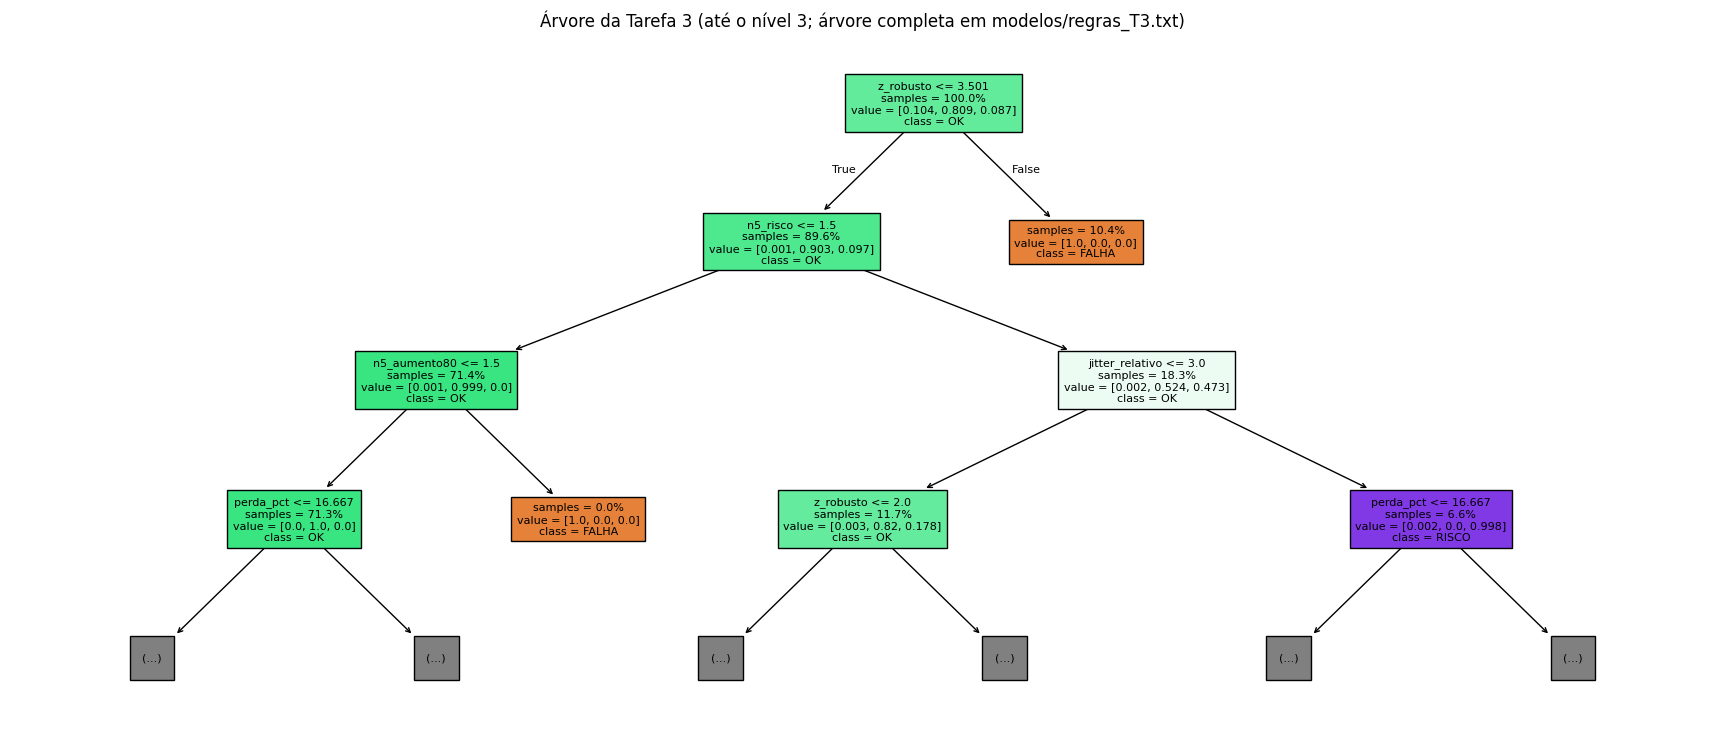

In [ ]:
grade_T3 = buscar(COLUNAS_T3)
display(grade_T3.sort_values("f1_macro_val", ascending=False).head(10).round(4))
esc_T3 = escolher(grade_T3)
PARAMS_T3 = {"criterion": "gini", "max_depth": int(esc_T3["max_depth"]),
             "min_samples_leaf": int(esc_T3["min_samples_leaf"]), "ccp_alpha": 0.0}
arvore_T3 = treinar(COLUNAS_T3, **PARAMS_T3)          # fit só no treino

print(f"Critério: Gini | max_depth pedido: {PARAMS_T3['max_depth']} | min_samples_leaf: {PARAMS_T3['min_samples_leaf']} "
      f"| profundidade obtida: {arvore_T3.get_depth()} | folhas: {arvore_T3.get_n_leaves()} | semente: {SEMENTE}")
print("\nPrimeiras divisões:")
descrever_topo(arvore_T3, COLUNAS_T3)
print("\nRegras lidas da árvore (folha mais numerosa de cada classe):")
regras_T3 = tres_regras(arvore_T3, COLUNAS_T3, tr)

(PASTA_MODELOS / "regras_T3.txt").write_text(export_text(arvore_T3, feature_names=COLUNAS_T3, decimals=3), encoding="utf-8")
fig, ax = plt.subplots(figsize=(22, 9))
plot_tree(arvore_T3, feature_names=COLUNAS_T3, class_names=list(arvore_T3.classes_), max_depth=3,
          filled=True, impurity=False, proportion=True, fontsize=8, ax=ax)
ax.set_title("Árvore da Tarefa 3 (até o nível 3; árvore completa em modelos/regras_T3.txt)")
fig.savefig(PASTA_MODELOS / "arvore_T3.png", dpi=120, bbox_inches="tight")
plt.show()

## 3.3 Leitura do erro (validação)

O teste continua fechado. Matriz 3×3 em contagem, precisão, recall e F1 por classe e F1 macro. Depois, dois erros concretos: um caminho longo estável que caiu em FALHA e uma FALHA de caminho curto que caiu em OK. O escopo vem do índice de auditoria e não da árvore.

In [ ]:
pred_va_T3 = arvore_T3.predict(va[COLUNAS_T3])
metricas_T3 = avaliar(va["classe"], pred_va_T3, "Árvore da Tarefa 3 — validação")

diag_T3 = va.assign(previsto=pred_va_T3).join(AUDITORIA, on="fluxo_id")
cols_erro = ["fluxo_id", "rota", "timestamp_utc", "rtt_ms", "z_robusto", "aumento_pct", "jitter_relativo",
             "perda_pct", "n5_timeout", "n5_aumento80", "n5_risco", "classe", "previsto"]
casos = {
    "Caminho longo estável que caiu em FALHA": diag_T3[(diag_T3["escopo"] == "longo") & (diag_T3["classe"] == "OK") & (diag_T3["previsto"] == "FALHA")],
    "FALHA de caminho curto que caiu em OK":   diag_T3[(diag_T3["escopo"] == "curto") & (diag_T3["classe"] == "FALHA") & (diag_T3["previsto"] == "OK")],
}
for nome, c in casos.items():
    print(f"\n{nome}: {len(c)} na validação")
    if len(c):
        display(c[cols_erro].head(2))
    else:
        print("  O caso não apareceu na validação.")

erros_T3 = diag_T3[diag_T3["classe"] != diag_T3["previsto"]]
print("\nErros mais frequentes (classe real -> prevista):")
display(erros_T3.groupby(["classe", "previsto"]).size().sort_values(ascending=False).rename("medições").to_frame())

Árvore da Tarefa 3 — validação


,prev. OK,prev. RISCO,prev. FALHA
real OK,21912,0,0
real RISCO,0,2840,0
real FALHA,0,2,3199


,precisão,recall,F1,suporte
OK,1.000,1.000,1.0,21912
RISCO,0.999,1.000,1.0,2840
FALHA,1.000,0.999,1.0,3201


F1 macro = 0.9998 | balanced accuracy = 0.9998 | acurácia = 0.9999 (a acurácia não decide: com maioria OK ela fica alta mesmo errando FALHA)

Caminho longo estável que caiu em FALHA: 0 na validação
  O caso não apareceu na validação.

FALHA de caminho curto que caiu em OK: 0 na validação
  O caso não apareceu na validação.

Erros mais frequentes (classe real -> prevista):


,,medições
classe,previsto,
FALHA,RISCO,2


## 3.4 Árvore de contraste (não é o modelo)

Duas árvores, no mesmo treino e com os mesmos hiperparâmetros: **(a)** as colunas oficiais mais `rtt_ms` (RTT absoluto) e `rota_cod` (rota codificada); **(b)** só `rtt_ms` e `rota_cod`. A célula mostra o que cada uma pôs na raiz. **As duas ficam fora da entrega final e não são gravadas como modelo.**

In [ ]:
codigos_rota = {r: i for i, r in enumerate(sorted(df_fluxos["rota"].unique()))}
rota_de = {r: c for c, r in codigos_rota.items()}
for d in (tr, va):
    d["rota_cod"] = d["fluxo_id"].map(AUDITORIA["rota"]).map(codigos_rota)

def raiz(arv, colunas):
    t = arv.tree_
    if t.children_left[0] == -1:
        return "nenhuma divisão"
    col, lim = colunas[t.feature[0]], t.threshold[0]
    if col == "rota_cod":
        esq = [rota_de[i] for i in range(len(rota_de)) if i <= lim]
        return f"rota ∈ {{{', '.join(esq)}}} vs. demais rotas"
    if col == "rtt_ms":
        return f"corte fixo de RTT: rtt_ms ≤ {fmt(lim)} ms"
    return f"{col} ≤ {fmt(lim)}"

contrastes = {"(a) oficiais + RTT absoluto + rota": COLUNAS_T3 + ["rtt_ms", "rota_cod"],
              "(b) só RTT absoluto + rota": ["rtt_ms", "rota_cod"]}
resumo_contraste = []
for nome, cols in contrastes.items():
    arv_c = treinar(cols, **PARAMS_T3)
    m = avaliar(va["classe"], arv_c.predict(va[cols]), mostrar=False)
    imp = pd.Series(arv_c.feature_importances_, index=cols)
    resumo_contraste.append({"árvore": nome, "raiz": raiz(arv_c, cols), "F1 macro (val)": round(m["f1_macro"], 4),
                             "importância rtt_ms + rota_cod": round(imp[["rtt_ms", "rota_cod"]].sum(), 3)})
    if nome.startswith("(b)"):
        arvore_contraste_b = arv_c
display(pd.DataFrame(resumo_contraste).set_index("árvore"))
print(f"Árvore oficial (Tarefa 3): F1 macro na validação = {metricas_T3['f1_macro']:.4f}")

# O que a árvore (b) aprende de distância: proporção prevista de cada classe por escopo
prev_b = pd.Series(arvore_contraste_b.predict(va[["rtt_ms", "rota_cod"]]), index=va.index, name="classe")
print("\nÁrvore (b): % de cada classe prevista por escopo, ao lado do real:")
display(pd.concat({"previsto (b)": pd.crosstab(va["fluxo_id"].map(AUDITORIA["escopo"]).rename("escopo"), prev_b, normalize="index"),
                   "real": pd.crosstab(va["fluxo_id"].map(AUDITORIA["escopo"]).rename("escopo"), va["classe"], normalize="index")},
                  axis=1).mul(100).round(1))
print("Declaração: as árvores de contraste servem só para mostrar o atalho da distância e ficam FORA da entrega final.")

,raiz,F1 macro (val),importância rtt_ms + rota_cod
árvore,,,
(a) oficiais + RTT absoluto + rota,"z_robusto ≤ 3,501",0.9998,0.0
(b) só RTT absoluto + rota,"corte fixo de RTT: rtt_ms ≤ 141,227 ms",0.5571,1.0


Árvore oficial (Tarefa 3): F1 macro na validação = 0.9998

Árvore (b): % de cada classe prevista por escopo, ao lado do real:


previsto (b)              real            
classe          FALHA    OK RISCO FALHA    OK RISCO
escopo                                             
curto             3.1  94.7   2.2  10.0  83.2   6.7
longo             9.4  89.9   0.6  13.8  72.6  13.6
regional          1.7  95.3   3.0  10.2  80.8   9.0

Declaração: as árvores de contraste servem só para mostrar o atalho da distância e ficam FORA da entrega final.


In [ ]:
joblib.dump(arvore_T3, PASTA_MODELOS / "arvore_T3.joblib")
(PASTA_CONFIG / "arvore_T3.json").write_text(json.dumps(
    {"colunas": COLUNAS_T3, "parametros": PARAMS_T3, "semente": SEMENTE,
     "profundidade": int(arvore_T3.get_depth()), "folhas": int(arvore_T3.get_n_leaves()),
     "validacao": {k: v for k, v in metricas_T3.items()}, "regras": regras_T3}, ensure_ascii=False, indent=2), encoding="utf-8")
registrar_evidencia("3.2", f"Árvore T3 (Gini, max_depth {PARAMS_T3['max_depth']}, folha mín. {PARAMS_T3['min_samples_leaf']}): "
                    f"profundidade {arvore_T3.get_depth()}, {arvore_T3.get_n_leaves()} folhas, "
                    f"F1 macro val {metricas_T3['f1_macro']:.4f}", AUTOR_T3)
registrar_evidencia("3.4", "Árvores de contraste: " + "; ".join(f"{r['árvore']} -> raiz {r['raiz']}" for r in resumo_contraste), AUTOR_T3)

Evidência registrada: 2026-10-07T18:22:05+00:00 | 3.2
Evidência registrada: 2026-10-07T18:22:05+00:00 | 3.4


---
# TAREFA 4 — Ajuste da árvore a partir do erro

> Mesmo baseline, mesmo rótulo, mesmo corte, **mesmo algoritmo**. Ajustes permitidos: profundidade, mínimo de amostras na folha, critério (Gini ou entropia) e poda (`ccp_alpha`). Coluna nova só se for **relativa ao baseline**.

## 4.1 O que o erro pediu

A célula abaixo resume os erros da árvore da Tarefa 3 na validação: pares de classe confundidos, erro por linha da tabela de rótulo (mostra qual regra a árvore não reproduziu), erro por escopo (só auditoria), picos isolados que viraram FALHA e o recall de RISCO.

Também cria quatro **colunas relativas novas** (dicionário v0.3). Todas usam só medições anteriores ou a atual do mesmo fluxo:

| Coluna | Cálculo |
|---|---|
| `z_tendencia` | `z_robusto` atual − média do `z_robusto` nas 3 medições anteriores |
| `z_max5` | maior `z_robusto` nas últimas 5 medições |
| `n5_jitter3` | quantas das últimas 5 têm `jitter_relativo` ≥ 3 |
| `perda_media5` | média de `perda_pct` nas últimas 5 |

In [ ]:
AUTOR_T4 = "Hendrick Ambriola"
g = dados.groupby("fluxo_id", sort=False)
dados["z_tendencia"]  = dados["z_robusto"] - g["z_robusto"].transform(lambda s: s.shift(1).rolling(3, min_periods=1).mean())
dados["z_max5"]       = g["z_robusto"].transform(lambda s: s.rolling(5, min_periods=1).max())
dados["n5_jitter3"]   = g["jitter_relativo"].transform(lambda s: (s >= 3).astype(int).rolling(5, min_periods=1).sum())
dados["perda_media5"] = g["perda_pct"].transform(lambda s: s.rolling(5, min_periods=1).mean())
NOVAS_T4 = ["z_tendencia", "z_max5", "n5_jitter3", "perda_media5"]
assert not set(NOVAS_T4) & set(PROIBIDAS)
tr, va, te, nv = blocos(dados)

diag = va.assign(previsto=arvore_T3.predict(va[COLUNAS_T3])).join(AUDITORIA, on="fluxo_id")
diag["erro"] = (diag["classe"] != diag["previsto"]).astype(int)

print("1) Pares confundidos (real -> previsto):")
display(diag[diag["erro"] == 1].groupby(["classe", "previsto"]).size().sort_values(ascending=False).rename("medições").to_frame())
print("2) Erro por linha da tabela de rótulo:")
display(diag.groupby("regra").agg(medicoes=("erro", "size"), erros=("erro", "sum"))
        .assign(pct_erro=lambda t: (t["erros"] / t["medicoes"] * 100).round(2))
        .rename(index=REGRAS_TXT))
print("3) Erro por escopo (só auditoria):")
display(diag.groupby("escopo")["erro"].agg(["size", "sum", "mean"]).rename(columns={"size": "medições", "sum": "erros", "mean": "taxa"}).round(4))
pico = int(((diag["classe"] == "OK") & (diag["aumento_pct"] > 80) & (diag["previsto"] == "FALHA")).sum())
print(f"4) Pico isolado (OK com aumento > 80%) previsto como FALHA: {pico}")
print(f"5) Recall de RISCO na T3: {metricas_T3['recall_RISCO']:.3f} | recall de FALHA: {metricas_T3['recall_FALHA']:.3f}")

1) Pares confundidos (real -> previsto):


,,medições
classe,previsto,
FALHA,RISCO,2


2) Erro por linha da tabela de rótulo:


,medicoes,erros,pct_erro
regra,,,
1 FALHA: perda_pct ≥ 10,42,0,0.00
"3 FALHA: z_robusto ≥ 3,5",3149,2,0.06
4 FALHA: n5_aumento80 ≥ 2,10,0,0.00
5 RISCO: critério atual e n5_risco ≥ 2,2840,0,0.00
6 OK,21912,0,0.00


3) Erro por escopo (só auditoria):


,medições,erros,taxa
escopo,,,
curto,5993,1,0.0002
longo,9982,1,0.0001
regional,11978,0,0.0000


4) Pico isolado (OK com aumento > 80%) previsto como FALHA: 0
5) Recall de RISCO na T3: 1.000 | recall de FALHA: 0.999


**Erro da Tarefa 3 → mudança na árvore** (números da validação; cada linha é um experimento da seção 4.2)

| Erro observado na T3 (validação) | Mudança testada | Resultado na validação |
|---|---|---|
| Confusão RISCO ↔ FALHA: 2 FALHA previstas como RISCO, ambas da regra 3 (`z_robusto` ≥ 3,5; 0,06% de erro nessa regra) | critério entropia | ΔF1 macro = 0,0000; mesmas 13 folhas e recall de FALHA 0,9994 |
| Pico isolado virando FALHA: 0 casos; risco de folhas pequenas decorarem o treino | `min_samples_leaf` = 20 | ΔF1 macro = −0,0018; recall de FALHA cai para 0,9922 |
| RISCO sumindo: não aconteceu (recall de RISCO = 1,000; regra 5 com 0% de erro) | profundidade + 2 (`max_depth` 8) | ΔF1 macro = 0,0000; a profundidade real continua 6 |
| Árvore com 13 folhas, possivelmente maior que o necessário | poda `ccp_alpha` = 1e-4 e 1e-3 | ΔF1 macro = −0,0004 (10 folhas) e −0,0018 (5 folhas) |
| Erros espalhados em fluxos diferentes (1 em caminho curto, 1 em longo) | 4 colunas relativas novas (`z_tendencia`, `z_max5`, `n5_jitter3`, `perda_media5`) | ΔF1 macro = 0,0000 com os parâmetros da T3 |

**Busca combinada (288 combinações):** nenhuma superou o F1 macro da T3 (0,9998). Pela regra de desempate, a árvore escolhida é Gini, `max_depth` 5, com as colunas novas: **11 folhas** em vez de 13, com o mesmo F1 macro e o mesmo recall de FALHA (0,9994). Sem as colunas novas, a profundidade 5 chegava a F1 0,9996 e recall de FALHA 0,9988. As colunas novas permitiram, portanto, uma árvore menor sem perder desempenho.

## 4.2 Experimentos e árvore ajustada

Primeiro, **uma mudança de cada vez** a partir da árvore da T3, para ligar cada mudança a um erro. Depois, uma busca combinada. Tudo é escolhido na **validação**, com a mesma regra de escolha da T3.

In [ ]:
p3 = PARAMS_T3
experimentos = [
    ("T3 (referência)",            dict(p3),                                                          COLUNAS_T3, "—"),
    ("critério entropia",          {**p3, "criterion": "entropy"},                                    COLUNAS_T3, "confusão RISCO ↔ FALHA"),
    ("folha mínima maior",         {**p3, "min_samples_leaf": max(4 * p3["min_samples_leaf"], 20)},    COLUNAS_T3, "pico isolado / folhas pequenas"),
    ("profundidade + 2",           {**p3, "max_depth": p3["max_depth"] + 2},                          COLUNAS_T3, "RISCO sumindo (regra 5)"),
    ("poda ccp_alpha = 1e-4",      {**p3, "ccp_alpha": 1e-4},                                         COLUNAS_T3, "árvore decorando o treino"),
    ("poda ccp_alpha = 1e-3",      {**p3, "ccp_alpha": 1e-3},                                         COLUNAS_T3, "árvore decorando o treino"),
    ("+ colunas relativas novas",  dict(p3),                                                          COLUNAS_T3 + NOVAS_T4, "erros em sequência no fluxo"),
]
linhas_exp = []
for nome, params, cols, erro_alvo in experimentos:
    arv = treinar(cols, **params)
    m = avaliar(va["classe"], arv.predict(va[cols]), mostrar=False)
    linhas_exp.append({"mudança": nome, "erro que ataca": erro_alvo, "profundidade": arv.get_depth(),
                       "folhas": arv.get_n_leaves(), "F1 macro": m["f1_macro"],
                       "recall FALHA": m["recall_FALHA"], "recall RISCO": m["recall_RISCO"]})
tab_exp = pd.DataFrame(linhas_exp).set_index("mudança")
tab_exp["Δ F1 macro vs T3"] = tab_exp["F1 macro"] - tab_exp.loc["T3 (referência)", "F1 macro"]
display(tab_exp.round(4))

# Busca combinada (só validação)
grade_T4 = pd.concat([
    buscar(COLUNAS_T3, ("gini", "entropy"), (3, 4, 5, 6, 8, 10), (1, 10, 50, 200), (0.0, 1e-4, 1e-3)).assign(colunas="T3"),
    buscar(COLUNAS_T3 + NOVAS_T4, ("gini", "entropy"), (3, 4, 5, 6, 8, 10), (1, 10, 50, 200), (0.0, 1e-4, 1e-3)).assign(colunas="T3 + novas"),
], ignore_index=True)
esc_T4 = escolher(grade_T4)
COLUNAS_T4 = COLUNAS_T3 + (NOVAS_T4 if esc_T4["colunas"] == "T3 + novas" else [])
PARAMS_T4 = {"criterion": esc_T4["criterio"], "max_depth": int(esc_T4["max_depth"]),
             "min_samples_leaf": int(esc_T4["min_samples_leaf"]), "ccp_alpha": float(esc_T4["ccp_alpha"])}
print(f"{len(grade_T4)} combinações testadas. Melhores na validação:")
display(grade_T4.sort_values("f1_macro_val", ascending=False).head(8).round(4))

arvore_T4 = treinar(COLUNAS_T4, **PARAMS_T4)          # fit só no treino
assert not set(COLUNAS_T4) & set(PROIBIDAS)
print(f"\nParâmetros finais candidatos: {PARAMS_T4} | colunas: {esc_T4['colunas']}")
print(f"Profundidade obtida: {arvore_T4.get_depth()} | folhas: {arvore_T4.get_n_leaves()}")
print("\nPrimeiras divisões:")
descrever_topo(arvore_T4, COLUNAS_T4)
print("\nRegras:")
regras_T4 = tres_regras(arvore_T4, COLUNAS_T4, tr)
(PASTA_MODELOS / "regras_T4.txt").write_text(export_text(arvore_T4, feature_names=COLUNAS_T4, decimals=3), encoding="utf-8")

,erro que ataca,profundidade,folhas,F1 macro,recall FALHA,recall RISCO,Δ F1 macro vs T3
mudança,,,,,,,
T3 (referência),—,6,13,0.9998,0.9994,1.0,0.0000
critério entropia,confusão RISCO ↔ FALHA,6,13,0.9998,0.9994,1.0,0.0000
folha mínima maior,pico isolado / folhas pequenas,6,22,0.9979,0.9922,1.0,-0.0018
profundidade + 2,RISCO sumindo (regra 5),6,13,0.9998,0.9994,1.0,0.0000
poda ccp_alpha = 1e-4,árvore decorando o treino,6,10,0.9993,0.9981,1.0,-0.0004
poda ccp_alpha = 1e-3,árvore decorando o treino,4,5,0.9979,0.9922,1.0,-0.0018
+ colunas relativas novas,erros em sequência no fluxo,6,13,0.9998,0.9994,1.0,0.0000


288 combinações testadas. Melhores na validação:


,criterio,max_depth,min_samples_leaf,ccp_alpha,profundidade_real,folhas,f1_macro_val,recall_FALHA_val,recall_RISCO_val,colunas
277,entropy,10,1,0.0001,6,13,0.9998,0.9994,1.0,T3 + novas
276,entropy,10,1,0.0000,6,13,0.9998,0.9994,1.0,T3 + novas
36,gini,6,1,0.0000,6,13,0.9998,0.9994,1.0,T3
108,entropy,6,1,0.0000,6,13,0.9998,0.9994,1.0,T3
121,entropy,8,1,0.0001,6,13,0.9998,0.9994,1.0,T3
120,entropy,8,1,0.0000,6,13,0.9998,0.9994,1.0,T3
60,gini,10,1,0.0000,6,13,0.9998,0.9994,1.0,T3
48,gini,8,1,0.0000,6,13,0.9998,0.9994,1.0,T3



Parâmetros finais candidatos: {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 1, 'ccp_alpha': 0.0} | colunas: T3 + novas
Profundidade obtida: 5 | folhas: 11

Primeiras divisões:
nível 0: z_robusto ≤ 3,501  (70.560 medições do treino)
    nível 1: n5_risco ≤ 1,5  (63.250 medições do treino)
        nível 2: n5_aumento80 ≤ 1,5  (50.351 medições do treino)
        nível 2: jitter_relativo ≤ 3  (12.899 medições do treino)

Regras:


1. Se z_robusto > 3,501 (ou vazio), então **FALHA** (folha com 7.310 medições do treino; 100.0% delas são FALHA).
2. Se z_robusto ≤ 3,501 e n5_risco > 1,5 e jitter_relativo > 3 (ou vazio) e perda_pct ≤ 16,667 e n5_aumento80 ≤ 1,5, então **RISCO** (folha com 4.640 medições do treino; 100.0% delas são RISCO).
3. Se z_robusto ≤ 3,501 e n5_risco ≤ 1,5 e n5_aumento80 ≤ 1,5 e perda_pct ≤ 16,667, então **OK** (folha com 50.325 medições do treino; 100.0% delas são OK).

1098

## 4.3 Comparação na validação (Tarefa 3 → Tarefa 4)

In [ ]:
metricas_T4 = avaliar(va["classe"], arvore_T4.predict(va[COLUNAS_T4]), "Árvore da Tarefa 4 — validação")
comp = pd.DataFrame({
    "F1 macro":        [metricas_T3["f1_macro"],     metricas_T4["f1_macro"]],
    "Recall de FALHA": [metricas_T3["recall_FALHA"], metricas_T4["recall_FALHA"]],
    "Recall de RISCO": [metricas_T3["recall_RISCO"], metricas_T4["recall_RISCO"]],
}, index=["Árvore da Tarefa 3", "Árvore desta tarefa"]).round(4)
display(comp)

ganho = metricas_T4["f1_macro"] - metricas_T3["f1_macro"]
mesmos = (PARAMS_T4 == PARAMS_T3) and (COLUNAS_T4 == COLUNAS_T3)
if mesmos:
    leitura = ("Nenhuma mudança superou a árvore da T3 na validação: a T4 mantém os mesmos parâmetros. "
               "Tentado e descartado: " + "; ".join(tab_exp.index[1:]) + ".")
elif ganho > 0.002:
    leitura = (f"Ganho de {ganho:+.4f} no F1 macro; recall de FALHA {metricas_T3['recall_FALHA']:.3f} → {metricas_T4['recall_FALHA']:.3f} "
               f"e de RISCO {metricas_T3['recall_RISCO']:.3f} → {metricas_T4['recall_RISCO']:.3f}.")
else:
    leitura = (f"Diferença de F1 macro pequena ({ganho:+.4f}). A T4 foi escolhida pela regra de desempate "
               "(recall de FALHA e depois a árvore menor).")
print("Leitura:", leitura)

joblib.dump(arvore_T4, PASTA_MODELOS / "arvore_T4.joblib")
(PASTA_CONFIG / "arvore_T4.json").write_text(json.dumps(
    {"colunas": COLUNAS_T4, "parametros": PARAMS_T4, "semente": SEMENTE,
     "profundidade": int(arvore_T4.get_depth()), "folhas": int(arvore_T4.get_n_leaves()),
     "validacao": metricas_T4, "comparacao_T3": comp.to_dict(), "leitura": leitura, "regras": regras_T4},
    ensure_ascii=False, indent=2), encoding="utf-8")
registrar_evidencia("4.3", f"T3 -> T4 na validação: F1 macro {metricas_T3['f1_macro']:.4f} -> {metricas_T4['f1_macro']:.4f}; "
                    f"recall FALHA {metricas_T3['recall_FALHA']:.3f} -> {metricas_T4['recall_FALHA']:.3f}; "
                    f"parâmetros {PARAMS_T4}", AUTOR_T4)

Árvore da Tarefa 4 — validação


,prev. OK,prev. RISCO,prev. FALHA
real OK,21912,0,0
real RISCO,0,2840,0
real FALHA,0,2,3199


,precisão,recall,F1,suporte
OK,1.000,1.000,1.0,21912
RISCO,0.999,1.000,1.0,2840
FALHA,1.000,0.999,1.0,3201


F1 macro = 0.9998 | balanced accuracy = 0.9998 | acurácia = 0.9999 (a acurácia não decide: com maioria OK ela fica alta mesmo errando FALHA)


,F1 macro,Recall de FALHA,Recall de RISCO
Árvore da Tarefa 3,0.9998,0.9994,1.0
Árvore desta tarefa,0.9998,0.9994,1.0


Leitura: Diferença de F1 macro pequena (+0.0000). A T4 foi escolhida pela regra de desempate (recall de FALHA e depois a árvore menor).
Evidência registrada: 2026-10-07T18:25:25+00:00 | 4.3


### Dicionário de dados v0.3

Tudo da v0.2, mais as colunas relativas criadas na 4.1 (só entram na árvore se a busca da 4.2 as escolheu; ver `config/arvore_T4.json`):

| Coluna | Unidade | Cálculo | Se faltar |
|---|---|---|---|
| `z_tendencia` | — | `z_robusto` atual − média de `z_robusto` nas 3 medições anteriores do fluxo | vazio se o atual ou as 3 anteriores não têm z |
| `z_max5` | — | maior `z_robusto` nas últimas 5 medições (inclui a atual) | vazio se nenhuma das 5 tem z |
| `n5_jitter3` | 0 a 5 | quantas das últimas 5 têm `jitter_relativo` ≥ 3 | — |
| `perda_media5` | % | média de `perda_pct` nas últimas 5 | — |

Continuam proibidos: país, IP, rota, `fluxo_id` e RTT absoluto.

## 4.4 Revisão com o docente

**O que foi mostrado:** _(preencher)_  
**O que foi pedido para ajustar antes da Tarefa 5:** _(preencher)_

---
# TAREFA 5 — Árvore final e teste único

> A árvore é a da Tarefa 4; o baseline e o rótulo são os da Tarefa 2. Os parâmetros são **gravados antes** de o teste ser aberto. O teste é medido **uma vez**: a célula grava `data/processed/teste_unico.json` com o horário de abertura. Nada é reescolhido depois disso.

## 5.1 Árvore que será medida

In [ ]:
AUTOR_T5 = "Geziel de Andrade"
info_T4 = json.loads((PASTA_CONFIG / "arvore_T4.json").read_text(encoding="utf-8"))
arvore_final = joblib.load(PASTA_MODELOS / "arvore_T4.joblib")
COLUNAS_FINAL, PARAMS_FINAL = info_T4["colunas"], info_T4["parametros"]
assert not set(COLUNAS_FINAL) & set(PROIBIDAS), "Coluna proibida na árvore final"
assert list(arvore_final.feature_names_in_) == COLUNAS_FINAL

arq_final = PASTA_CONFIG / "arvore_final.json"
congelado = {"colunas": COLUNAS_FINAL, "parametros": PARAMS_FINAL, "semente": SEMENTE,
             "profundidade": int(arvore_final.get_depth()), "folhas": int(arvore_final.get_n_leaves())}
if arq_final.exists():
    anterior = json.loads(arq_final.read_text(encoding="utf-8"))
    assert {k: anterior[k] for k in congelado} == congelado, "A árvore mudou depois de congelada para o teste"
else:
    arq_final.write_text(json.dumps({**congelado, "congelada_em_utc": datetime.now(timezone.utc).isoformat(timespec="seconds")},
                                    ensure_ascii=False, indent=2), encoding="utf-8")

print("Parâmetros:", PARAMS_FINAL, "| semente:", SEMENTE)
print(f"Profundidade: {arvore_final.get_depth()} | folhas: {arvore_final.get_n_leaves()}")
print("Colunas:", COLUNAS_FINAL)
print("País, IP, rota e RTT absoluto na árvore?", "NÃO" if not set(COLUNAS_FINAL) & set(PROIBIDAS) else "SIM")
print("\nRegras (as mesmas da Tarefa 4, lidas antes de abrir o teste):")
regras_final = tres_regras(arvore_final, COLUNAS_FINAL, tr)

Parâmetros: {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 1, 'ccp_alpha': 0.0} | semente: 42
Profundidade: 5 | folhas: 11
Colunas: ['z_robusto', 'aumento_pct', 'jitter_relativo', 'perda_pct', 'timeout_atual', 'n5_timeout', 'n5_aumento80', 'n5_risco', 'z_tendencia', 'z_max5', 'n5_jitter3', 'perda_media5']
País, IP, rota e RTT absoluto na árvore? NÃO

Regras (as mesmas da Tarefa 4, lidas antes de abrir o teste):


1. Se z_robusto > 3,501 (ou vazio), então **FALHA** (folha com 7.310 medições do treino; 100.0% delas são FALHA).
2. Se z_robusto ≤ 3,501 e n5_risco > 1,5 e jitter_relativo > 3 (ou vazio) e perda_pct ≤ 16,667 e n5_aumento80 ≤ 1,5, então **RISCO** (folha com 4.640 medições do treino; 100.0% delas são RISCO).
3. Se z_robusto ≤ 3,501 e n5_risco ≤ 1,5 e n5_aumento80 ≤ 1,5 e perda_pct ≤ 16,667, então **OK** (folha com 50.325 medições do treino; 100.0% delas são OK).

## 5.2 Teste temporal (uma vez)

Fluxos conhecidos, trecho mais recente do Período B (bloco `teste` da Tarefa 2). A árvore é comparada com a regra "sempre a classe majoritária do treino" (RFC, critério 2).

In [ ]:
arq_teste = PASTA_PROCESSED / "teste_unico.json"
if arq_teste.exists():
    print("ATENÇÃO: o teste já foi aberto em", json.loads(arq_teste.read_text(encoding="utf-8"))["aberto_em_utc"],
          "— os números abaixo são os mesmos e não podem ser usados para escolher nada.")

pred_te = arvore_final.predict(te[COLUNAS_FINAL])
metricas_teste = avaliar(te["classe"], pred_te, "Árvore final — TESTE (único)")

# Referência do RFC (critério 2): prever sempre a classe majoritária do treino
classe_majoritaria = tr["classe"].value_counts().idxmax()
metricas_maj = avaliar(te["classe"], np.full(len(te), classe_majoritaria), mostrar=False)
display(pd.DataFrame({"F1 macro": [metricas_teste["f1_macro"], metricas_maj["f1_macro"]],
                      "balanced accuracy": [metricas_teste["balanced_accuracy"], metricas_maj["balanced_accuracy"]],
                      "recall FALHA": [metricas_teste["recall_FALHA"], metricas_maj["recall_FALHA"]]},
                     index=["árvore final", f"sempre {classe_majoritaria} (classe majoritária)"]).round(4))
print("A árvore supera a classe majoritária no F1 macro?",
      "SIM" if metricas_teste["f1_macro"] > metricas_maj["f1_macro"] else "NÃO")
cm = np.array(metricas_teste["matriz"])
i_r, i_f, i_o = CLASSES.index("RISCO"), CLASSES.index("FALHA"), CLASSES.index("OK")
print(f"Recall de FALHA: {metricas_teste['recall_FALHA']:.3f} | FALHA real prevista como RISCO: {cm[i_f, i_r]} "
      f"e como OK: {cm[i_f, i_o]} | RISCO real previsto como FALHA: {cm[i_r, i_f]}")

if not arq_teste.exists():
    arq_teste.write_text(json.dumps({"aberto_em_utc": datetime.now(timezone.utc).isoformat(timespec="seconds"),
                                     "arvore": congelado, "metricas": metricas_teste,
                                     "classe_majoritaria": {"classe": classe_majoritaria, "metricas": metricas_maj}}, ensure_ascii=False, indent=2),
                         encoding="utf-8")

# Dois casos: acerto em caminho longo estável (OK) e um erro relevante
diag_te = te.assign(previsto=pred_te).join(AUDITORIA, on="fluxo_id")
cols_caso = ["fluxo_id", "rota", "timestamp_utc", "rtt_ms", "z_robusto", "aumento_pct", "perda_pct",
             "n5_timeout", "n5_aumento80", "n5_risco", "classe", "previsto"]
c = diag_te[(diag_te["escopo"] == "longo") & (diag_te["classe"] == "OK") & (diag_te["previsto"] == "OK")]
caso_ok = c.loc[c["rtt_ms"].idxmax()] if len(c) else None
caso_erro, tipo_erro = None, "nenhum erro no teste"
for real, prev in [("FALHA", "OK"), ("RISCO", "OK"), ("FALHA", "RISCO"), ("OK", "FALHA"), ("RISCO", "FALHA"), ("OK", "RISCO")]:
    c = diag_te[(diag_te["classe"] == real) & (diag_te["previsto"] == prev)]
    if len(c):
        caso_erro, tipo_erro = c.iloc[0], f"{real} previsto como {prev}"
        break
casos_te = {k: v for k, v in {"Acerto: caminho longo estável (OK)": caso_ok, f"Erro: {tipo_erro}": caso_erro}.items() if v is not None}
display(pd.DataFrame([v[cols_caso] for v in casos_te.values()], index=list(casos_te)).T)

Árvore final — TESTE (único)


,prev. OK,prev. RISCO,prev. FALHA
real OK,33159,0,0
real RISCO,0,4996,0
real FALHA,2,2,3653


,precisão,recall,F1,suporte
OK,1.0,1.000,1.000,33159
RISCO,1.0,1.000,1.000,4996
FALHA,1.0,0.999,0.999,3657


F1 macro = 0.9997 | balanced accuracy = 0.9996 | acurácia = 0.9999 (a acurácia não decide: com maioria OK ela fica alta mesmo errando FALHA)


,F1 macro,balanced accuracy,recall FALHA
árvore final,0.9997,0.9996,0.9989
sempre OK (classe majoritária),0.2949,0.3333,0.0000


A árvore supera a classe majoritária no F1 macro? SIM
Recall de FALHA: 0.999 | FALHA real prevista como RISCO: 2 e como OK: 2 | RISCO real previsto como FALHA: 0


,Acerto: caminho longo estável (OK),Erro: FALHA previsto como OK
fluxo_id,6410|103.202.216.76,6349|103.202.216.76
rota,BR->JP,BR->JP
timestamp_utc,2026-09-19 12:07:16+00:00,2026-09-19 03:03:05+00:00
rtt_ms,300.636288,288.316731
z_robusto,2.486552,1.615564
aumento_pct,4.925274,1.127728
perda_pct,0.0,33.333333
n5_timeout,0,0
n5_aumento80,0,0
n5_risco,1,4


In [ ]:
registrar_evidencia("5.2", f"Teste único aberto: F1 macro {metricas_teste['f1_macro']:.4f}, recall FALHA "
                    f"{metricas_teste['recall_FALHA']:.3f}, matriz {metricas_teste['matriz']}; "
                    f"classe majoritária ({classe_majoritaria}): F1 macro {metricas_maj['f1_macro']:.4f}", AUTOR_T5)

Evidência registrada: 2026-10-07T18:25:26+00:00 | 5.2


## 5.3 Fluxo que a árvore não viu

Os fluxos de `DESTINOS_NAO_VISTOS` foram separados na Tarefa 2, **antes** de qualquer árvore. A ficha de cada um vem só do Período A dele (mesmo piso de 1.500 RTT válidos), e a avaliação usa o Período B inteiro desses fluxos. A célula responde às duas perguntas do RFC (critério 4): o caminho longo estável continuou OK? A degradação do caminho curto foi marcada RISCO ou FALHA?

In [ ]:
fluxos_nv = corte["fluxos_nao_vistos"]
if not fluxos_nv or nv.empty:
    print("Não sobrou fluxo com baseline suficiente para esta checagem. A conta não foi forçada.")
else:
    assert not set(fluxos_nv) & set(tr["fluxo_id"]) and not set(fluxos_nv) & set(va["fluxo_id"]), "Fluxo não visto vazou"
    ficha_nv = pd.read_csv(PASTA_PROCESSED / "baseline_por_fluxo.csv").set_index("fluxo_id").loc[fluxos_nv]
    assert (pd.to_datetime(ficha_nv["fim_A"]) < INICIO_B).all() and (pd.to_datetime(nv["timestamp_utc"]) >= INICIO_B).all(), \
        "Mediana e MAD não podem usar o trecho avaliado"
    print("Fichas dos fluxos não vistos (só Período A):")
    display(ficha_nv[["status", "n_rtt_validos_A", "mediana", "MAD", "fim_A"]].join(AUDITORIA[["rota", "escopo"]]).round(3))

    pred_nv = arvore_final.predict(nv[COLUNAS_FINAL])
    metricas_nv = avaliar(nv["classe"], pred_nv, "Árvore final — fluxos não vistos (Período B inteiro)")
    d_nv = nv.assign(previsto=pred_nv).join(AUDITORIA, on="fluxo_id")
    por_fluxo_nv = d_nv.groupby(["fluxo_id", "rota", "escopo"]).apply(lambda g: pd.Series({
        "medições": len(g),
        "OK real": int((g["classe"] == "OK").sum()),
        "% dos OK mantidos OK": (g.loc[g["classe"] == "OK", "previsto"] == "OK").mean() * 100,
        "degradações reais (RISCO+FALHA)": int((g["classe"] != "OK").sum()),
        "degradações marcadas RISCO ou FALHA": int(((g["classe"] != "OK") & (g["previsto"] != "OK")).sum()),
    }), include_groups=False).round(2)
    display(por_fluxo_nv)

    longos = d_nv[(d_nv["escopo"] == "longo") & (d_nv["classe"] == "OK")]
    degr = d_nv[d_nv["classe"] != "OK"]
    texto_nv = (f"Caminho longo estável: {(longos['previsto'] == 'OK').mean():.1%} das medições OK continuaram OK. "
                if len(longos) else "Não há fluxo longo entre os não vistos. ")
    curtos_degr = d_nv[(d_nv["escopo"] == "curto") & (d_nv["classe"] != "OK")]
    texto_nv += (f"Caminho curto degradado: {(curtos_degr['previsto'] != 'OK').mean():.1%} das {len(curtos_degr)} medições "
                 "RISCO/FALHA reais foram marcadas como RISCO ou FALHA. "
                 if len(curtos_degr) else "Não há degradação real em fluxo curto entre os não vistos. ")
    texto_nv += (f"Todas as degradações: {len(degr)} medições RISCO/FALHA reais, {(degr['previsto'] != 'OK').mean():.1%} marcadas como RISCO ou FALHA."
                 if len(degr) else "Nenhuma degradação real nesses fluxos durante o Período B.")
    print(texto_nv)
    registrar_evidencia("5.3", f"Fluxos não vistos ({len(fluxos_nv)}): F1 macro {metricas_nv['f1_macro']:.4f}. " + texto_nv, AUTOR_T5)

Fichas dos fluxos não vistos (só Período A):


,status,n_rtt_validos_A,mediana,MAD,fim_A,rota,escopo
fluxo_id,,,,,,,
6349|43.228.174.199,ok,2499,296.558,1.550,2026-09-13T04:29:50+00:00,BR->JP,longo
6410|200.132.1.32,ok,2511,16.522,0.540,2026-09-13T04:30:12+00:00,BR->BR,curto
6410|43.228.174.199,ok,2509,305.813,3.567,2026-09-13T04:29:39+00:00,BR->JP,longo
6659|200.132.1.32,ok,2520,15.719,0.448,2026-09-13T04:30:10+00:00,BR->BR,curto
6659|43.228.174.199,ok,2511,271.639,0.331,2026-09-13T04:29:41+00:00,BR->JP,longo
6891|200.132.1.32,ok,2518,23.284,0.671,2026-09-13T04:30:13+00:00,BR->BR,curto
6891|43.228.174.199,ok,2502,271.985,1.815,2026-09-13T04:29:51+00:00,BR->JP,longo
7019|200.132.1.32,ok,2519,11.872,0.064,2026-09-13T04:30:21+00:00,BR->BR,curto


Árvore final — fluxos não vistos (Período B inteiro)


,prev. OK,prev. RISCO,prev. FALHA
real OK,17488,1,0
real RISCO,0,1264,0
real FALHA,1,0,1354


,precisão,recall,F1,suporte
OK,1.000,1.000,1.0,17489
RISCO,0.999,1.000,1.0,1264
FALHA,1.000,0.999,1.0,1355


F1 macro = 0.9997 | balanced accuracy = 0.9997 | acurácia = 0.9999 (a acurácia não decide: com maioria OK ela fica alta mesmo errando FALHA)


,,,medições,OK real,% dos OK mantidos OK,degradações reais (RISCO+FALHA),degradações marcadas RISCO ou FALHA
fluxo_id,rota,escopo,,,,,
6349|43.228.174.199,BR->JP,longo,2519.0,2146.0,100.00,373.0,372.0
6410|200.132.1.32,BR->BR,curto,2511.0,2036.0,100.00,475.0,475.0
6410|43.228.174.199,BR->JP,longo,2516.0,2409.0,100.00,107.0,107.0
6659|200.132.1.32,BR->BR,curto,2508.0,2403.0,99.96,105.0,105.0
6659|43.228.174.199,BR->JP,longo,2508.0,2131.0,100.00,377.0,377.0
6891|200.132.1.32,BR->BR,curto,2516.0,2141.0,100.00,375.0,375.0
6891|43.228.174.199,BR->JP,longo,2518.0,1873.0,100.00,645.0,645.0
7019|200.132.1.32,BR->BR,curto,2512.0,2350.0,100.00,162.0,162.0


Caminho longo estável: 100.0% das medições OK continuaram OK. Caminho curto degradado: 100.0% das 1117 medições RISCO/FALHA reais foram marcadas como RISCO ou FALHA. Todas as degradações: 2619 medições RISCO/FALHA reais, 100.0% marcadas como RISCO ou FALHA.
Evidência registrada: 2026-10-07T18:25:27+00:00 | 5.3


## 5.4 O que declarar

**(a) A árvore repete a tabela de rótulo?** O rótulo foi feito com as mesmas métricas que a árvore lê. Uma concordância muito alta quer dizer que a árvore aprendeu a **política** da Tarefa 2, não um "ticket de roteador".

**(b) Detector ou preditor?** A Tarefa 1 definiu o preditor como o estado **12 minutos à frente** (3 × 240 s). Para cada medição, o alvo futuro é a classe da medição do mesmo fluxo mais próxima de t + 720 s (tolerância de ±120 s; sem medição nessa faixa, a linha sai). O alvo futuro tem de ficar no mesmo bloco, para o treino não enxergar a validação nem o teste. Uma árvore com os **mesmos parâmetros da final** (nada reescolhido) é comparada no teste com a regra "repetir a classe atual".

In [ ]:
concordancia = (pred_te == te["classe"].to_numpy()).mean()
print(f"(a) A árvore final concorda com a tabela de rótulo em {concordancia:.2%} das medições do teste.")

H = 3 * INTERVALO_S
futuro = dados[["fluxo_id", "timestamp", "classe", "bloco"]].rename(
    columns={"timestamp": "ts_fut", "classe": "classe_futura", "bloco": "bloco_fut"})
base_pred = dados.assign(ts_alvo=dados["timestamp"] + H)
m = pd.merge_asof(base_pred.sort_values("ts_alvo"), futuro.sort_values("ts_fut"),
                  left_on="ts_alvo", right_on="ts_fut", by="fluxo_id", direction="nearest", tolerance=INTERVALO_S // 2)
m = m[m["classe_futura"].notna() & (m["bloco"] == m["bloco_fut"])]
tr_p, te_p = m[m["bloco"] == "treino"], m[m["bloco"] == "teste"]

arvore_preditor = DecisionTreeClassifier(**PARAMS_FINAL, random_state=SEMENTE).fit(tr_p[COLUNAS_FINAL], tr_p["classe_futura"])
met_pred = avaliar(te_p["classe_futura"], arvore_preditor.predict(te_p[COLUNAS_FINAL]), "Preditor (+12 min) — árvore, teste", mostrar=False)
met_pers = avaliar(te_p["classe_futura"], te_p["classe"], "Repetir a classe atual", mostrar=False)
comp_pred = pd.DataFrame({"F1 macro": [met_pred["f1_macro"], met_pers["f1_macro"]],
                          "Recall FALHA": [met_pred["recall_FALHA"], met_pers["recall_FALHA"]],
                          "Recall RISCO": [met_pred["recall_RISCO"], met_pers["recall_RISCO"]]},
                         index=["árvore (+12 min)", "repetir a classe atual"]).round(4)
print(f"\n(b) Estado 12 minutos à frente, no teste ({milhar(len(te_p))} medições com alvo futuro):")
display(comp_pred)
ganho_pred = met_pred["f1_macro"] - met_pers["f1_macro"]
if ganho_pred > 0.005:
    conclusao = (f"A árvore supera a persistência em {ganho_pred:+.4f} de F1 macro: há indício de capacidade preditiva "
                 "a 12 minutos. O modelo oficial continua sendo o detector das Tarefas 3 e 4.")
else:
    conclusao = (f"Sem ganho sobre 'repetir a classe atual' ({ganho_pred:+.4f} de F1 macro). "
                 "O entregável é um DETECTOR do estado atual, não um preditor.")
print(conclusao)
registrar_evidencia("5.4", f"Concordância árvore × tabela no teste: {concordancia:.4f}. Preditor +12 min: F1 árvore "
                    f"{met_pred['f1_macro']:.4f} vs persistência {met_pers['f1_macro']:.4f}. {conclusao}", AUTOR_T5)

(a) A árvore final concorda com a tabela de rótulo em 99.99% das medições do teste.

(b) Estado 12 minutos à frente, no teste (41.352 medições com alvo futuro):


,F1 macro,Recall FALHA,Recall RISCO
árvore (+12 min),0.5149,0.2520,0.1592
repetir a classe atual,0.5409,0.4004,0.3554


Sem ganho sobre 'repetir a classe atual' (-0.0259 de F1 macro). O entregável é um DETECTOR do estado atual, não um preditor.
Evidência registrada: 2026-10-07T18:25:29+00:00 | 5.4


**(c) Limitações**

- O baseline é fixo (Período A). Se a rota mudar depois, a ficha deixa de representar o "normal" e o fluxo pode ficar inteiro em RISCO ou FALHA sem degradação real.
- A rajada tem só 3 pacotes: o jitter (desvio-padrão de 2 ou 3 valores) é uma estimativa ruim, e uma única perda já dá 33%.
- As Anchors do RIPE Atlas ficam em data centers e redes bem conectadas. Elas não são a rede do campus, e o resultado não se transfere direto para enlaces de acesso.
- As janelas de 5 contam linhas, não minutos: em lacunas da coleta, uma janela cobre mais de 20 minutos.
- Os fluxos não são independentes: os mesmos probes de origem servem vários destinos, e um problema numa origem aparece em vários fluxos ao mesmo tempo.
- A árvore reproduz a política de rótulo da Tarefa 2; ela não descobre falhas que a tabela não define.
- **MAD muito pequeno.** A mediana do MAD é 0,08 ms nos fluxos curtos, 0,20 ms nos regionais e 0,87 ms nos longos. Variações de fração de milissegundo já dão `z_robusto` ≥ 3,5: 15.305 das 15.601 FALHAs do Período B (98%) vêm da regra 3. O rótulo mede sensibilidade estatística, não necessariamente degradação percebida pelo usuário.
- **Jitter típico de cerca de 0,1 ms.** Um jitter de 0,3 ms já dá `jitter_relativo` ≥ 3, o critério de RISCO (o exemplo de RISCO da seção 2.4 tem `jitter_relativo` 4,9 num fluxo BR→US).
- **Timeout persistente não aparece nos dados.** A regra 2 (`n5_timeout` ≥ 3) não disparou nenhuma vez no Período B (só 227 timeouts em 322.016 medições), então a árvore não foi testada nesse caso.
- **Perda isolada é rara.** Só 236 medições do Período B têm perda ≥ 10%. O erro relevante do teste foi uma perda de 33% (FALHA pela regra 1) prevista como OK (`6349|103.202.216.76`, BR→JP, 19/09 03:03 UTC): a medição tinha `n5_risco` = 4 e caiu num ramo da árvore que não testa `perda_pct`.
- **Lacunas na coleta.** Há 399 intervalos maiores que 360 s entre medições seguidas do mesmo fluxo no Período B.
- **RECALIBRAR não foi implementado.** O RFC (§8.5) prevê esse quarto estado para mudança estável de rota; o projeto usa só as três classes, e uma troca de rota pode aparecer como FALHA.

## 5.5 Ficha da árvore e dicionário v0.4

In [ ]:
import importlib.metadata as im
display(Markdown(f"""
| Campo | Conteúdo |
|---|---|
| Problema | Classe OK, RISCO ou FALHA pelo desvio ao baseline do fluxo |
| Unidade | Uma medição de um `fluxo_id` no Período B |
| Baseline | Período A ({INICIO_A:%d/%m} a {INICIO_B:%d/%m/%Y}), mediana e MAD, piso de {milhar(PISO_RTT_VALIDOS)} RTT válidos |
| Colunas | {', '.join(f'`{c}`' for c in COLUNAS_FINAL)} |
| Árvore | CART, critério {PARAMS_FINAL['criterion']}, max_depth {PARAMS_FINAL['max_depth']}, profundidade real {arvore_final.get_depth()}, {arvore_final.get_n_leaves()} folhas, min_samples_leaf {PARAMS_FINAL['min_samples_leaf']}, ccp_alpha {PARAMS_FINAL['ccp_alpha']}, semente {SEMENTE} |
| Teste (uma vez) | F1 macro {metricas_teste['f1_macro']:.4f} (classe majoritária: {metricas_maj['f1_macro']:.4f}); balanced accuracy {metricas_teste['balanced_accuracy']:.4f}; recall de FALHA {metricas_teste['recall_FALHA']:.3f} |
| Fluxo não visto | {texto_nv if 'texto_nv' in globals() else 'não avaliado'} |
| Detector ou preditor | {conclusao} |
| O que ela não faz | Não classifica distância. Não opera em fluxo sem ficha. |
| Como reproduzir | `requirements.txt`, este notebook (executado de cima para baixo), `config/` (`parametros.json`, `tabela_desenho.csv`, `corte_temporal.json`, `arvore_final.json`) |
"""))

DESCRICAO = {
    "z_robusto": "(RTT − mediana) / (1,4826 × MAD); vazio sem RTT",
    "aumento_pct": "(RTT − mediana) / mediana × 100; vazio sem RTT",
    "jitter_relativo": "jitter / jitter_tipico; vazio sem jitter",
    "perda_pct": "(enviados − recebidos) / enviados × 100",
    "timeout_atual": "1 se não há RTT ou perda = 100%",
    "n5_timeout": "timeouts nas últimas 5 medições (inclui a atual)",
    "n5_aumento80": "quantas das últimas 5 têm aumento_pct > 80",
    "n5_risco": "quantas das últimas 5 cumprem o critério da linha 5",
    "z_tendencia": "z atual − média do z nas 3 anteriores",
    "z_max5": "maior z nas últimas 5",
    "n5_jitter3": "quantas das últimas 5 têm jitter_relativo ≥ 3",
    "perda_media5": "média de perda_pct nas últimas 5",
}
display(Markdown("### Dicionário v0.4 (colunas da árvore final)\n\n| Coluna | Cálculo |\n|---|---|\n" +
                 "\n".join(f"| `{c}` | {DESCRICAO[c]} |" for c in COLUNAS_FINAL) +
                 "\n| `classe` (alvo) | OK, RISCO ou FALHA pela tabela da Tarefa 2 |" +
                 "\n\nFora da árvore: país, IP, rota, escopo, `fluxo_id`, timestamp e RTT absoluto."))

pacotes = ["pandas", "numpy", "requests", "scikit-learn", "matplotlib", "joblib"]
(PASTA_PROJETO / "requirements.txt").write_text("\n".join(f"{p}=={im.version(p)}" for p in pacotes) + "\n", encoding="utf-8")
print("requirements.txt atualizado (coleta + modelo):")
print((PASTA_PROJETO / "requirements.txt").read_text())
registrar_evidencia("5.5", f"Ficha da árvore e dicionário v0.4 gerados; colunas finais: {', '.join(COLUNAS_FINAL)}", AUTOR_T5)


| Campo | Conteúdo |
|---|---|
| Problema | Classe OK, RISCO ou FALHA pelo desvio ao baseline do fluxo |
| Unidade | Uma medição de um `fluxo_id` no Período B |
| Baseline | Período A (06/09 a 13/09/2026), mediana e MAD, piso de 1.500 RTT válidos |
| Colunas | `z_robusto`, `aumento_pct`, `jitter_relativo`, `perda_pct`, `timeout_atual`, `n5_timeout`, `n5_aumento80`, `n5_risco`, `z_tendencia`, `z_max5`, `n5_jitter3`, `perda_media5` |
| Árvore | CART, critério gini, max_depth 5, profundidade real 5, 11 folhas, min_samples_leaf 1, ccp_alpha 0.0, semente 42 |
| Teste (uma vez) | F1 macro 0.9997 (classe majoritária: 0.2949); balanced accuracy 0.9996; recall de FALHA 0.999 |
| Fluxo não visto | Caminho longo estável: 100.0% das medições OK continuaram OK. Caminho curto degradado: 100.0% das 1117 medições RISCO/FALHA reais foram marcadas como RISCO ou FALHA. Todas as degradações: 2619 medições RISCO/FALHA reais, 100.0% marcadas como RISCO ou FALHA. |
| Detector ou preditor | Sem ganho sobre 'repetir a classe atual' (-0.0259 de F1 macro). O entregável é um DETECTOR do estado atual, não um preditor. |
| O que ela não faz | Não classifica distância. Não opera em fluxo sem ficha. |
| Como reproduzir | `requirements.txt`, este notebook (executado de cima para baixo), `config/` (`parametros.json`, `tabela_desenho.csv`, `corte_temporal.json`, `arvore_final.json`) |


### Dicionário v0.4 (colunas da árvore final)

| Coluna | Cálculo |
|---|---|
| `z_robusto` | (RTT − mediana) / (1,4826 × MAD); vazio sem RTT |
| `aumento_pct` | (RTT − mediana) / mediana × 100; vazio sem RTT |
| `jitter_relativo` | jitter / jitter_tipico; vazio sem jitter |
| `perda_pct` | (enviados − recebidos) / enviados × 100 |
| `timeout_atual` | 1 se não há RTT ou perda = 100% |
| `n5_timeout` | timeouts nas últimas 5 medições (inclui a atual) |
| `n5_aumento80` | quantas das últimas 5 têm aumento_pct > 80 |
| `n5_risco` | quantas das últimas 5 cumprem o critério da linha 5 |
| `z_tendencia` | z atual − média do z nas 3 anteriores |
| `z_max5` | maior z nas últimas 5 |
| `n5_jitter3` | quantas das últimas 5 têm jitter_relativo ≥ 3 |
| `perda_media5` | média de perda_pct nas últimas 5 |
| `classe` (alvo) | OK, RISCO ou FALHA pela tabela da Tarefa 2 |

Fora da árvore: país, IP, rota, escopo, `fluxo_id`, timestamp e RTT absoluto.

requirements.txt atualizado (coleta + modelo):
pandas==2.2.3
numpy==2.1.3
requests==2.32.4
scikit-learn==1.6.1
matplotlib==3.10.0
joblib==1.6.0

Evidência registrada: 2026-10-07T18:25:29+00:00 | 5.5


---
# Fechamento

## Contribuições individuais

Uma por integrante, com atividade específica, parte do trabalho, tempo aproximado e **evidência verificável** (commit, histórico de edição do Colab, arquivo, registro de tarefa). Respostas genéricas como "ajudei no trabalho" não valem.

**Integrante:** Isaac William Braz
- **Atividade realizada:** _Configuração da infraestrutura de recolha no Google Drive, mapeamento/seleção das anchors e medições RIPE Atlas, automação do download e gestão dos dados brutos (raw), tratamento de timeouts, substituição metódica de destinos inativos (Tostado e Nuremberg por Buenos Aires e Mainz) e consolidação da tabela de trabalho interim com geração dos relatórios de qualidade._
- **Parte do trabalho:** _Parte 0, Secções 1.2, 1.3, 1.4, 1.5, 1.6 e 1.7._
- **Tempo dedicado:** _Aproximadamente 12 a 15 horas (distribuídas entre a execução inicial, reexecuções de validação, análises diagnósticas e documentação do dicionário de dados)._
- **Evidência:** _https://github.com/GzTop1/Redes-Projeto/tree/main/prints/Isaac/Tarefa_1 (contendo a pasta de capturas de ecrã/prints e o ficheiro config/evidencias.jsonl)_
- **Explicação da evidência:** _O repositório contém uma coleção de capturas de ecrã (prints) que comprovam visualmente a estrutura de pastas, o inventário dos 266 ficheiros .json, as checagens de probes e os relatórios de qualidade. Adicionalmente, o ficheiro evidencias.jsonl regista cronologicamente (com marcas de tempo UTC) todas as decisões do pipeline, tais como a substituição das anchors inativas e a consolidação final dos 322.016 registos._

**Integrante:** Davi Gabriel Borges dos Santos

- **Atividade realizada:** _Inspeção do bruto da Tarefa 1, com conferência do raw relido contra a tabela de trabalho, ausência de RTT gravado como 0 e ausência de sobreposição entre os Períodos A e B. Cálculo e congelamento da ficha de baseline por fluxo (mediana, MAD, IQR, jitter típico, perda típica e proporção de resposta), só com o Período A e com o piso de 1.500 RTT válidos, conferida com numpy em um fluxo curto e um longo. Cálculo das métricas relativas do Período B (z robusto, aumento percentual, jitter relativo e janelas de 5 medições), com tratamento dos casos especiais (MAD = 0, jitter típico = 0, RTT ausente). Rotulagem OK/RISCO/FALHA na ordem da tabela, com registro da regra que disparou cada classe e três exemplos auditáveis. Recorte temporal 50/20/30 dentro do Período B, com folga de 4 medições entre os blocos e separação prévia dos fluxos não vistos (Tsuchiura e Porto Alegre). Versionamento do corte anterior e dicionário de dados v0.2._
- **Parte do trabalho:** _Parte 0-B; seções 2.1, 2.2, 2.3, 2.4, 2.5 e 2.6._
- **Tempo dedicado:** _Aproximadamente 10 a 14 horas (distribuídas entre o entendimento das fórmulas e casos especiais, elaboração da ficha de baseline, conferência das métricas, análise das janelas do Período B, revisão da tabela e exemplos, além da atualização do dicionário de dados e prints)._
- **Evidência:** _https://github.com/GzTop1/Redes-Projeto/tree/main/prints/Davi/Tarefa_1_
- **Explicação da evidência:** _O repositório contém os prints que comprovam a inspeção do bruto (raw relido igual à tabela da Tarefa 1, 322.016 registros, nenhum RTT gravado como 0 e nenhum timestamp nos dois períodos), a ficha de baseline congelada para os 64 fluxos e a conferência com numpy em um fluxo curto (mediana 9,88 ms) e um longo (mediana 208,50 ms). Mostram também as métricas relativas do Período B, a contagem OK / RISCO / FALHA (130.031 / 15.249 / 15.601) com a regra que disparou cada classe, os três exemplos auditáveis e o corte temporal com datas e N de cada bloco, incluindo a folga e os fluxos não vistos. O arquivo evidencias.jsonl registra, com data e hora UTC, as entradas das seções 2.1 a 2.5, inclusive o versionamento do corte anterior._

**Integrante:** Fernanda Akemi Martins Sanpei

- **Atividade realizada:** _Preparação do treino a partir do dataset rotulado e do corte da Tarefa 2, com conferência de que treino, validação e teste eram os mesmos e de que a ficha não foi recalculada. Definição das colunas permitidas (só métricas relativas) e da lista de colunas proibidas. Busca de profundidade máxima e mínimo de amostras na folha olhando só a validação, e treino da árvore CART (Gini, semente 42) apenas no bloco de treino. Extração das primeiras divisões e de três regras em português lidas da própria árvore. Leitura do erro na validação: matriz 3×3, precisão, recall e F1 por classe, F1 macro e casos concretos de erro por escopo. Árvores de contraste com RTT absoluto e rota, para mostrar o atalho da distância, descartadas da entrega final._
- **Parte do trabalho:** _Seções 3.1, 3.2, 3.3 e 3.4._
- **Tempo dedicado:** _Aproximadamente 6 a 9 horas (distribuídas entre o entendimento da árvore CART, definição da escolha pela validação, busca e seleção de hiperparâmetros, treinamento, elaboração das regras em português, desenho da árvore, análise da matriz de confusão e geração de prints)._
- **Evidência:** _https://github.com/GzTop1/Redes-Projeto/tree/main/prints/Fernanda/Tarefa_1_
- **Explicação da evidência:** _O repositório contém quatro prints da Tarefa 3. O primeiro mostra a busca de hiperparâmetros feita na validação e a árvore escolhida: critério Gini, max_depth 6, profundidade obtida 6, 13 folhas e semente 42. Mostra também as primeiras divisões (z_robusto, n5_risco, n5_aumento80 e jitter_relativo) e as três regras em português lidas da própria árvore. O segundo traz o desenho da árvore até o nível 3, com a raiz z_robusto ≤ 3,501 separando as FALHAs das demais medições. O terceiro mostra a matriz 3×3 da validação, com precisão, recall e F1 por classe e F1 macro de 0,9998; os únicos erros foram 2 FALHA previstas como RISCO, e os casos de caminho longo estável caindo em FALHA e de FALHA de caminho curto caindo em OK não apareceram. O quarto mostra as árvores de contraste: com as colunas oficiais disponíveis, a raiz continuou sendo z_robusto e a importância de RTT e rota foi zero. Só com RTT absoluto e rota, a raiz virou um corte fixo de RTT (≤ 141,2 ms), com F1 macro de apenas 0,557, e essa árvore foi descartada da entrega final._

**Integrante:** Hendrick Ambriola

- **Atividade realizada:** _Diagnóstico dos erros da árvore da Tarefa 3 na validação: pares de classes confundidas, erro por linha da tabela de rótulo, erro por escopo, picos isolados e recall de RISCO. Criação de quatro colunas relativas novas, que usam só o passado do próprio fluxo (tendência do z, z máximo em 5 medições, contagem de jitter alto e perda média). Experimentos com uma mudança por vez, cada uma ligada a um erro: critério entropia, folha mínima maior, mais profundidade, poda por ccp_alpha e colunas novas. Em seguida, busca combinada escolhida na validação. Montagem da árvore ajustada com regras em português, da tabela comparativa T3 → T4 (F1 macro, recall de FALHA e recall de RISCO) com a leitura do ganho, e do dicionário de dados v0.3._
- **Parte do trabalho:** _Seções 4.1, 4.2, 4.3 e 4.4._
- **Tempo dedicado:** _Aproximadamente 6 a 8 horas (distribuídas entre o diagnóstico dos erros da T3, análise das colunas relativas novas, realização dos experimentos, busca de causas, atualização da tabela T3 → T4, revisão do dicionário de dados e conferência com o docente)._
- **Evidência:** _https://github.com/GzTop1/Redes-Projeto/tree/main/prints/Hendrick/Tarefa_1_
- **Explicação da evidência:** _O repositório contém três prints da Tarefa 4. O primeiro mostra o diagnóstico dos erros da árvore da Tarefa 3 na validação: os únicos erros foram 2 FALHA previstas como RISCO, ambos na regra 3 (z_robusto ≥ 3,5; 0,06% de erro), um em caminho curto e um em longo, com nenhum pico isolado virando FALHA e recall de RISCO de 1,000. Mostra também a tabela que liga cada erro observado à mudança testada e ao resultado. O segundo mostra os experimentos com uma mudança por vez (entropia, folha mínima maior, mais profundidade, poda por ccp_alpha e quatro colunas relativas novas), cada um com sua variação de F1 macro, e a busca combinada de 288 combinações. Mostra ainda a árvore ajustada (Gini, max_depth 5, 11 folhas, com as colunas novas), suas primeiras divisões e as três regras em português. O terceiro mostra a matriz 3×3 da árvore ajustada na validação e a comparação T3 → T4: mesmo F1 macro (0,9998), mesmo recall de FALHA (0,9994) e mesmo recall de RISCO (1,0). A árvore da Tarefa 4 foi escolhida pela regra de desempate, por ser menor (11 folhas em vez de 13). O print também traz o dicionário de dados v0.3 com as quatro colunas novas._

**Integrante:** Geziel de Andrade

- **Atividade realizada:** _Congelamento da árvore final (parâmetros, colunas e regras da Tarefa 4) antes da abertura do teste, com confirmação de que país, IP, rota e RTT absoluto não estão no modelo. Execução do teste temporal único: matriz 3×3, F1 por classe, F1 macro, balanced accuracy, recall de FALHA e comparação com a classe majoritária. Análise de um acerto em caminho longo estável e de um erro relevante. Avaliação nos fluxos não vistos (BR→JP longo e BR→BR curto), com baseline próprio do Período A. Declaração de que a árvore reproduz a política de rótulo, comparação do preditor de 12 minutos com a regra "repetir a classe atual" (conclusão: detector ou preditor) e registro das limitações. Ficha da árvore, dicionário de dados v0.4 e requirements.txt final._
- **Parte do trabalho:** _Seções 5.1, 5.2, 5.3, 5.4 e 5.5._
- **Tempo dedicado:** _Aproximadamente 7 a 10 horas (distribuídas entre o congelamento da árvore e execução do teste único, análise dos casos de acerto e erro, verificação dos fluxos não vistos, predição dos casos de 12 minutos e persistência, análise das limitações, elaboração da ficha da árvore, atualização do dicionário e geração de prints)._
- **Evidência:** _https://github.com/GzTop1/Redes-Projeto/tree/main/prints/Geziel/Tarefa_1_
- **Explicação da evidência:** _O repositório contém seis prints da Tarefa 5. O primeiro mostra a árvore congelada antes da abertura do teste: parâmetros da Tarefa 4 (Gini, max_depth 5, 11 folhas, semente 42), as doze colunas usadas, a confirmação de que país, IP, rota e RTT absoluto não estão na árvore, e as três regras em português. O segundo mostra o teste único: matriz 3×3 em contagem; F1 macro de 0,9997 contra 0,2949 da regra "sempre OK" (classe majoritária); recall de FALHA de 0,999, com 2 FALHAs previstas como RISCO, 2 como OK e nenhum RISCO previsto como FALHA. Mostra também os dois casos pedidos: um acerto em caminho longo BR→JP (OK previsto como OK) e um erro relevante, uma perda de 33% no fluxo 6349|103.202.216.76 (19/09/2026, 03:03 UTC) prevista como OK. O terceiro mostra o arquivo teste_unico.json, que registra o horário de abertura do teste (07/10/2026, 18:25 UTC), a árvore usada e as métricas, comprovando que o teste foi medido uma única vez. O quarto mostra os 8 fluxos não vistos (BR→JP longo e BR→BR curto), com ficha própria calculada só no Período A, e o resultado: 100% das medições OK do caminho longo continuaram OK, e 100% das 1.117 degradações do caminho curto foram marcadas como RISCO ou FALHA. O quinto mostra que a árvore concorda com a tabela de rótulo em 99,99% do teste e que o preditor de 12 minutos ficou abaixo da regra "repetir a classe atual" (F1 macro 0,5149 contra 0,5409), o que caracteriza o entregável como detector do estado atual. Mostra ainda as limitações declaradas. O sexto mostra a ficha da árvore e o dicionário de dados v0.4, alinhado às colunas da árvore final._

## Checklist da equipe

- [X] Tarefa 1: bruto, config, relatório de qualidade, dicionário v0.1
- [x] Tarefa 2: baseline, rótulos, corte, dicionário v0.2
- [x] Tarefa 3: árvore, matriz, contraste
- [x] Tarefa 4: ajuste e tabela T3 → T4
- [x] Tarefa 5: teste único, fluxo novo, ficha
- [x] Números do texto gerados por código na execução final